# Superpixel GATv2 + hybrid CNN — self-contained notebook

This notebook carries its own copy of the `cxr_gnn` package: the cells below
write every module to disk, then the pipeline runs against them. Nothing needs
to be cloned, so it runs on Kaggle as-is.

**It is generated from the package by `tools/build_standalone_notebook.py`** —
do not edit the `%%writefile` cells by hand. An edit here is lost on the next
rebuild, and worse, it makes the notebook disagree with the tested code.
Change the package, rerun the generator.

## Choosing the dataset

The cell after the package sets `DATASET`. The class taxonomy — and with it
every table, figure and metric — follows from that one choice:

| `DATASET` | Data | Classes |
|---|---|---|
| `capstone-5class` | the original capstone dataset | Cardiac, ChronicLung, Normal, Pleural, TB |
| `covid19-radiography` | [COVID-19 Radiography Database](https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database) | COVID, LungOpacity, Normal, ViralPneumonia |
| `tb-chest-radiography` | [TB Chest X-ray Database](https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset) | Normal, TB |
| `chest-xray-pneumonia` | [Kermany et al. pneumonia](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) | Normal, Pneumonia |
| `folders` | any directory of per-class image folders | inferred from folder names |

On Kaggle, add the dataset to the notebook (**+ Add Input**) and leave
`CXR_DATA_ROOT` unset — it is found under `/kaggle/input`. If the data is
missing entirely, the notebook generates synthetic phantoms in that dataset's
layout and runs anyway, clearly marked **not reportable**.

Cite the dataset authors; the citation is printed at startup and stored in
`run_metadata.json`.

In [1]:
# PyG is the only dependency Kaggle does not ship. torch-scatter/torch-sparse
# are deliberately NOT installed: PyG 2.x does not need them here, and pip
# builds them from source, which takes ~20 minutes or fails outright.
import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch-geometric"], check=False)
print("Dependencies ready")

Dependencies ready


In [2]:
# %%writefile does not create parent directories, so this must run first.
import os

for d in ['cxr_gnn', 'cxr_gnn/data', 'cxr_gnn/models', 'cxr_gnn/training', 'cxr_gnn/evaluation', 'tools']:
    os.makedirs(d, exist_ok=True)
    init = os.path.join(d, "__init__.py")
    if d != "tools" and not os.path.exists(init):
        open(init, "w").close()
open(os.path.join("tools", "__init__.py"), "a").close()
print("Package directories created")

Package directories created


## Step 0 — Write the package

25 modules, generated from the repository. Run once; rerun after restarting the kernel.

In [3]:
%%writefile cxr_gnn/taxonomy.py
"""
taxonomy.py -- The label taxonomy the whole pipeline is currently running under.

Why this module exists
    Every table, figure, loss weight and statistical test in this repository was
    written against a fixed five-class taxonomy that lived as module-level
    constants in `config.py`. Evaluating the same method on a public dataset
    means a different number of classes with different names, and constants
    imported at module-import time cannot express that.

    So the taxonomy became a small piece of process state with accessor
    functions. Call `set_taxonomy()` once, before any data is loaded; every
    later `num_classes()` / `idx2class()` call sees it. Reading the taxonomy
    through a function instead of an imported constant is the only reason this
    works at all -- `from config import NUM_CLASSES` snapshots a value and
    silently keeps the old one.

    `config.py` still exposes RAW2CLEAN / CLASS2IDX / IDX2CLASS / CLEAN_LABELS /
    NUM_CLASSES / DISPLAY_NAMES as module attributes for backwards
    compatibility; they proxy to whatever is active here.
"""

from __future__ import annotations

import json
import re
from dataclasses import dataclass, field


@dataclass(frozen=True)
class Taxonomy:
    """An immutable mapping from source folder names to canonical class labels.

    Args:
        key:           short identifier, also used in the cache signature
        raw2clean:     folder name (as it appears on disk) -> canonical label
        display_names: canonical label -> human-readable name for tables/figures
        ordered:       canonical labels in index order. Defaults to sorted order,
                       which is what the five-class pipeline has always used.
                       Given explicitly, it fixes the class index of each label
                       (important when a checkpoint is reused across datasets).
    """

    key: str
    raw2clean: dict[str, str]
    display_names: dict[str, str] = field(default_factory=dict)
    ordered: tuple[str, ...] = ()

    def __post_init__(self) -> None:
        if not self.raw2clean:
            raise ValueError(f"Taxonomy {self.key!r} has no raw2clean entries.")
        labels = sorted(set(self.raw2clean.values()))
        if self.ordered:
            missing = set(labels) - set(self.ordered)
            extra = set(self.ordered) - set(labels)
            if missing or extra:
                raise ValueError(
                    f"Taxonomy {self.key!r}: `ordered` does not match raw2clean "
                    f"(missing={sorted(missing)}, unexpected={sorted(extra)})."
                )
        else:
            object.__setattr__(self, "ordered", tuple(labels))

    # -- Derived views --------------------------------------------------------
    @property
    def labels(self) -> list[str]:
        return list(self.ordered)

    @property
    def class2idx(self) -> dict[str, int]:
        return {c: i for i, c in enumerate(self.ordered)}

    @property
    def idx2class(self) -> dict[int, str]:
        return {i: c for i, c in enumerate(self.ordered)}

    @property
    def num_classes(self) -> int:
        return len(self.ordered)

    def display(self, label_or_idx) -> str:
        """Human-readable name for a label or a class index."""
        label = (self.idx2class[int(label_or_idx)]
                 if isinstance(label_or_idx, (int, float)) else str(label_or_idx))
        return self.display_names.get(label, label)

    @property
    def target_names(self) -> list[str]:
        """Display names in class-index order -- what sklearn reports want."""
        return [self.display(i) for i in range(self.num_classes)]

    def normalise(self, raw_folder: str) -> str | None:
        """Folder name -> canonical label, or None when the folder is unknown.

        Matching is deliberately forgiving about case, spacing, underscores and
        hyphens: public datasets ship the same class as `Viral Pneumonia`,
        `viral_pneumonia` and `VIRAL PNEUMONIA` depending on the mirror.
        """
        if raw_folder in self.raw2clean:
            return self.raw2clean[raw_folder]
        return self._folded().get(_fold(raw_folder))

    def _folded(self) -> dict[str, str]:
        # Built on demand rather than cached: taxonomies are small and this
        # keeps the dataclass genuinely immutable.
        return {_fold(k): v for k, v in self.raw2clean.items()}

    def signature(self) -> str:
        """Stable string identifying this taxonomy, for cache invalidation."""
        return json.dumps(
            {"key": self.key, "ordered": list(self.ordered),
             "raw2clean": dict(sorted(self.raw2clean.items()))},
            sort_keys=True,
        )

    def to_dict(self) -> dict:
        return {
            "key": self.key,
            "labels": self.labels,
            "num_classes": self.num_classes,
            "class2idx": self.class2idx,
            "raw2clean": dict(sorted(self.raw2clean.items())),
            "display_names": {c: self.display(c) for c in self.labels},
        }


def _fold(name: str) -> str:
    """Case/separator-insensitive folder key."""
    return re.sub(r"[\s_\-]+", "", str(name).strip().lower())


# -- The default (original) taxonomy ------------------------------------------
# The capstone dataset's folder names are inconsistent -- two contain typos --
# so they are normalised here rather than anywhere downstream.
CAPSTONE_RAW2CLEAN: dict[str, str] = {
    "Cardiac Pathology":    "Cardiac",
    "Cronic Lung Disease":  "ChronicLung",   # typo in dataset
    "Chronic Lung Disease": "ChronicLung",
    "Normal":               "Normal",
    "TB":                   "TB",
    "Tuberculosis":         "TB",
    "plural Pathology":     "Pleural",       # typo in dataset
    "pleural Pathology":    "Pleural",
    "Pleural Pathology":    "Pleural",
}

CAPSTONE_DISPLAY: dict[str, str] = {
    "Cardiac":     "Cardiac Pathology",
    "ChronicLung": "Chronic Lung Disease",
    "Normal":      "Normal",
    "Pleural":     "Pleural Pathology",
    "TB":          "Tuberculosis (TB)",
}

CAPSTONE_TAXONOMY = Taxonomy(
    key="capstone-5class",
    raw2clean=CAPSTONE_RAW2CLEAN,
    display_names=CAPSTONE_DISPLAY,
)

# Process-wide active taxonomy. Mutable on purpose, and only through
# set_taxonomy() so the change is greppable.
_ACTIVE: Taxonomy = CAPSTONE_TAXONOMY


def set_taxonomy(tax: Taxonomy) -> Taxonomy:
    """Install `tax` as the active taxonomy and return it.

    Call this before graphs are built or any model is constructed: the class
    count decides the classifier's output width and the loss weights, and
    nothing re-reads it afterwards.
    """
    global _ACTIVE
    if not isinstance(tax, Taxonomy):
        raise TypeError(f"set_taxonomy expects a Taxonomy, got {type(tax).__name__}")
    _ACTIVE = tax
    return _ACTIVE


def active_taxonomy() -> Taxonomy:
    return _ACTIVE


def reset_taxonomy() -> Taxonomy:
    """Back to the five-class capstone taxonomy (used by tests)."""
    return set_taxonomy(CAPSTONE_TAXONOMY)


# -- Accessors used throughout the package ------------------------------------
def raw2clean() -> dict[str, str]:
    return _ACTIVE.raw2clean


def clean_labels() -> list[str]:
    return _ACTIVE.labels


def class2idx() -> dict[str, int]:
    return _ACTIVE.class2idx


def idx2class() -> dict[int, str]:
    return _ACTIVE.idx2class


def num_classes() -> int:
    return _ACTIVE.num_classes


def display_names() -> dict[str, str]:
    return {c: _ACTIVE.display(c) for c in _ACTIVE.labels}


def target_names() -> list[str]:
    """Display names in class-index order."""
    return _ACTIVE.target_names


def normalise_label(raw_folder: str) -> str | None:
    """Folder name -> canonical class label under the active taxonomy.

    Prefer this over `raw2clean().get(...)`: it also matches folder names that
    differ only in case or separators, which mirrors of the same public dataset
    routinely do.
    """
    return _ACTIVE.normalise(raw_folder)


def taxonomy_from_folders(folders, key: str = "custom") -> Taxonomy:
    """Build a taxonomy by taking each folder name as its own class.

    The escape hatch for a dataset that is not in the registry: point
    `--dataset folders` at any directory of per-class image folders.
    """
    names = sorted({str(f).strip() for f in folders if str(f).strip()})
    if not names:
        raise ValueError("No class folders found to build a taxonomy from.")
    clean = {n: re.sub(r"[^0-9A-Za-z]+", "", n.title()) or n for n in names}
    return Taxonomy(key=key, raw2clean=clean, display_names={v: k for k, v in clean.items()})


Writing cxr_gnn/taxonomy.py


In [4]:
%%writefile cxr_gnn/config.py
"""
config.py -- Immutable configuration (frozen dataclass).

Why frozen=True?
    The original notebook mutated a global CFG class with setattr() from several
    cells, so it was impossible to tell which configuration a given cell ran
    under. A frozen dataclass raises on accidental mutation; use
    dataclasses.replace(cfg, ...) to derive a variant explicitly.

Paths are resolved at runtime so the same config works on Kaggle, Colab and a
local machine (see `resolve_paths`). Nothing here hard-codes /kaggle any more.
"""

from __future__ import annotations

import os
from dataclasses import dataclass, asdict, replace


def _default_work_dir() -> str:
    """Kaggle writes to /kaggle/working; elsewhere use ./outputs."""
    if os.path.isdir("/kaggle/working"):
        return "/kaggle/working"
    return os.environ.get("CXR_WORK_DIR", os.path.abspath("outputs"))


_DATASET_DEFAULT_ROOTS: dict[str, str] = {
    # Where each dataset lands when it is added to a Kaggle notebook. Anywhere
    # else, discovery falls back to searching (see data/dataset.py).
    "capstone-5class":
        "/kaggle/input/capstone-c-dataset/capstone_avocado_version_three",
    "covid19-radiography":
        "/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset",
    "tb-chest-radiography":
        "/kaggle/input/tuberculosis-tb-chest-xray-dataset/TB_Chest_Radiography_Database",
    "chest-xray-pneumonia":
        "/kaggle/input/chest-xray-pneumonia/chest_xray",
}


def _default_data_root(dataset: str) -> str:
    """Dataset root. Overridable with CXR_DATA_ROOT; auto-detected otherwise."""
    env = os.environ.get("CXR_DATA_ROOT")
    if env:
        return env
    return _DATASET_DEFAULT_ROOTS.get(dataset, "")


@dataclass(frozen=True)
class Config:
    # -- Data ----------------------------------------------------------------
    # `dataset` selects a spec from data/registry.py: which folder names map to
    # which class, which directories to ignore, where the data usually lives.
    # It is what makes this pipeline runnable on a public dataset rather than
    # only on the (non-redistributable) capstone one.
    dataset: str = "capstone-5class"
    data_root: str = ""            # filled in by __post_init__ if left empty
    img_size: int = 256
    valid_ext: tuple = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

    # Cap on images kept per class, applied after discovery with a seeded
    # shuffle. 0 keeps everything. The public datasets are 5-20x larger than
    # the capstone one and every image costs a SLIC segmentation plus a ResNet
    # forward, so an uncapped first run is hours of preprocessing.
    max_images_per_class: int = 0

    # Directory names to ignore during discovery, on top of whatever the
    # dataset spec already excludes. The escape hatch for a download that
    # ships masks, thumbnails or metadata folders the registry does not know
    # about -- without one, they are silently scored as radiographs.
    exclude_dirs: tuple = ()

    # -- Augmentation (TRAIN ONLY -- val/test are never touched) -------------
    do_aug: bool = True
    aug_cap: int = 220             # max graphs per class after augmentation
    max_aug_per_img: int = 6

    # -- Superpixel graph ----------------------------------------------------
    n_segments: int = 180
    compactness: float = 10.0
    lbp_p: int = 8
    lbp_r: float = 1.0

    # -- Feature flags -------------------------------------------------------
    use_edge_feat: bool = True
    deep_feat_dim: int = 128       # ResNet18 layer2 output channels
    hand_feat_dim: int = 12        # hand-crafted descriptors

    # -- Primary data split --------------------------------------------------
    # S4 (70/20/10) is the configuration selected by the split-ratio
    # sensitivity analysis (SAP 2); it is the primary split reported everywhere.
    test_size: float = 0.10
    val_size: float = 0.20

    # -- Model ---------------------------------------------------------------
    hidden: int = 48
    heads: int = 4
    dropout: float = 0.40
    in_dropout: float = 0.15
    dropedge: float = 0.10
    label_smooth: float = 0.05

    # -- Training ------------------------------------------------------------
    epochs: int = 150
    batch_size: int = 32
    lr: float = 3e-4
    wd: float = 3e-4
    patience: int = 6              # ReduceLROnPlateau patience
    early_stop: int = 20
    grad_clip: float = 2.0

    # -- Cross-validation ----------------------------------------------------
    n_folds: int = 5
    cv_epochs: int = 120
    cv_patience: int = 18

    # -- CNN baseline --------------------------------------------------------
    # The end-to-end ResNet18 fine-tune is far slower per epoch than any GNN
    # (raw 256x256 pixels vs ~180-node graphs), so it gets its own budget.
    include_cnn_baseline: bool = True
    cnn_epochs: int = 40
    cnn_patience: int = 8
    cnn_lr: float = 1e-4

    # -- Conformal prediction ------------------------------------------------
    conformal_alpha: float = 0.10  # target coverage = 90%
    raps_k_reg: int = 1
    raps_lam: float = 0.10

    # -- Statistical robustness suite (SAP 2 / SAP 6) ------------------------
    n_bootstrap: int = 2000
    sensitivity_seeds: tuple = (42, 43, 44, 45, 46)
    sensitivity_epochs: int = 100
    sensitivity_patience: int = 15

    # -- Robustness-under-perturbation study (Table 7b) ----------------------
    run_robustness: bool = True
    robustness_seed: int = 42

    # -- I/O -----------------------------------------------------------------
    work_dir: str = ""             # filled in by __post_init__ if left empty
    rebuild_cache: bool = False

    seed: int = 42

    def __post_init__(self) -> None:
        # object.__setattr__ is the sanctioned way to finish initialising a
        # frozen dataclass; after __post_init__ the instance is immutable.
        if not self.data_root:
            object.__setattr__(self, "data_root", _default_data_root(self.dataset))
        if not self.work_dir:
            object.__setattr__(self, "work_dir", _default_work_dir())

    # -- Derived paths -------------------------------------------------------
    # Both are scoped by dataset: a graph cache and a checkpoint are only
    # meaningful for the taxonomy they were built under, and running two
    # datasets from one work_dir otherwise clobbers whichever ran first.
    @property
    def cache_file(self) -> str:
        return os.path.join(self.work_dir, f"graph_cache_{self.dataset}.pt")

    @property
    def ckpt_file(self) -> str:
        return os.path.join(self.work_dir, f"best_gatv2_{self.dataset}.pt")

    # -- Derived dims --------------------------------------------------------
    @property
    def node_feat_dim(self) -> int:
        return self.deep_feat_dim + self.hand_feat_dim  # 140

    @property
    def edge_feat_dim(self) -> int | None:
        return 2 if self.use_edge_feat else None

    def to_dict(self) -> dict:
        """Serialisable dict for checkpoints.

        The original notebook stored vars(CFG), which is a mappingproxy and
        therefore not picklable. asdict() always is.
        """
        d = asdict(self)
        d["valid_ext"] = list(self.valid_ext)
        d["exclude_dirs"] = list(self.exclude_dirs)
        d["sensitivity_seeds"] = list(self.sensitivity_seeds)
        d["cache_file"] = self.cache_file
        d["ckpt_file"] = self.ckpt_file
        return d

    def replace(self, **kw) -> "Config":
        """Explicit, traceable way to derive a variant config."""
        return replace(self, **kw)


# -- Label mapping ------------------------------------------------------------
# The taxonomy is no longer a constant: running the same method on a public
# dataset means a different set of classes, chosen at startup (see
# cxr_gnn/taxonomy.py and cxr_gnn/data/registry.py).
#
# The names below still resolve, so existing code and notebooks keep working,
# but they are looked up on *attribute access*, which means
#     from cxr_gnn.config import NUM_CLASSES
# snapshots the value at import time and will be wrong after a taxonomy switch.
# Inside this package, call cxr_gnn.taxonomy.num_classes() instead.
_TAXONOMY_PROXIES = {
    "RAW2CLEAN":     lambda t: t.raw2clean,
    "CLEAN_LABELS":  lambda t: t.labels,
    "CLASS2IDX":     lambda t: t.class2idx,
    "IDX2CLASS":     lambda t: t.idx2class,
    "NUM_CLASSES":   lambda t: t.num_classes,
    "DISPLAY_NAMES": lambda t: {c: t.display(c) for c in t.labels},
}


def __getattr__(name: str):
    """PEP 562 module-level attribute access for the taxonomy constants."""
    if name in _TAXONOMY_PROXIES:
        from cxr_gnn.taxonomy import active_taxonomy
        return _TAXONOMY_PROXIES[name](active_taxonomy())
    raise AttributeError(f"module {__name__!r} has no attribute {name!r}")


def __dir__():
    return sorted(list(globals()) + list(_TAXONOMY_PROXIES))


Writing cxr_gnn/config.py


In [5]:
%%writefile cxr_gnn/utils.py
"""
utils.py -- Seed management, device detection, logging setup.
"""

from __future__ import annotations

import logging
import os
import random
import sys

import numpy as np
import torch


def set_seed(seed: int) -> None:
    """Seed every random source used in the pipeline."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Deterministic cuDNN: slightly slower, but runs are reproducible.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device() -> torch.device:
    """Single place where the device is decided.

    The original notebook picked CUDA in some cells and CPU in others, which
    caused device-mismatch errors when tensors crossed cell boundaries.
    """
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def setup_logging(work_dir: str, level: int = logging.INFO) -> logging.Logger:
    """File + console logging.

    Idempotent: calling it twice (easy to do when re-running a notebook cell)
    does not duplicate handlers, which would print every line twice.
    """
    os.makedirs(work_dir, exist_ok=True)
    logger = logging.getLogger("cxr_gnn")
    logger.setLevel(logging.DEBUG)
    logger.propagate = False

    log_path = os.path.join(work_dir, "run.log")
    existing = {getattr(h, "_cxr_tag", None) for h in logger.handlers}

    fmt = logging.Formatter(
        "%(asctime)s [%(levelname)s] %(name)s: %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )

    if "console" not in existing:
        ch = logging.StreamHandler(sys.stdout)
        ch.setLevel(level)
        ch.setFormatter(fmt)
        ch._cxr_tag = "console"          # type: ignore[attr-defined]
        logger.addHandler(ch)

    if "file" not in existing:
        fh = logging.FileHandler(log_path, mode="a")
        fh.setLevel(logging.DEBUG)
        fh.setFormatter(fmt)
        fh._cxr_tag = "file"             # type: ignore[attr-defined]
        logger.addHandler(fh)

    return logger


def get_logger(name: str = "cxr_gnn") -> logging.Logger:
    return logging.getLogger(name)


# File dropped at the root of a generated phantom dataset. Its presence is how
# a run knows its data is synthetic regardless of what the directory is called.
SYNTHETIC_MARKER = "_SYNTHETIC_PHANTOMS.txt"


def is_synthetic_dataset(data_root: str) -> bool:
    """True when `data_root` holds generated phantoms rather than radiographs."""
    return (os.path.exists(os.path.join(data_root, SYNTHETIC_MARKER))
            or "demo_data" in os.path.abspath(data_root))


def count_parameters(model, trainable_only: bool = True) -> int:
    """Parameter count -- reported in the model-comparison cost columns."""
    ps = model.parameters()
    if trainable_only:
        return int(sum(p.numel() for p in ps if p.requires_grad))
    return int(sum(p.numel() for p in ps))


def write_run_metadata(work_dir: str, cfg, device, n_images: int, data_root: str,
                       synthetic: bool = False, dataset=None) -> dict:
    """Record what produced this run's artifacts.

    Without it, a directory of JSON files says nothing about whether it came
    from the real dataset at full budget or a two-minute smoke test on
    phantoms -- and those are indistinguishable once the numbers reach a table.
    """
    import json
    import subprocess

    from cxr_gnn.taxonomy import active_taxonomy

    try:
        commit = subprocess.run(["git", "rev-parse", "--short", "HEAD"],
                                capture_output=True, text=True, timeout=5).stdout.strip() or None
    except Exception:
        commit = None

    # The shipped defaults are epochs=150, cv_epochs=120, n_bootstrap=2000.
    reduced = cfg.epochs < 50 or cfg.cv_epochs < 50 or cfg.n_bootstrap < 1000

    meta = {
        "data_root": data_root,
        "dataset": dataset.to_dict() if dataset is not None else {"key": cfg.dataset},
        "taxonomy": active_taxonomy().to_dict(),
        "n_images": int(n_images),
        # A per-class cap is a legitimate way to keep a 21k-image dataset
        # tractable, but it changes what the numbers describe, so it is
        # recorded rather than left to be inferred from the log.
        "images_per_class_cap": int(getattr(cfg, "max_images_per_class", 0) or 0),
        "synthetic_data": bool(synthetic),
        "reduced_budget": bool(reduced),
        "reportable": bool(not synthetic and not reduced),
        "device": str(device),
        "git_commit": commit,
        "config": cfg.to_dict(),
    }
    os.makedirs(work_dir, exist_ok=True)
    with open(os.path.join(work_dir, "run_metadata.json"), "w") as f:
        json.dump(meta, f, indent=2)

    if not meta["reportable"]:
        reasons = [r for r, on in (("synthetic data", synthetic),
                                   ("reduced budgets", reduced)) if on]
        get_logger(__name__).warning(
            "This run is NOT reportable (%s). Its numbers verify that the "
            "pipeline executes; they are not findings.", " and ".join(reasons))
    return meta


Writing cxr_gnn/utils.py


In [6]:
%%writefile cxr_gnn/data/registry.py
"""
data/registry.py -- Public chest X-ray datasets this pipeline can be run on.

The method (SLIC superpixels -> region-adjacency graph -> GATv2, against a
fine-tuned ResNet18 baseline) is not tied to the original five-class capstone
dataset, but the code was. This registry supplies, per dataset: the folder-name
-> class mapping, the directories to ignore, and the sizes involved, so the
same evaluation can be reproduced on data anyone can download.

What a spec must handle
    Public mirrors differ in layout. Three shapes cover the datasets below:
        root/<class>/*.png                    (TB database)
        root/<class>/images/*.png             (COVID-19 Radiography)
        root/<split>/<CLASS>/*.jpeg           (Kermany pneumonia)
    Rather than a layout enum, class resolution walks *up* from each image file
    and takes the first path component that names a class. All three shapes fall
    out of that, and so do mirrors that add or drop a wrapper directory.

Not included, and why
    ChestX-ray14 (NIH) and CheXpert label images in a CSV, multi-label, with no
    per-class folders; MIMIC-CXR additionally requires credentialed access.
    Montgomery/Shenzhen encode the label in the filename suffix. Supporting
    those means a label source other than the directory tree -- see
    docs/PUBLIC_DATASET_EVALUATION.md.

Nothing here downloads anything: see tools/fetch_public_dataset.py.
"""

from __future__ import annotations

from dataclasses import dataclass, field

from cxr_gnn.taxonomy import (
    CAPSTONE_DISPLAY,
    CAPSTONE_RAW2CLEAN,
    Taxonomy,
)


@dataclass(frozen=True)
class DatasetSpec:
    """Everything the pipeline needs to know about one dataset."""

    key: str
    name: str
    raw2clean: dict[str, str]
    display_names: dict[str, str] = field(default_factory=dict)

    # Provenance -- printed into run_metadata.json so a results directory can
    # always say which data produced it.
    source_url: str = ""
    kaggle: str = ""              # kagglehub slug, when the dataset is on Kaggle
    citation: str = ""
    license: str = ""
    public: bool = True

    # Discovery
    root_hints: tuple[str, ...] = ()   # directory names a mirror commonly nests under
    exclude_dirs: tuple[str, ...] = () # e.g. segmentation masks shipped alongside

    # How the images sit under the root. Discovery does not use this -- it
    # resolves classes by walking up from each file, which is layout-agnostic --
    # but tools/make_demo_dataset.py reproduces it so the smoke test exercises
    # the real shape, and it documents what to expect after downloading.
    #   "flat"          root/<class>/img.png
    #   "images_subdir" root/<class>/images/img.png  (+ masks/ alongside)
    #   "split_dirs"    root/<split>/<CLASS>/img.jpeg
    layout: str = "flat"

    # Scale
    approx_images: int = 0
    approx_per_class: dict[str, int] = field(default_factory=dict)

    # Sensible defaults for this dataset, applied unless the user overrides
    # them on the command line. Large datasets get subsampled: one graph per
    # image means SLIC plus a ResNet forward per image, so 21k images is hours
    # of preprocessing before a single epoch runs.
    suggested_max_per_class: int = 0    # 0 = use every image
    suggested_aug: bool | None = None   # None = leave cfg.do_aug alone

    notes: str = ""

    @property
    def taxonomy(self) -> Taxonomy:
        return Taxonomy(key=self.key, raw2clean=self.raw2clean,
                        display_names=self.display_names)

    @property
    def num_classes(self) -> int:
        return self.taxonomy.num_classes

    def to_dict(self) -> dict:
        return {
            "key": self.key,
            "name": self.name,
            "public": self.public,
            "source_url": self.source_url,
            "kaggle": self.kaggle,
            "citation": self.citation,
            "license": self.license,
            "classes": self.taxonomy.labels,
            "approx_images": self.approx_images,
            "suggested_max_per_class": self.suggested_max_per_class,
        }


# -- The original, non-public dataset -----------------------------------------
CAPSTONE = DatasetSpec(
    key="capstone-5class",
    name="Capstone chest X-ray dataset (5-class)",
    raw2clean=CAPSTONE_RAW2CLEAN,
    display_names=CAPSTONE_DISPLAY,
    source_url="https://www.kaggle.com/datasets/shakib0hasan/capstone-c-dataset",
    kaggle="shakib0hasan/capstone-c-dataset",
    citation="Capstone dataset (course-provided); no peer-reviewed reference.",
    license="Unspecified -- treat as not redistributable.",
    public=False,
    root_hints=("capstone_avocado_version_three",),
    approx_images=1000,
    notes="The dataset every table in this repository was originally computed on. "
          "Two folder names contain typos, normalised in taxonomy.py.",
)

# -- Public datasets ----------------------------------------------------------
COVID19_RADIOGRAPHY = DatasetSpec(
    key="covid19-radiography",
    name="COVID-19 Radiography Database (4-class)",
    raw2clean={
        "COVID":            "COVID",
        "Lung_Opacity":     "LungOpacity",
        "Normal":           "Normal",
        "Viral Pneumonia":  "ViralPneumonia",
    },
    display_names={
        "COVID":          "COVID-19",
        "LungOpacity":    "Lung Opacity (non-COVID)",
        "Normal":         "Normal",
        "ViralPneumonia": "Viral Pneumonia",
    },
    source_url="https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database",
    kaggle="tawsifurrahman/covid19-radiography-database",
    citation=("Chowdhury et al., 'Can AI help in screening viral and COVID-19 pneumonia?', "
              "IEEE Access 8:132665-132676, 2020; Rahman et al., 'Exploring the effect of "
              "image enhancement techniques on COVID-19 detection using chest X-ray images', "
              "Computers in Biology and Medicine 132:104319, 2021."),
    license="Free for academic use with citation (see the dataset's README).",
    root_hints=("COVID-19_Radiography_Dataset",),
    exclude_dirs=("masks",),   # lung-segmentation masks ship next to the images
    layout="images_subdir",
    approx_images=21165,
    approx_per_class={"COVID": 3616, "LungOpacity": 6012,
                      "Normal": 10192, "ViralPneumonia": 1345},
    suggested_max_per_class=1200,
    suggested_aug=False,       # 1200 x 4 classes is already balanced and ample
    notes="Closest public analogue to the original task: multi-class, chest X-ray, "
          "imbalanced. Images are 299x299 PNG.",
)

TB_CHEST_RADIOGRAPHY = DatasetSpec(
    key="tb-chest-radiography",
    name="Tuberculosis (TB) Chest X-ray Database (2-class)",
    raw2clean={
        "Normal":       "Normal",
        "Tuberculosis": "TB",
    },
    display_names={"Normal": "Normal", "TB": "Tuberculosis (TB)"},
    source_url="https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset",
    kaggle="tawsifurrahman/tuberculosis-tb-chest-xray-dataset",
    citation=("Rahman et al., 'Reliable Tuberculosis Detection using Chest X-ray with Deep "
              "Learning, Segmentation and Visualization', IEEE Access 8:191586-191601, 2020."),
    license="Free for academic use with citation (see the dataset's README).",
    root_hints=("TB_Chest_Radiography_Database",),
    exclude_dirs=("masks",),
    approx_images=4200,
    approx_per_class={"Normal": 3500, "TB": 700},
    suggested_max_per_class=700,
    suggested_aug=True,        # 700 vs 3500 after subsampling is still 1:1 here
    notes="Shares the TB class with the original taxonomy, so it is the natural "
          "candidate for a cross-dataset check of the TB findings.",
)

CHEST_XRAY_PNEUMONIA = DatasetSpec(
    key="chest-xray-pneumonia",
    name="Chest X-Ray Images (Pneumonia), Kermany et al. (2-class)",
    raw2clean={
        "NORMAL":    "Normal",
        "PNEUMONIA": "Pneumonia",
    },
    display_names={"Normal": "Normal", "Pneumonia": "Pneumonia"},
    source_url="https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia",
    kaggle="paultimothymooney/chest-xray-pneumonia",
    citation=("Kermany et al., 'Identifying Medical Diagnoses and Treatable Diseases by "
              "Image-Based Deep Learning', Cell 172(5):1122-1131, 2018."),
    license="CC BY 4.0",
    root_hints=("chest_xray",),
    layout="split_dirs",
    approx_images=5863,
    approx_per_class={"Normal": 1583, "Pneumonia": 4273},
    suggested_max_per_class=1000,
    suggested_aug=True,
    notes="Ships its own train/val/test directories. This pipeline flattens them and "
          "re-splits: the official val split has 16 images, which cannot support "
          "early stopping, and 5-fold CV needs one pool anyway. Paediatric patients "
          "(1-5 years old) -- do not pool its numbers with adult-cohort results.",
)

# Escape hatch: take the class folders as they are.
FOLDERS = DatasetSpec(
    key="folders",
    name="Any directory of per-class image folders",
    raw2clean={},                # inferred from the directory tree at runtime
    source_url="",
    citation="",
    license="",
    notes="Each immediate sub-directory of --data-root becomes a class. Use this for "
          "a dataset that is not in the registry; add a proper spec once it works.",
)


DATASETS: dict[str, DatasetSpec] = {
    s.key: s for s in (
        CAPSTONE,
        COVID19_RADIOGRAPHY,
        TB_CHEST_RADIOGRAPHY,
        CHEST_XRAY_PNEUMONIA,
        FOLDERS,
    )
}

DEFAULT_DATASET = CAPSTONE.key
PUBLIC_KEYS: tuple[str, ...] = tuple(
    k for k, s in DATASETS.items() if s.public and s.raw2clean)


def get_spec(key: str) -> DatasetSpec:
    """Look up a dataset spec, with a message that lists the alternatives."""
    if key in DATASETS:
        return DATASETS[key]
    raise KeyError(
        f"Unknown dataset {key!r}. Available: {', '.join(sorted(DATASETS))}. "
        f"For a dataset with per-class folders that is not in the registry, "
        f"use --dataset folders --data-root /path/to/root."
    )


def list_specs() -> list[DatasetSpec]:
    return list(DATASETS.values())


def describe_all() -> str:
    """Markdown table of the registry -- printed by `train.py --list-datasets`."""
    lines = [
        "| key | dataset | classes | ~images | public | suggested cap/class |",
        "|---|---|---|---|---|---|",
    ]
    for s in DATASETS.values():
        classes = ", ".join(s.taxonomy.labels) if s.raw2clean else "(from folder names)"
        cap = s.suggested_max_per_class or "all"
        img = s.approx_images or "-"
        lines.append(f"| `{s.key}` | {s.name} | {classes} | {img} | "
                     f"{'yes' if s.public else 'no'} | {cap} |")
    return "\n".join(lines)


Writing cxr_gnn/data/registry.py


In [7]:
%%writefile cxr_gnn/data/dataset.py
"""
data/dataset.py -- Dataset discovery, image loading, label resolution.
"""

from __future__ import annotations

import os
from collections import Counter, defaultdict
from typing import List, Tuple

import numpy as np
from skimage.color import rgb2gray
from skimage.exposure import rescale_intensity
from skimage.io import imread
from skimage.transform import resize as sk_resize

from cxr_gnn.config import Config
from cxr_gnn.data.registry import DatasetSpec, get_spec
from cxr_gnn.taxonomy import (
    _fold, clean_labels, normalise_label, set_taxonomy, taxonomy_from_folders,
)
from cxr_gnn.utils import get_logger

logger = get_logger(__name__)

Sample = Tuple[str, str]   # (filepath, raw_folder_name)

# Directories that are searched for the dataset when cfg.data_root does not
# exist. Kaggle mounts datasets under /kaggle/input; the rest cover Colab and
# ordinary local checkouts.
SEARCH_BASES = ("/kaggle/input", "./data", "../data", os.path.expanduser("~/data"))


def _is_image(name: str, cfg: Config) -> bool:
    return name.lower().endswith(tuple(e.lower() for e in cfg.valid_ext))


def _banned_dirs(cfg: Config, spec: DatasetSpec | None) -> set[str]:
    """Directory names to skip: the spec's, plus anything the user added.

    COVID-19 Radiography ships lung-segmentation masks in `<class>/masks/`
    next to `<class>/images/`. Those are 8-bit PNGs of the right size in the
    right class folder: nothing downstream would notice them, and they would
    quietly double the dataset with images that are not radiographs.
    """
    names = tuple(spec.exclude_dirs if spec else ()) + tuple(cfg.exclude_dirs)
    return {_fold(d) for d in names}


def _excluded(parts: tuple[str, ...], banned: set[str]) -> bool:
    return bool(banned) and any(_fold(p) in banned for p in parts)


def _class_of(parts: tuple[str, ...]) -> str | None:
    """Raw class folder for an image, from its path components below the root.

    Walks *upwards* from the file, so every common layout resolves with one
    rule: `<class>/img.png`, `<class>/images/img.png`, and
    `<split>/<CLASS>/img.jpeg` all find the class folder first.
    """
    for part in reversed(parts):
        if normalise_label(part) is not None:
            return part
    return None


def _scan(data_root: str, cfg: Config, spec: DatasetSpec | None,
          limit: int | None = None) -> tuple[list[Sample], set[str]]:
    """Walk `data_root` and return ((path, raw_class_folder), unknown folders).

    `limit` stops the walk early; used by root detection, which only needs to
    know whether a directory looks like the dataset, not what is in it.
    """
    samples: list[Sample] = []
    unknown: set[str] = set()
    banned = _banned_dirs(cfg, spec)

    for dirpath, dirnames, filenames in os.walk(data_root):
        dirnames.sort()
        rel = os.path.relpath(dirpath, data_root)
        parts = () if rel == "." else tuple(rel.split(os.sep))

        if _excluded(parts, banned):
            dirnames[:] = []          # do not descend into an excluded subtree
            continue

        images = sorted(f for f in filenames if _is_image(f, cfg))
        if not images:
            continue

        raw = _class_of(parts)
        if raw is None:
            if parts:
                unknown.add(parts[-1])
            continue

        for f in images:
            samples.append((os.path.join(dirpath, f), raw))
            if limit and len(samples) >= limit:
                return samples, unknown

    return samples, unknown


def _min_classes(spec: DatasetSpec | None) -> int:
    """How many classes a directory must yield before it counts as the root.

    The original heuristic demanded three sub-folders, which silently excluded
    every binary public dataset (TB, pneumonia). Two is the floor for a
    classification task; a spec that declares more must find more.
    """
    if spec and spec.raw2clean:
        return min(2, spec.num_classes)
    return 2


def _class_dirs_under(base: str, cfg: Config, spec: DatasetSpec | None) -> list[str]:
    """Directories under `base` that name a class and contain images."""
    banned = _banned_dirs(cfg, spec)
    out: list[str] = []
    for dirpath, dirnames, filenames in os.walk(base):
        dirnames.sort()
        name = os.path.basename(dirpath)
        if _fold(name) in banned:
            dirnames[:] = []
            continue
        if normalise_label(name) is None:
            continue
        if any(_is_image(f, cfg) for f in filenames) or _has_image_below(dirpath, cfg, banned):
            out.append(dirpath)
            dirnames[:] = []      # do not nest class dirs inside class dirs
    return out


def _has_image_below(path: str, cfg: Config, banned: set[str]) -> bool:
    for dirpath, dirnames, filenames in os.walk(path):
        dirnames[:] = [d for d in sorted(dirnames) if _fold(d) not in banned]
        if any(_is_image(f, cfg) for f in filenames):
            return True
    return False


def find_data_root(cfg: Config, spec: DatasetSpec | None = None,
                   extra_bases: tuple[str, ...] = ()) -> str:
    """Locate the directory the dataset's class folders live under.

    The root is the common ancestor of the class folders, not the first
    directory they can be reached from. Returning the search base itself would
    be catastrophic on Kaggle, where /kaggle/input holds several datasets and
    the shallowest match would silently merge them into one study.

    Raises FileNotFoundError with an actionable message (rather than failing
    deep inside the graph builder) when nothing is found.
    """
    spec = spec or _spec_for(cfg)

    if cfg.data_root and os.path.isdir(cfg.data_root):
        if _class_dirs_under(cfg.data_root, cfg, spec):
            logger.info("Found data root: %s", cfg.data_root)
            return cfg.data_root
        logger.warning("cfg.data_root=%s exists but no %s class folders were found "
                       "under it; searching elsewhere.", cfg.data_root, cfg.dataset)

    need = _min_classes(spec)
    hints = {_fold(h) for h in (spec.root_hints if spec else ())}
    bases = tuple(extra_bases) + SEARCH_BASES

    for base in bases:
        if not os.path.isdir(base):
            continue

        # A directory the dataset is known to ship as its top level wins
        # outright: it disambiguates two datasets unpacked side by side.
        if hints:
            for dirpath, dirnames, _ in os.walk(base):
                dirnames.sort()
                if _fold(os.path.basename(dirpath)) in hints and \
                        _class_dirs_under(dirpath, cfg, spec):
                    logger.info("Found data root (matched root hint): %s", dirpath)
                    return dirpath

        class_dirs = _class_dirs_under(base, cfg, spec)
        classes = {normalise_label(os.path.basename(d)) for d in class_dirs} - {None}
        if len(classes) >= need:
            root = os.path.commonpath(class_dirs) if len(class_dirs) > 1 else \
                os.path.dirname(class_dirs[0])
            # commonpath of `train/NORMAL` and `test/PNEUMONIA` is the dataset
            # root; of two sibling class folders, their shared parent.
            if os.path.isdir(root) and root not in ("", os.sep):
                logger.info("Found data root: %s", root)
                return root

    raise FileNotFoundError(
        f"Cannot find the {cfg.dataset!r} dataset. Looked at "
        f"cfg.data_root={cfg.data_root!r} and under {bases}. Set CXR_DATA_ROOT, or "
        f"pass --data-root, to the folder containing the per-class image folders"
        + (f" ({', '.join(sorted(spec.raw2clean))})." if spec and spec.raw2clean else ".")
        + " `python tools/fetch_public_dataset.py --list` shows how to obtain the "
          "public datasets."
    )


def _spec_for(cfg: Config) -> DatasetSpec:
    return get_spec(cfg.dataset)


def resolve_dataset(cfg: Config) -> tuple[DatasetSpec, str]:
    """Select the dataset, locate it, and install its taxonomy.

    This is the one place where the active taxonomy is set, and it must run
    before any graph is built or any model is constructed: the class count
    fixes the classifier's output width, the loss weights and every table.

    Returns:
        (spec, data_root)
    """
    spec = _spec_for(cfg)

    if spec.raw2clean:
        set_taxonomy(spec.taxonomy)
        data_root = find_data_root(cfg, spec)
    else:
        # `--dataset folders`: the class names are whatever the directories are
        # called, so the root has to be found before the taxonomy exists.
        data_root = _find_root_for_folders(cfg)
        subdirs = [d for d in sorted(os.listdir(data_root))
                   if os.path.isdir(os.path.join(data_root, d))]
        set_taxonomy(taxonomy_from_folders(subdirs, key=f"folders:{os.path.basename(data_root)}"))
        logger.info("Inferred taxonomy from folder names: %s", clean_labels())

    logger.info("Dataset: %s (%s) | classes: %s | root: %s",
                spec.key, spec.name, clean_labels(), data_root)
    if spec.citation:
        logger.info("Cite: %s", spec.citation)
    return spec, data_root


def _find_root_for_folders(cfg: Config) -> str:
    """Root detection for `--dataset folders`, where no class names are known."""
    def ok(path: str) -> bool:
        if not os.path.isdir(path):
            return False
        subs = [os.path.join(path, d) for d in os.listdir(path)
                if os.path.isdir(os.path.join(path, d))]
        n = sum(1 for s in subs
                if any(_is_image(f, cfg) for f in os.listdir(s)[:200]))
        return n >= 2

    if ok(cfg.data_root):
        return cfg.data_root
    for base in SEARCH_BASES:
        if not os.path.isdir(base):
            continue
        for dirpath, dirnames, _ in os.walk(base):
            dirnames.sort()
            if ok(dirpath):
                return dirpath
    raise FileNotFoundError(
        "--dataset folders needs --data-root pointing at a directory whose "
        "immediate sub-directories are the classes, each holding images."
    )


def _deduplicate(samples: List[Sample]) -> List[Sample]:
    """Drop repeats of the same file within a class.

    Several Kaggle mirrors ship the payload twice (`chest_xray/chest_xray/...`).
    Keeping both would put identical images in train and test.
    """
    seen: set[tuple[str, str]] = set()
    out: list[Sample] = []
    for path, raw in samples:
        key = (str(normalise_label(raw)), os.path.basename(path))
        if key in seen:
            continue
        seen.add(key)
        out.append((path, raw))
    if len(out) < len(samples):
        logger.warning("Dropped %d duplicate filename(s) within a class "
                       "(mirror ships the data more than once).",
                       len(samples) - len(out))
    return out


def _subsample(samples: List[Sample], cfg: Config) -> List[Sample]:
    """Cap images per class, with a seeded shuffle so runs stay reproducible."""
    cap = int(cfg.max_images_per_class or 0)
    if cap <= 0:
        return samples

    rng = np.random.default_rng(cfg.seed)
    by_class: dict[str, list[Sample]] = defaultdict(list)
    for s in samples:
        by_class[str(normalise_label(s[1]))].append(s)

    kept: list[Sample] = []
    for cls in sorted(by_class):
        pool = sorted(by_class[cls])
        if len(pool) > cap:
            idx = rng.permutation(len(pool))[:cap]
            pool = [pool[i] for i in sorted(idx)]
        kept.extend(pool)

    logger.info("Subsampled to <=%d images per class: %d -> %d images.",
                cap, len(samples), len(kept))
    return kept


def collect_samples(data_root: str, cfg: Config,
                    spec: DatasetSpec | None = None) -> List[Sample]:
    """Scan the dataset into a list of (path, raw_class_folder) tuples."""
    spec = spec if spec is not None else _spec_for(cfg)

    samples, unknown = _scan(data_root, cfg, spec)

    if unknown:
        # Loud: an unmapped folder is either a class silently dropped from the
        # study, or auxiliary data (masks, metadata) that should be excluded.
        logger.warning(
            "Ignored %d folder(s) whose name maps to no class in the %r taxonomy: %s. "
            "Add them to the dataset spec in cxr_gnn/data/registry.py if they are "
            "classes, or to its exclude_dirs if they are not.",
            len(unknown), cfg.dataset, sorted(unknown)[:12],
        )

    samples = _deduplicate(samples)
    samples = _subsample(samples, cfg)

    raw_counts = Counter(s[1] for s in samples)
    logger.info("Images per folder:")
    for raw, cnt in sorted(raw_counts.items()):
        logger.info("  %-28s -> %-16s : %d", raw, normalise_label(raw), cnt)

    clean_counts = Counter(str(normalise_label(s[1])) for s in samples)
    logger.info("Images per clean class: %s", dict(sorted(clean_counts.items())))

    if not samples:
        raise RuntimeError(
            f"No images with extensions {cfg.valid_ext} under {data_root} matched the "
            f"{cfg.dataset!r} taxonomy ({', '.join(clean_labels())}).")

    missing = set(clean_labels()) - set(clean_counts)
    if missing:
        # Every per-class table, the loss weights and the stratified split all
        # assume each class has support.
        raise RuntimeError(
            f"No images found for class(es) {sorted(missing)} under {data_root}. "
            f"The download is incomplete, or the folder names differ from the spec "
            f"in cxr_gnn/data/registry.py.")

    return samples


def load_gray(path: str, size: int) -> np.ndarray:
    """Image -> grayscale float32 in [0, 1], shape (size, size).

    Handles greyscale, RGB and RGBA sources.
    """
    img = imread(path)
    if img.ndim == 3:
        img = img[..., :3] if img.shape[2] == 4 else img
        img = rgb2gray(img)
    img = img.astype(np.float32)
    if img.max() > 1.0:
        img = img / 255.0
    img = sk_resize(img, (size, size), anti_aliasing=True, preserve_range=True)
    # Guard against a constant image, where rescale_intensity would divide by 0.
    if float(img.max() - img.min()) < 1e-8:
        return np.zeros((size, size), dtype=np.float32)
    img = rescale_intensity(img, out_range=(0.0, 1.0)).astype(np.float32)
    return img


def stratified_image_split(
    samples: List[Sample],
    cfg: Config,
    seed: int,
) -> dict[str, list[tuple[str, str]]]:
    """Image-level stratified split -- performed BEFORE augmentation.

    Splitting after augmentation (as in the original notebook) lets augmented
    copies of a training image land in val/test, which leaks and inflates every
    metric. Splitting on raw images first makes that impossible.

    Returns {"train": [(path, clean_cls), ...], "val": [...], "test": [...]}
    """
    rng = np.random.default_rng(seed)
    by_class: dict[str, list[str]] = defaultdict(list)
    for path, raw in samples:
        by_class[str(normalise_label(raw))].append(path)

    splits: dict[str, list[tuple[str, str]]] = {"train": [], "val": [], "test": []}

    for cls in sorted(by_class):
        p = sorted(by_class[cls])          # sort first: filesystem order is not stable
        rng.shuffle(p)
        n = len(p)
        n_test = max(1, int(round(n * cfg.test_size)))
        n_val = max(1, int(round(n * cfg.val_size)))
        # Never let val+test swallow the whole class.
        n_test = min(n_test, max(1, n - 2))
        n_val = min(n_val, max(1, n - n_test - 1))

        for x in p[:n_test]:
            splits["test"].append((x, cls))
        for x in p[n_test:n_test + n_val]:
            splits["val"].append((x, cls))
        for x in p[n_test + n_val:]:
            splits["train"].append((x, cls))

    for split_name, items in splits.items():
        cnt = Counter(c for _, c in items)
        logger.info("Split [%s]: total=%d  %s", split_name, len(items), dict(sorted(cnt.items())))

    return splits


Writing cxr_gnn/data/dataset.py


In [8]:
%%writefile cxr_gnn/data/augment.py
"""
data/augment.py -- Medically-safe augmentation for chest X-rays.

Why no flips?
    A horizontal flip puts the heart on the right, which is the radiographic
    presentation of dextrocardia -- i.e. it changes the diagnosis rather than
    the nuisance parameters. A vertical flip is anatomically meaningless.
    Only rotation, shift, zoom and intensity changes are applied: transforms a
    real acquisition could plausibly produce.

The same transforms are reused, with fixed magnitudes, as the perturbations in
the robustness study (evaluation/robustness.py).
"""

from __future__ import annotations

import numpy as np
from scipy import ndimage as ndi
from skimage.exposure import equalize_adapthist
from skimage.transform import resize as sk_resize, rotate as sk_rotate


def _zoom_to(img: np.ndarray, z: float, size: int) -> np.ndarray:
    """Zoom by factor z, cropping or edge-padding back to (size, size)."""
    zh = max(8, int(size / z))
    zoomed = sk_resize(img, (zh, zh), anti_aliasing=True, preserve_range=True)
    if zh >= size:
        s = (zh - size) // 2
        return zoomed[s:s + size, s:s + size]
    pad = (size - zh) // 2
    return np.pad(zoomed, ((pad, size - zh - pad), (pad, size - zh - pad)), mode="edge")


def medical_safe_augment(
    img: np.ndarray,
    rng: np.random.Generator,
    img_size: int,
) -> np.ndarray:
    """
    Args:
        img:      grayscale float32 in [0, 1], shape (H, W)
        rng:      seeded numpy Generator
        img_size: target size (images are assumed square)

    Returns:
        Augmented image, same shape and dtype as the input.
    """
    out = img.copy()

    # 1. Small rotation (+/-10 deg) -- patient positioning variation.
    out = sk_rotate(out, rng.uniform(-10, 10), mode="edge", preserve_range=True)

    # 2. Translation (+/-5% of image size).
    sh = max(1, int(img_size * 0.05))
    dy = int(rng.integers(-sh, sh + 1))
    dx = int(rng.integers(-sh, sh + 1))
    out = ndi.shift(out, (dy, dx), mode="nearest")

    # 3. Zoom (0.95-1.07x) -- source-to-detector distance variation.
    out = _zoom_to(out, float(rng.uniform(0.95, 1.07)), img_size)

    # 4. Intensity scale & shift -- exposure variation.
    out = out * rng.uniform(0.90, 1.10) + rng.uniform(-0.05, 0.05)

    # 5. CLAHE (40% of the time) -- post-processing artefact simulation.
    if rng.random() < 0.4:
        out = equalize_adapthist(np.clip(out, 0, 1), clip_limit=0.01)

    # 6. Gaussian noise (50% of the time) -- detector noise.
    if rng.random() < 0.5:
        out = out + rng.normal(0, 0.01, out.shape)

    return np.clip(out, 0.0, 1.0).astype(np.float32)


Writing cxr_gnn/data/augment.py


In [9]:
%%writefile cxr_gnn/data/graph.py
"""
data/graph.py -- Image -> PyG graph conversion.

Node features (140-d):
    [0:128]   Deep: ResNet18 layer2 feature map, average-pooled per superpixel
    [128:140] Hand-crafted: intensity stats, LBP texture, shape descriptors

Edge features (2-d, optional):
    [0] mean-intensity difference between adjacent regions
    [1] LBP-texture difference between adjacent regions

Correctness note (fixed here vs the original notebook):
    SLIC's label map is not guaranteed to be a contiguous 1..N range -- with
    enforce_connectivity, small segments can be merged away and leave holes.
    The original code built `idx = arange(1, labels.max()+1)` and passed it to
    scipy.ndimage.mean(), so every missing label produced a 0/0 division. That
    is the source of the thousands of
        RuntimeWarning: invalid value encountered in divide
    lines in the original run log, and it silently wrote NaN node features into
    the graphs. It also desynchronised the ndimage stats (length = labels.max())
    from regionprops (length = number of labels actually present).
    `_relabel_contiguous` below removes the cause rather than the symptom.
"""

from __future__ import annotations

from typing import Optional

import numpy as np
import torch
from skimage.feature import local_binary_pattern
from skimage.measure import regionprops
from skimage.segmentation import slic
from torch_geometric.data import Data

from cxr_gnn.config import Config

_IMAGENET_MEAN = (0.485, 0.456, 0.406)
_IMAGENET_STD = (0.229, 0.224, 0.225)


def _relabel_contiguous(labels: np.ndarray) -> tuple[np.ndarray, int]:
    """Map an arbitrary positive label map onto a gap-free 1..N range."""
    present = np.unique(labels)
    present = present[present > 0]
    if present.size == 0:
        return labels, 0
    lut = np.zeros(int(labels.max()) + 1, dtype=np.int64)
    lut[present] = np.arange(1, present.size + 1)
    return lut[labels], int(present.size)


def _rag_edges(labels: np.ndarray) -> np.ndarray:
    """4-connectivity region adjacency graph edges from a SLIC label map.

    Args:
        labels: int array with values 1..N (contiguous)

    Returns:
        (E, 2) int64 array of unique, sorted, 0-indexed undirected edges.
    """
    pairs = []
    # Horizontal then vertical neighbours; vectorised rather than looping in
    # Python over every pixel pair (the original built a set element by element).
    for a, b in ((labels[:, :-1], labels[:, 1:]), (labels[:-1, :], labels[1:, :])):
        a = a.ravel()
        b = b.ravel()
        m = a != b
        if m.any():
            pairs.append(np.stack([np.minimum(a[m], b[m]), np.maximum(a[m], b[m])], axis=1))

    if not pairs:
        return np.empty((0, 2), dtype=np.int64)

    edges = np.unique(np.concatenate(pairs, axis=0), axis=0).astype(np.int64)
    return edges - 1  # 1-indexed -> 0-indexed


def _region_stats(values: np.ndarray, flat_labels: np.ndarray,
                  n_nodes: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Per-region (mean, std, min, max) computed with bincount.

    scipy.ndimage's equivalents allocate an extra bin for pixels outside the
    index set and divide by its zero count, which emits
    "RuntimeWarning: invalid value encountered in divide" on every single
    image -- thousands of lines of log noise in the original run. Doing the
    reduction directly avoids that and is faster (one pass, no label remap).
    """
    v = values.ravel().astype(np.float64)
    counts = np.bincount(flat_labels, minlength=n_nodes).astype(np.float64)
    counts_safe = np.clip(counts, 1, None)

    total = np.bincount(flat_labels, weights=v, minlength=n_nodes)
    mean = total / counts_safe
    sq = np.bincount(flat_labels, weights=v * v, minlength=n_nodes) / counts_safe
    std = np.sqrt(np.clip(sq - mean ** 2, 0, None))

    vmin = np.full(n_nodes, np.inf)
    vmax = np.full(n_nodes, -np.inf)
    np.minimum.at(vmin, flat_labels, v)
    np.maximum.at(vmax, flat_labels, v)
    empty = counts == 0
    vmin[empty] = 0.0
    vmax[empty] = 0.0

    return mean, std, vmin, vmax


def _region_pool(
    fmap: np.ndarray,
    flat_labels: np.ndarray,
    pixel_counts: np.ndarray,
    n_nodes: int,
) -> np.ndarray:
    """Average-pool a (C, H*W) feature map into (N, C) per-superpixel features."""
    C = fmap.shape[0]
    sums = np.zeros((C, n_nodes), dtype=np.float64)
    for c in range(C):
        np.add.at(sums[c], flat_labels, fmap[c])
    return (sums / np.clip(pixel_counts, 1, None)).T.astype(np.float32)


def segment(img: np.ndarray, cfg: Config) -> tuple[np.ndarray, int]:
    """SLIC segmentation + contiguous relabelling. Shared with the plots."""
    labels = slic(
        img,
        n_segments=cfg.n_segments,
        compactness=cfg.compactness,
        channel_axis=None,
        start_label=1,
    )
    return _relabel_contiguous(labels)


def image_to_graph(
    img: np.ndarray,
    label_idx: int,
    cfg: Config,
    encoder,                      # nn.Module, or None for the hand-only ablation
    device: torch.device,
) -> Optional[Data]:
    """Convert one grayscale image into a PyG graph.

    Returns None for degenerate cases (fewer than 3 superpixels, or no edges).
    """
    H, W = img.shape

    labels, n_nodes = segment(img, cfg)
    if n_nodes < 3:
        return None

    flat_labels = labels.ravel() - 1                 # 0-indexed node ids per pixel

    # -- Hand-crafted features (12-d per node) -------------------------------
    img_u8 = (np.clip(img, 0, 1) * 255).astype(np.uint8)
    lbp = local_binary_pattern(img_u8, cfg.lbp_p, cfg.lbp_r, method="uniform")

    mean_i, std_i, min_i, max_i = _region_stats(img, flat_labels, n_nodes)
    lbp_m, lbp_s, _, _ = _region_stats(lbp, flat_labels, n_nodes)

    props = regionprops(labels)
    if len(props) != n_nodes:          # cannot happen after relabelling; assert the invariant
        return None
    cy = np.array([p.centroid[0] for p in props]) / H
    cx = np.array([p.centroid[1] for p in props]) / W
    area = np.array([p.area for p in props], dtype=np.float64) / float(H * W)
    ecc = np.array([p.eccentricity for p in props])
    sol = np.array([p.solidity for p in props])
    ext = np.array([p.extent for p in props])

    hand = np.stack(
        [mean_i, std_i, min_i, max_i,
         lbp_m / 255.0, lbp_s / 255.0,
         cy, cx, area, ecc, sol, ext],
        axis=1,
    ).astype(np.float32)               # (N, 12)

    # Belt and braces: a single NaN anywhere would propagate through BatchNorm
    # and turn the whole batch's loss into NaN.
    hand = np.nan_to_num(hand, nan=0.0, posinf=0.0, neginf=0.0)

    # -- Deep features (128-d per node) --------------------------------------
    if encoder is not None:
        import torch.nn.functional as F

        mean_t = torch.tensor(_IMAGENET_MEAN, device=device).view(1, 3, 1, 1)
        std_t = torch.tensor(_IMAGENET_STD, device=device).view(1, 3, 1, 1)

        with torch.no_grad():
            t = torch.from_numpy(np.ascontiguousarray(img))[None, None].float().to(device)
            t = t.repeat(1, 3, 1, 1)
            t = (t - mean_t) / std_t
            fmap = encoder(t)                                     # (1, 128, h', w')
            fmap = F.interpolate(fmap, size=(H, W), mode="bilinear", align_corners=False)
            fmap_np = fmap[0].cpu().numpy()                       # (128, H, W)

        pixel_counts = np.bincount(flat_labels, minlength=n_nodes).astype(np.float32)
        deep = _region_pool(fmap_np.reshape(fmap_np.shape[0], -1),
                            flat_labels, pixel_counts, n_nodes)    # (N, 128)
        x = np.concatenate([deep, hand], axis=1).astype(np.float32)   # (N, 140)
    else:
        x = hand                                                  # (N, 12) hand-only ablation

    # -- Edges ---------------------------------------------------------------
    e = _rag_edges(labels)
    if e.shape[0] == 0:
        return None

    edge_index = np.concatenate([e.T, e.T[::-1]], axis=1)         # (2, 2E), bidirectional

    if cfg.use_edge_feat:
        d_int = np.abs(mean_i[e[:, 0]] - mean_i[e[:, 1]])
        d_tex = np.abs(lbp_m[e[:, 0]] - lbp_m[e[:, 1]]) / 255.0
        edge_attr_np = np.stack([d_int, d_tex], axis=1).astype(np.float32)
        edge_attr_np = np.concatenate([edge_attr_np, edge_attr_np], axis=0)
        edge_attr = torch.from_numpy(np.nan_to_num(edge_attr_np))
    else:
        edge_attr = None

    return Data(
        x=torch.from_numpy(x),
        edge_index=torch.from_numpy(np.ascontiguousarray(edge_index)).long(),
        edge_attr=edge_attr,
        y=torch.tensor([label_idx], dtype=torch.long),
    )


Writing cxr_gnn/data/graph.py


In [10]:
%%writefile cxr_gnn/data/cache.py
"""
data/cache.py -- Graph dataset building and on-disk caching.

Building graphs is CPU-bound (SLIC + a ResNet forward per image), so the result
is written once to a .pt file and reloaded afterwards.

Split logic:
    Image-level split FIRST, then augmentation on the train split only, so an
    augmented copy can never appear in val/test.

kept-items tracking:
    SLIC occasionally yields a degenerate graph (<3 superpixels) and that image
    is dropped. Path-based analyses (the CNN baseline, split sensitivity) must
    stay index-aligned with the graph list, so the (path, class) pairs that
    actually survived are recorded alongside the graphs and cached with them.
"""

from __future__ import annotations

import os
from collections import defaultdict
from typing import List

import numpy as np
import torch
from torch_geometric.data import Data

from cxr_gnn.taxonomy import active_taxonomy, class2idx
from cxr_gnn.config import Config
from cxr_gnn.data.augment import medical_safe_augment
from cxr_gnn.data.dataset import load_gray
from cxr_gnn.data.graph import image_to_graph
from cxr_gnn.utils import get_logger

logger = get_logger(__name__)

# Bump when the cache FORMAT changes, so stale caches fail loudly instead of
# silently missing keys downstream.
CACHE_FORMAT_VERSION = 3

# Config fields that change the content of the graphs. If any of these differ
# from the cached run, the cache is invalid regardless of format version.
_CACHE_RELEVANT_FIELDS = (
    "dataset", "max_images_per_class",
    "img_size", "n_segments", "compactness", "lbp_p", "lbp_r",
    "use_edge_feat", "deep_feat_dim", "hand_feat_dim",
    "do_aug", "aug_cap", "max_aug_per_img", "test_size", "val_size",
)


def _cache_signature(cfg: Config) -> dict:
    """What the cached graphs depend on.

    The taxonomy is part of it: two datasets can agree on every numeric field
    and still produce graphs whose `y` means something different.
    """
    sig = {k: getattr(cfg, k) for k in _CACHE_RELEVANT_FIELDS}
    sig["taxonomy"] = active_taxonomy().signature()
    return sig


def _build_graphs_for_split(
    items: list[tuple[str, str]],
    cfg: Config,
    encoder,
    device: torch.device,
    split_name: str,
) -> tuple[List[Data], List[tuple[str, str]]]:
    """(path, class) list -> (graphs, kept items), no augmentation.

    kept_items[i] is the source of graphs[i]: same length, same order.
    """
    graphs: list[Data] = []
    kept_items: list[tuple[str, str]] = []
    for path, cls in items:
        lab = class2idx()[cls]
        try:
            img = load_gray(path, cfg.img_size)
            g = image_to_graph(img, lab, cfg, encoder, device)
            if g is not None:
                g.is_aug = torch.tensor([0])
                graphs.append(g)
                kept_items.append((path, cls))
            else:
                logger.warning("[%s] skip %s: degenerate segmentation", split_name,
                               os.path.basename(path))
        except Exception as ex:
            logger.warning("[%s] skip %s: %s", split_name, os.path.basename(path), ex)

    if len(kept_items) < len(items):
        logger.info(
            "[%s] %d/%d images produced valid graphs (%d dropped).",
            split_name, len(kept_items), len(items), len(items) - len(kept_items),
        )
    return graphs, kept_items


def _augment_train(
    train_items: list[tuple[str, str]],
    train_graphs: List[Data],
    cfg: Config,
    encoder,
    device: torch.device,
    seed: int,
) -> List[Data]:
    """Class-balancing augmentation of the train split.

    ChronicLung and Pleural have ~50 images each against Normal's ~190, so each
    class is topped up towards min(aug_cap, largest class), capped at
    max_aug_per_img augmented copies of any single source image.
    """
    if not cfg.do_aug:
        return list(train_graphs)

    rng = np.random.default_rng(seed + 1)

    by_class: dict[str, list[str]] = defaultdict(list)
    for path, cls in train_items:
        by_class[cls].append(path)

    counts = {cls: len(paths) for cls, paths in by_class.items()}
    if not counts:
        return list(train_graphs)
    target = min(cfg.aug_cap, max(counts.values()))
    logger.info("Augmentation target per class: %d | originals: %s", target, counts)

    aug_graphs: list[Data] = list(train_graphs)

    for cls in sorted(by_class):
        paths = by_class[cls]
        need = target - counts[cls]
        if need <= 0:
            continue

        lab = class2idx()[cls]
        per_img = min(cfg.max_aug_per_img, int(np.ceil(need / max(1, len(paths)))))
        made = 0
        order = sorted(paths)
        rng.shuffle(order)

        for path in order:
            if made >= need:
                break
            try:
                base = load_gray(path, cfg.img_size)
            except Exception as ex:
                logger.warning("skip aug source %s: %s", os.path.basename(path), ex)
                continue

            for _ in range(per_img):
                if made >= need:
                    break
                aug_img = medical_safe_augment(base, rng, cfg.img_size)
                g = image_to_graph(aug_img, lab, cfg, encoder, device)
                if g is not None:
                    g.is_aug = torch.tensor([1])
                    aug_graphs.append(g)
                    made += 1

        logger.debug("Class [%s]: augmented +%d -> total %d", cls, made, counts[cls] + made)

    return aug_graphs


def build_or_load_cache(
    splits: dict[str, list[tuple[str, str]]],
    cfg: Config,
    encoder,
    device: torch.device,
    seed: int,
) -> tuple[List[Data], List[Data], List[Data], dict[str, list[tuple[str, str]]]]:
    """Load the graph cache if it is valid, otherwise build and save it.

    Returns:
        train_graphs, val_graphs, test_graphs, kept_items
        kept_items["train"] aligns with train_graphs[:len(kept_items["train"])]
        (augmented graphs are always appended after the originals).
    """
    if not cfg.rebuild_cache and os.path.exists(cfg.cache_file):
        logger.info("Loading graph cache from %s ...", cfg.cache_file)
        blob = torch.load(cfg.cache_file, weights_only=False)

        problems = []
        if blob.get("cache_format_version") != CACHE_FORMAT_VERSION:
            problems.append(
                f"format version {blob.get('cache_format_version')!r} != {CACHE_FORMAT_VERSION}")
        if blob.get("class2idx") != class2idx():
            problems.append("class map changed")
        if blob.get("signature") != _cache_signature(cfg):
            problems.append("data/graph config changed")

        if problems:
            raise ValueError(
                "Graph cache is stale (" + "; ".join(problems) + "). "
                "Rerun with Config(rebuild_cache=True) or `python train.py --rebuild-cache`."
            )

        train_graphs = blob["train"]
        val_graphs = blob["val"]
        test_graphs = blob["test"]
        kept_items = blob["kept_items"]
        logger.info("Cache loaded: train=%d val=%d test=%d",
                    len(train_graphs), len(val_graphs), len(test_graphs))
        return train_graphs, val_graphs, test_graphs, kept_items

    logger.info("Building graph cache (first run -- a few minutes on GPU) ...")

    val_graphs, val_kept = _build_graphs_for_split(splits["val"], cfg, encoder, device, "val")
    test_graphs, test_kept = _build_graphs_for_split(splits["test"], cfg, encoder, device, "test")
    train_orig, train_kept = _build_graphs_for_split(splits["train"], cfg, encoder, device, "train")

    # Augmented graphs are appended AFTER the originals so train_kept stays
    # aligned with train_graphs[:len(train_kept)].
    train_graphs = _augment_train(train_kept, train_orig, cfg, encoder, device, seed)

    kept_items = {"train": train_kept, "val": val_kept, "test": test_kept}

    logger.info("Built: train=%d (orig=%d) val=%d test=%d",
                len(train_graphs), len(train_kept), len(val_graphs), len(test_graphs))

    os.makedirs(os.path.dirname(cfg.cache_file) or ".", exist_ok=True)
    torch.save(
        {
            "train": train_graphs,
            "val": val_graphs,
            "test": test_graphs,
            "kept_items": kept_items,
            "class2idx": class2idx(),
            "cfg": cfg.to_dict(),
            "signature": _cache_signature(cfg),
            "cache_format_version": CACHE_FORMAT_VERSION,
        },
        cfg.cache_file,
    )
    logger.info("Cache saved -> %s", cfg.cache_file)

    return train_graphs, val_graphs, test_graphs, kept_items


Writing cxr_gnn/data/cache.py


In [11]:
%%writefile cxr_gnn/models/encoder.py
"""
models/encoder.py -- Frozen ResNet18 feature extractor.

Only the stem + layer1 + layer2 are used, giving a 128-channel feature map at
1/8 resolution. All parameters are frozen: GATv2 consumes these features but
never trains them, so the encoder contributes 0 trainable parameters to the
hybrid model.
"""

from __future__ import annotations

import torch
import torch.nn as nn

from cxr_gnn.utils import get_logger

logger = get_logger(__name__)


def build_encoder(device: torch.device, pretrained: bool = True) -> nn.Module:
    """Build the frozen ResNet18 encoder.

    Args:
        pretrained: use ImageNet weights. Set False for the
                    "no ImageNet pretraining" ablation arm.
    """
    from torchvision.models import resnet18

    backbone = None
    if pretrained:
        try:
            from torchvision.models import ResNet18_Weights
            backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
            logger.info("Loaded ImageNet-pretrained ResNet18.")
        except Exception as ex:
            logger.warning("Pretrained weights unavailable (%s). Using random init.", ex)
    if backbone is None:
        backbone = resnet18(weights=None)
        if pretrained:
            logger.warning("Falling back to randomly initialised ResNet18.")
        else:
            logger.info("Randomly initialised ResNet18 (no-pretraining ablation).")

    encoder = nn.Sequential(
        backbone.conv1,
        backbone.bn1,
        backbone.relu,
        backbone.maxpool,
        backbone.layer1,
        backbone.layer2,      # -> (B, 128, H/8, W/8)
    ).to(device).eval()

    for p in encoder.parameters():
        p.requires_grad = False

    n_params = sum(p.numel() for p in encoder.parameters())
    logger.info("Encoder frozen: %d params (not trained)", n_params)

    return encoder


Writing cxr_gnn/models/encoder.py


In [12]:
%%writefile cxr_gnn/models/gatv2.py
"""
models/gatv2.py -- GATv2-based graph classifier.

Architecture:
    BN(input) -> dropout -> GATv2Conv_1 (K heads, concat) -> BN -> ELU
              -> DropEdge -> GATv2Conv_2 (1 head) -> BN -> ELU
              -> [mean_pool || max_pool] -> Linear -> ELU -> Dropout -> Linear

Why mean + max pooling?
    mean_pool summarises global texture/intensity; max_pool picks out the single
    most salient region, which is what a focal pathology looks like. Concatenating
    keeps both.

Why DropEdge?
    Randomly dropping edges regularises the graph structure, counteracting
    over-smoothing. Train only -- disabled in eval mode.
"""

from __future__ import annotations

from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch_geometric.nn import GATv2Conv, global_mean_pool, global_max_pool
from torch_geometric.utils import dropout_edge

from cxr_gnn.taxonomy import num_classes
from cxr_gnn.config import Config


class GATv2Classifier(nn.Module):
    """
    Args:
        node_feat_dim: input node feature dim (140 hybrid, 128 deep-only, 12 hand-only)
        edge_feat_dim: input edge feature dim (2, or None to disable edge features)
        cfg:           frozen Config
        n_classes:     number of output classes
        heads:         attention heads in layer 1; defaults to cfg.heads
                       (overridden by the single-head ablation arm)
    """

    def __init__(
        self,
        node_feat_dim: int,
        edge_feat_dim: Optional[int],
        cfg: Config,
        n_classes: Optional[int] = None,
        heads: Optional[int] = None,
    ) -> None:
        super().__init__()
        n_classes = num_classes() if n_classes is None else n_classes

        H = cfg.hidden
        K = cfg.heads if heads is None else heads
        self._dropout = cfg.dropout
        self._in_drop = cfg.in_dropout
        self._dropedge = cfg.dropedge
        self._edge_dim = edge_feat_dim

        self.in_bn = nn.BatchNorm1d(node_feat_dim)

        self.gat1 = GATv2Conv(node_feat_dim, H, heads=K, edge_dim=edge_feat_dim,
                              dropout=cfg.dropout, concat=True)
        self.bn1 = nn.BatchNorm1d(H * K)

        self.gat2 = GATv2Conv(H * K, H, heads=1, edge_dim=edge_feat_dim,
                              dropout=cfg.dropout, concat=True)
        self.bn2 = nn.BatchNorm1d(H)

        self.head = nn.Sequential(
            nn.Linear(H * 2, H),          # H*2: mean_pool || max_pool
            nn.ELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(H, n_classes),
        )

    def _trunk(self, x, edge_index, edge_attr, ei=None, ea=None):
        """Shared body of forward()/embed() so the two can never diverge."""
        x = self.in_bn(x)
        x = F.dropout(x, p=self._in_drop, training=self.training)
        ei = edge_index if ei is None else ei
        ea = edge_attr if ea is None else ea
        x = F.elu(self.bn1(self.gat1(x, ei, ea)))
        return x

    def forward(
        self,
        x: Tensor,
        edge_index: Tensor,
        edge_attr: Optional[Tensor],
        batch: Tensor,
        return_attention: bool = False,
    ):
        """
        Args:
            x:          (total_nodes, node_feat_dim)
            edge_index: (2, total_edges)
            edge_attr:  (total_edges, edge_feat_dim) or None
            batch:      (total_nodes,) graph assignment vector

        Returns:
            logits, or (logits, (edge_index, attention_weights)) when
            return_attention=True.
        """
        # DropEdge (train only). The edge mask must be applied to edge_attr as
        # well, or attributes and edges desynchronise.
        ei, ea = edge_index, edge_attr
        if self.training and self._dropedge > 0:
            ei, mask = dropout_edge(edge_index, p=self._dropedge)
            if ea is not None:
                ea = ea[mask]

        x = self._trunk(x, edge_index, edge_attr, ei, ea)

        if return_attention:
            # Attention is reported on the FULL edge set: a saliency map should
            # not depend on which edges a random DropEdge draw happened to keep.
            x, (attn_edge_index, attn_weights) = self.gat2(
                x, edge_index, edge_attr, return_attention_weights=True,
            )
        else:
            x = self.gat2(x, ei, ea)
            attn_edge_index = attn_weights = None

        x = F.elu(self.bn2(x))

        h = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)
        logits = self.head(h)

        if return_attention:
            return logits, (attn_edge_index, attn_weights)
        return logits

    @torch.no_grad()
    def embed(self, x: Tensor, edge_index: Tensor, edge_attr: Optional[Tensor],
              batch: Tensor) -> Tensor:
        """Graph-level embedding before the classification head (for t-SNE).

        Does not flip the module's train/eval state -- callers set that; the
        original version called self.eval() as a side effect and left it there.
        """
        x = self._trunk(x, edge_index, edge_attr)
        x = F.elu(self.bn2(self.gat2(x, edge_index, edge_attr)))
        return torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)


class GATv2SingleHead(GATv2Classifier):
    """Ablation arm: one attention head instead of cfg.heads."""

    def __init__(self, node_feat_dim, edge_feat_dim, cfg, n_classes=None):
        super().__init__(node_feat_dim, edge_feat_dim, cfg, n_classes, heads=1)


Writing cxr_gnn/models/gatv2.py


In [13]:
%%writefile cxr_gnn/models/cnn_baseline.py
"""
models/cnn_baseline.py -- End-to-end fine-tuned ResNet18 image classifier.

Why a separate ResNet18?
    models/encoder.py is a FROZEN feature extractor living inside the graph
    pipeline; it never classifies anything. A genuine CNN baseline (CheXNet
    style: ResNet18 fine-tuned end to end on raw pixels) is what answers the
    question "does the hybrid GNN beat a plain CNN?".

The control flow mirrors training/crossval.py::_train_one_fold so the same
StratifiedKFold indices and the same held-out instances are used, which is a
precondition for the paired McNemar / DeLong tests to be valid.
"""

from __future__ import annotations

import copy
import time
from typing import Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from cxr_gnn.taxonomy import num_classes
from cxr_gnn.config import Config
from cxr_gnn.data.augment import medical_safe_augment
from cxr_gnn.data.dataset import load_gray
from cxr_gnn.utils import get_logger, set_seed

logger = get_logger(__name__)

_IMAGENET_MEAN = [0.485, 0.456, 0.406]
_IMAGENET_STD = [0.229, 0.224, 0.225]


class CXRImageDataset(Dataset):
    """Raw-pixel dataset for the CNN baseline -- bypasses the graph pipeline.

    Uses the same medically-safe augmentation as the GNN pipeline (train split
    only) so the comparison is like for like.
    """

    def __init__(
        self,
        items: list[tuple[str, int]],   # (path, class_idx)
        cfg: Config,
        train: bool,
        seed: int = 0,
    ) -> None:
        self.items = items
        self.cfg = cfg
        self.train = train
        self.seed = seed
        self.mean = torch.tensor(_IMAGENET_MEAN).view(3, 1, 1)
        self.std = torch.tensor(_IMAGENET_STD).view(3, 1, 1)

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        path, label = self.items[idx]
        img = load_gray(path, self.cfg.img_size)
        if self.train and self.cfg.do_aug:
            # Per-item RNG: a shared Generator is not fork-safe, so with
            # num_workers>0 every worker would replay the same augmentations.
            rng = np.random.default_rng((self.seed, idx))
            img = medical_safe_augment(img, rng, self.cfg.img_size)
        t = torch.from_numpy(img).float().unsqueeze(0).repeat(3, 1, 1)   # (3, H, W)
        t = (t - self.mean) / self.std
        return t, label


def build_cnn_baseline(device: torch.device, n_classes: Optional[int] = None,
                       pretrained: bool = True) -> nn.Module:
    """ImageNet-pretrained ResNet18 with a fresh head, fully fine-tuned."""
    from torchvision.models import resnet18

    n_classes = num_classes() if n_classes is None else n_classes

    model = None
    if pretrained:
        try:
            from torchvision.models import ResNet18_Weights
            model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        except Exception as ex:
            logger.warning("Pretrained weights unavailable (%s). Using random init.", ex)
    if model is None:
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model.to(device)


def _make_loader(
    items: list[tuple[str, int]],
    cfg: Config,
    n_classes: int,
    train: bool,
    seed: int = 0,
) -> DataLoader:
    ds = CXRImageDataset(items, cfg, train=train, seed=seed)
    if train:
        labels = np.array([lab for _, lab in items])
        cc = np.bincount(labels, minlength=n_classes).astype(np.float64)
        w = (1.0 / np.clip(cc, 1, None))[labels]
        g = torch.Generator().manual_seed(seed)
        sampler = WeightedRandomSampler(torch.as_tensor(w, dtype=torch.double),
                                        len(w), True, generator=g)
        return DataLoader(ds, batch_size=cfg.batch_size, sampler=sampler, num_workers=0)
    return DataLoader(ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)


def train_cnn_baseline(
    train_items: list[tuple[str, int]],
    val_items: list[tuple[str, int]],
    cfg: Config,
    device: torch.device,
    epochs: Optional[int] = None,
    patience: Optional[int] = None,
    n_classes: Optional[int] = None,
    lr: Optional[float] = None,
    seed: Optional[int] = None,
    pretrained: bool = True,
) -> tuple[nn.Module, float]:
    """Fine-tune ResNet18 end to end with early stopping on val loss.

    Returns:
        (model, train_seconds) -- the wall-clock time feeds the cost columns
        of the model-comparison table.
    """
    epochs = cfg.cnn_epochs if epochs is None else epochs
    patience = cfg.cnn_patience if patience is None else patience
    n_classes = num_classes() if n_classes is None else n_classes
    set_seed(cfg.seed if seed is None else seed)
    t0 = time.time()

    model = build_cnn_baseline(device, n_classes, pretrained=pretrained)

    labels = np.array([lab for _, lab in train_items])
    cc = np.bincount(labels, minlength=n_classes).astype(np.float64)
    loss_w = torch.tensor(cc.sum() / (n_classes * np.clip(cc, 1, None)),
                          dtype=torch.float32, device=device)
    crit = nn.CrossEntropyLoss(weight=loss_w, label_smoothing=cfg.label_smooth)
    opt = torch.optim.AdamW(model.parameters(), lr=lr or cfg.cnn_lr, weight_decay=cfg.wd)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5,
                                                     patience=cfg.patience, min_lr=1e-6)

    tl = _make_loader(train_items, cfg, n_classes, train=True, seed=cfg.seed if seed is None else seed)
    vl = _make_loader(val_items, cfg, n_classes, train=False)

    best_vloss = float("inf")
    best_state = None
    since_best = 0

    for _epoch in range(epochs):
        model.train(True)
        for x, y in tl:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            opt.step()

        model.eval()
        vtot, vn = 0.0, 0
        with torch.no_grad():
            for x, y in vl:
                x, y = x.to(device), y.to(device)
                vtot += float(crit(model(x), y).detach()) * x.size(0)
                vn += x.size(0)
        vloss = vtot / max(1, vn)
        sch.step(vloss)

        if vloss < best_vloss - 1e-4:
            best_vloss = vloss
            best_state = copy.deepcopy(model.state_dict())
            since_best = 0
        else:
            since_best += 1
        if since_best >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, time.time() - t0


@torch.no_grad()
def eval_cnn_baseline(
    model: nn.Module,
    items: list[tuple[str, int]],
    cfg: Config,
    device: torch.device,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Returns (y_true, y_pred, softmax_probs).

    Same signature as training/crossval.py::_eval_model, so the statistical
    comparison code treats CNN and GNN results identically.
    """
    model.eval()
    loader = _make_loader(items, cfg, num_classes(), train=False)
    ys, ps, prs = [], [], []
    for x, y in loader:
        x = x.to(device)
        out = model(x)
        ys.append(y)
        ps.append(out.argmax(1).cpu())
        prs.append(F.softmax(out, 1).cpu())
    return (torch.cat(ys).numpy(), torch.cat(ps).numpy(), torch.cat(prs).numpy())


Writing cxr_gnn/models/cnn_baseline.py


In [14]:
%%writefile cxr_gnn/evaluation/stats.py
"""
evaluation/stats.py -- Statistical toolkit for journal-grade reporting.

Everything the Statistical Analysis Plan asks for:
  - Non-parametric percentile bootstrap 95% CI (PAIRED resampling: the same
    indices index y_true and y_score, unlike a naive independent resample)
  - MCC, Cohen's kappa, Youden's J, multiclass Brier score, ECE/MCE, log loss
  - Wilson score interval (reliable at small n -- the minority classes here)
  - Positive/negative likelihood ratios
  - DeLong's test for paired ROC-AUC (fast O(n log n) form, Sun & Xu 2014),
    extended to multiclass one-vs-rest with both a Fisher-combined p-value and
    a macro z statistic
  - McNemar's exact test for paired accuracy
  - Holm-Bonferroni and Benjamini-Hochberg correction
  - Cohen's d for paired samples

Every function is pure numpy/scipy/sklearn: it operates on stored predictions,
so tables can be rebuilt without retraining anything.
"""

from __future__ import annotations

from typing import Callable, Sequence

import numpy as np
from scipy.stats import norm, chi2, ttest_rel, wilcoxon
from sklearn.metrics import roc_auc_score

from cxr_gnn.utils import get_logger

logger = get_logger(__name__)


# -----------------------------------------------------------------------------
# Bootstrap confidence intervals
# -----------------------------------------------------------------------------

def bootstrap_ci(
    y_true: np.ndarray,
    y_score: np.ndarray,
    metric_fn: Callable[[np.ndarray, np.ndarray], float],
    n_boot: int = 2000,
    seed: int = 42,
    alpha: float = 0.05,
) -> tuple[float, float, float]:
    """Percentile bootstrap CI for an arbitrary metric.

    Both arrays are resampled with the SAME indices each iteration. Resampling
    them independently decorrelates predictions from labels and yields
    meaningless intervals -- a bug worth stating explicitly because it is easy
    to reintroduce.

    Args:
        y_true:    (n,) ground-truth labels
        y_score:   (n,) hard predictions or (n, n_classes) probabilities --
                   whatever metric_fn expects as its second argument
        metric_fn: callable(y_true_sample, y_score_sample) -> float
        n_boot:    number of resamples
        alpha:     1 - confidence level (0.05 -> 95% CI)

    Returns:
        (point_estimate, ci_low, ci_high)
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    n = len(y_true)
    if n == 0:
        return float("nan"), float("nan"), float("nan")

    vals: list[float] = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        try:
            v = float(metric_fn(y_true[idx], y_score[idx]))
            if np.isfinite(v):
                vals.append(v)
        except Exception:
            continue          # degenerate resample (e.g. a class vanished)

    try:
        point = float(metric_fn(y_true, y_score))
    except Exception:
        point = float("nan")

    if len(vals) < max(10, n_boot // 20):
        logger.warning("Bootstrap produced only %d/%d valid resamples -- CI may be unreliable.",
                       len(vals), n_boot)
    if not vals:
        return point, float("nan"), float("nan")

    lo, hi = np.percentile(vals, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return point, float(lo), float(hi)


def format_ci(point: float, lo: float, hi: float, decimals: int = 3) -> str:
    """'0.912 (0.881-0.940)' formatting for report tables."""
    if any(not np.isfinite(v) for v in (point, lo, hi)):
        return "n/a"
    fmt = f"%.{decimals}f"
    return f"{fmt % point} ({fmt % lo}-{fmt % hi})"


# -----------------------------------------------------------------------------
# Discrimination / calibration metrics
# -----------------------------------------------------------------------------

def one_hot(y_true_idx: np.ndarray, n_classes: int) -> np.ndarray:
    """(n, n_classes) indicator matrix -- always that shape.

    sklearn's label_binarize returns a single column for a two-class problem,
    which silently breaks every one-vs-rest computation on a binary dataset:
    macro AUC saw one usable column and returned NaN, and the ROC figure
    indexed past the end of the array.
    """
    y = np.asarray(y_true_idx).astype(int)
    if y.size and (y.min() < 0 or y.max() >= n_classes):
        raise ValueError(
            f"labels outside [0, {n_classes - 1}] -- the taxonomy in use does not "
            f"match these predictions (saw {y.min()}..{y.max()}).")
    out = np.zeros((len(y), n_classes), dtype=np.float64)
    out[np.arange(len(y)), y] = 1.0
    return out


def macro_auc(y_true_idx: np.ndarray, proba: np.ndarray, n_classes: int) -> float:
    """One-vs-rest macro AUC over the classes present in the sample."""
    y_true_idx = np.asarray(y_true_idx)
    yb = one_hot(y_true_idx, n_classes)
    present = yb.sum(axis=0) > 0
    if present.sum() < 2:
        return float("nan")
    return float(roc_auc_score(yb[:, present], np.asarray(proba)[:, present], average="macro"))


def brier_score_multiclass(y_true_idx: np.ndarray, proba: np.ndarray, n_classes: int) -> float:
    """Multiclass Brier score: mean squared error against the one-hot label.

    Range [0, 2]; lower is better.
    """
    yb = one_hot(y_true_idx, n_classes)
    return float(np.mean(np.sum((np.asarray(proba) - yb) ** 2, axis=1)))


def multiclass_log_loss(y_true_idx: np.ndarray, proba: np.ndarray, n_classes: int,
                        eps: float = 1e-12) -> float:
    """Cross-entropy of the predicted distribution against the true label."""
    y_true_idx = np.asarray(y_true_idx).astype(int)
    p = np.clip(np.asarray(proba), eps, 1.0)
    return float(-np.mean(np.log(p[np.arange(len(y_true_idx)), y_true_idx])))


def youdens_j_macro(y_true: np.ndarray, y_pred: np.ndarray, n_classes: int) -> float:
    """Macro-averaged Youden's J = sensitivity + specificity - 1, one-vs-rest."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    js = []
    for c in range(n_classes):
        tp = np.sum((y_pred == c) & (y_true == c))
        fn = np.sum((y_pred != c) & (y_true == c))
        tn = np.sum((y_pred != c) & (y_true != c))
        fp = np.sum((y_pred == c) & (y_true != c))
        sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        js.append(sens + spec - 1)
    with np.errstate(invalid="ignore"):
        return float(np.nanmean(js))


def expected_calibration_error(y_true: np.ndarray, proba: np.ndarray,
                               n_bins: int = 10) -> tuple[float, float, dict]:
    """ECE / MCE from pooled (y_true, proba). Returns (ece, mce, bin_detail)."""
    y_true = np.asarray(y_true)
    proba = np.asarray(proba)
    pred = proba.argmax(1)
    conf = proba.max(1)
    correct = (pred == y_true).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)
    ece = mce = 0.0
    bin_acc, bin_conf, bin_cnt = [], [], []
    for b in range(n_bins):
        mask = (conf > bins[b]) & (conf <= bins[b + 1])
        if mask.sum() == 0:
            bin_acc.append(float("nan"))
            bin_conf.append((bins[b] + bins[b + 1]) / 2)
            bin_cnt.append(0)
            continue
        acc_b, conf_b = correct[mask].mean(), conf[mask].mean()
        gap = abs(acc_b - conf_b)
        bin_acc.append(float(acc_b))
        bin_conf.append(float(conf_b))
        bin_cnt.append(int(mask.sum()))
        ece += (mask.sum() / len(conf)) * gap
        mce = max(mce, gap)

    return float(ece), float(mce), {
        "bin_accuracy": bin_acc, "bin_confidence": bin_conf, "bin_count": bin_cnt,
    }


# -----------------------------------------------------------------------------
# Wilson intervals and per-class operating characteristics
# -----------------------------------------------------------------------------

def wilson_ci(k: int, n: int, alpha: float = 0.05) -> tuple[float, float]:
    """Wilson score interval for a binomial proportion k/n.

    Preferred over the normal approximation at small n, which is exactly the
    regime of the minority classes here.
    """
    if n == 0:
        return float("nan"), float("nan")
    z = norm.ppf(1 - alpha / 2)
    phat = k / n
    denom = 1 + z ** 2 / n
    center = (phat + z * z / (2 * n)) / denom
    half = (z * np.sqrt((phat * (1 - phat) + z * z / (4 * n)) / n)) / denom
    return max(0.0, center - half), min(1.0, center + half)


def _safe_div(a: float, b: float) -> float:
    return float(a / b) if b else float("nan")


def per_class_sens_spec_ppv_npv(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    n_classes: int,
    class_names: Sequence[str],
    alpha: float = 0.05,
    proba: np.ndarray | None = None,
) -> dict:
    """One-vs-rest Sens/Spec/PPV/NPV with Wilson CIs, plus F1, LR+, LR- and
    (when `proba` is given) per-class AUC. This is the full row of the
    per-class performance table.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n_total = len(y_true)
    out: dict = {}

    for c in range(n_classes):
        tp = int(np.sum((y_pred == c) & (y_true == c)))
        fn = int(np.sum((y_pred != c) & (y_true == c)))
        tn = int(np.sum((y_pred != c) & (y_true != c)))
        fp = int(np.sum((y_pred == c) & (y_true != c)))

        sens_n, spec_n, ppv_n, npv_n = tp + fn, tn + fp, tp + fp, tn + fn
        sens = _safe_div(tp, sens_n)
        spec = _safe_div(tn, spec_n)
        ppv = _safe_div(tp, ppv_n)
        npv = _safe_div(tn, npv_n)
        f1 = _safe_div(2 * tp, 2 * tp + fp + fn)

        # Likelihood ratios: LR+ = sens/(1-spec), LR- = (1-sens)/spec.
        lr_pos = _safe_div(sens, 1 - spec) if np.isfinite(spec) and spec < 1 else float("inf")
        lr_neg = _safe_div(1 - sens, spec) if np.isfinite(spec) and spec > 0 else float("nan")

        cls_auc = float("nan")
        if proba is not None:
            yb = (y_true == c).astype(int)
            if 0 < yb.sum() < len(yb):
                try:
                    cls_auc = float(roc_auc_score(yb, np.asarray(proba)[:, c]))
                except Exception:
                    cls_auc = float("nan")

        out[class_names[c]] = {
            "tp": tp, "fp": fp, "tn": tn, "fn": fn,
            "support": sens_n,
            "prevalence": _safe_div(sens_n, n_total),
            "sensitivity": sens, "sensitivity_ci": wilson_ci(tp, sens_n, alpha),
            "specificity": spec, "specificity_ci": wilson_ci(tn, spec_n, alpha),
            "ppv": ppv, "ppv_ci": wilson_ci(tp, ppv_n, alpha),
            "npv": npv, "npv_ci": wilson_ci(tn, npv_n, alpha),
            "f1": f1, "auc": cls_auc,
            "lr_pos": lr_pos, "lr_neg": lr_neg,
        }
    return out


# -----------------------------------------------------------------------------
# DeLong's test
# -----------------------------------------------------------------------------

def _compute_midrank(x: np.ndarray) -> np.ndarray:
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2


def _fast_delong(preds_sorted_transposed: np.ndarray, m: int) -> tuple[np.ndarray, np.ndarray]:
    """Fast DeLong covariance estimation (Sun & Xu 2014, Algorithm 2)."""
    n = preds_sorted_transposed.shape[1] - m
    pos = preds_sorted_transposed[:, :m]
    neg = preds_sorted_transposed[:, m:]
    k = preds_sorted_transposed.shape[0]

    tx = np.empty([k, m])
    ty = np.empty([k, n])
    tz = np.empty([k, m + n])
    for r in range(k):
        tx[r, :] = _compute_midrank(pos[r, :])
        ty[r, :] = _compute_midrank(neg[r, :])
        tz[r, :] = _compute_midrank(preds_sorted_transposed[r, :])

    aucs = tz[:, :m].sum(axis=1) / (m * n) - float(m + 1.0) / (2.0 * n)
    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    return aucs, sx / m + sy / n


def delong_test(y_true_binary: np.ndarray, prob_a: np.ndarray, prob_b: np.ndarray) -> dict:
    """DeLong's test for two paired binary ROC-AUCs on the same instances.

    Returns dict(auc_a, auc_b, z, p); NaNs instead of raising on degenerate input.
    """
    y_true_binary = np.asarray(y_true_binary).astype(int)
    nan = {"auc_a": float("nan"), "auc_b": float("nan"), "z": float("nan"), "p": float("nan")}
    if y_true_binary.sum() in (0, len(y_true_binary)):
        return nan

    order = np.argsort(-y_true_binary, kind="mergesort")   # positives first
    m = int(y_true_binary.sum())
    preds = np.vstack([np.asarray(prob_a)[order], np.asarray(prob_b)[order]])

    try:
        aucs, cov = _fast_delong(preds, m)
    except Exception as ex:
        logger.warning("DeLong test failed: %s", ex)
        return nan

    var = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]
    if var <= 0:
        return {"auc_a": float(aucs[0]), "auc_b": float(aucs[1]), "z": 0.0, "p": 1.0}

    z = (aucs[0] - aucs[1]) / np.sqrt(var)
    return {"auc_a": float(aucs[0]), "auc_b": float(aucs[1]), "z": float(z),
            "p": float(2 * (1 - norm.cdf(abs(z))))}


def delong_test_macro(
    y_true_idx: np.ndarray,
    proba_a: np.ndarray,
    proba_b: np.ndarray,
    n_classes: int,
) -> dict:
    """Multiclass extension: one-vs-rest DeLong per class, combined two ways.

    - p_combined: Fisher's method over the per-class p-values (the headline
      significance test; its statistic is a chi-square, NOT a z).
    - z_macro / p_macro_z: Stouffer's weighted-free combination of the per-class
      z statistics, which keeps the DIRECTION of the difference. Report this one
      whenever the table has a signed "statistic" column.
    """
    y_true_idx = np.asarray(y_true_idx)
    per_class, pvals, zs = {}, [], []

    for c in range(n_classes):
        yb = (y_true_idx == c).astype(int)
        res = delong_test(yb, np.asarray(proba_a)[:, c], np.asarray(proba_b)[:, c])
        per_class[c] = res
        if np.isfinite(res["p"]):
            pvals.append(max(res["p"], 1e-300))       # avoid log(0)
        if np.isfinite(res["z"]):
            zs.append(res["z"])

    if not pvals:
        return {"per_class": per_class, "auc_a_macro": float("nan"),
                "auc_b_macro": float("nan"), "fisher_stat": float("nan"),
                "p_combined": float("nan"), "z_macro": float("nan"),
                "p_macro_z": float("nan")}

    stat = -2.0 * np.sum(np.log(pvals))
    p_combined = float(chi2.sf(stat, 2 * len(pvals)))

    # Stouffer: sum(z)/sqrt(k). Conservative here (the per-class tests are
    # correlated), so it is reported alongside Fisher rather than instead of it.
    z_macro = float(np.sum(zs) / np.sqrt(len(zs))) if zs else float("nan")
    p_macro_z = float(2 * (1 - norm.cdf(abs(z_macro)))) if zs else float("nan")

    with np.errstate(invalid="ignore"):
        auc_a_macro = float(np.nanmean([v["auc_a"] for v in per_class.values()]))
        auc_b_macro = float(np.nanmean([v["auc_b"] for v in per_class.values()]))

    return {
        "per_class": per_class,
        "auc_a_macro": auc_a_macro,
        "auc_b_macro": auc_b_macro,
        "fisher_stat": float(stat),
        "p_combined": p_combined,
        "z_macro": z_macro,
        "p_macro_z": p_macro_z,
    }


def mcnemar_test(y_true: np.ndarray, pred_a: np.ndarray, pred_b: np.ndarray) -> dict:
    """Exact McNemar test on paired correctness vectors.

    The two prediction vectors MUST come from the same instances in the same
    order, otherwise the discordant counts are meaningless.
    """
    y_true = np.asarray(y_true)
    a_ok = np.asarray(pred_a) == y_true
    b_ok = np.asarray(pred_b) == y_true
    n01 = int(np.sum(a_ok & ~b_ok))    # A right, B wrong
    n10 = int(np.sum(~a_ok & b_ok))    # A wrong, B right
    table = np.array([[int(np.sum(a_ok & b_ok)), n01],
                      [n10, int(np.sum(~a_ok & ~b_ok))]])

    try:
        from statsmodels.stats.contingency_tables import mcnemar as _mcnemar
        p = float(_mcnemar(table, exact=True).pvalue)
    except Exception:
        # Exact binomial fallback, so the suite never depends on statsmodels.
        from scipy.stats import binomtest
        n = n01 + n10
        p = 1.0 if n == 0 else float(binomtest(min(n01, n10), n, 0.5).pvalue)

    stat = float((abs(n01 - n10) - 1) ** 2 / (n01 + n10)) if (n01 + n10) else float("nan")
    return {"table": table.tolist(), "n01": n01, "n10": n10,
            "chi2_cc": stat, "p": p,
            "acc_a": float(a_ok.mean()), "acc_b": float(b_ok.mean())}


# -----------------------------------------------------------------------------
# Multiple-comparison correction
# -----------------------------------------------------------------------------

def holm_bonferroni(pvals: Sequence[float]) -> np.ndarray:
    """Holm-Bonferroni step-down correction, returned in the ORIGINAL order."""
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    corrected = np.empty(m)
    prev = 0.0
    for rank, idx in enumerate(order):
        adj = min(max((m - rank) * pvals[idx], prev), 1.0)
        corrected[idx] = adj
        prev = adj
    return corrected


def benjamini_hochberg(pvals: Sequence[float]) -> np.ndarray:
    """Benjamini-Hochberg FDR correction, returned in the ORIGINAL order."""
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    corrected_sorted = ranked * m / (np.arange(m) + 1)
    corrected_sorted = np.minimum.accumulate(corrected_sorted[::-1])[::-1]
    corrected = np.empty(m)
    corrected[order] = np.clip(corrected_sorted, 0, 1)
    return corrected


# -----------------------------------------------------------------------------
# Effect size and paired tests
# -----------------------------------------------------------------------------

def cohens_d_paired(x: Sequence[float], y: Sequence[float]) -> float:
    """Cohen's d for paired samples: mean(diff) / sd(diff)."""
    diff = np.asarray(x, dtype=float) - np.asarray(y, dtype=float)
    sd = diff.std(ddof=1)
    return 0.0 if sd == 0 else float(diff.mean() / sd)


def interpret_d(d: float) -> str:
    """Conventional Cohen's-d labels, for the effect-size column."""
    a = abs(d)
    if not np.isfinite(a):
        return "n/a"
    if a < 0.2:
        return "negligible"
    if a < 0.5:
        return "small"
    if a < 0.8:
        return "medium"
    return "large"


def paired_significance(x: Sequence[float], y: Sequence[float]) -> dict:
    """Paired t-test + Wilcoxon signed-rank + Cohen's d for two matched vectors
    (e.g. accuracy across matching seeds for split config A vs B).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    out = {"mean_diff": float(np.mean(x - y)), "cohens_d": cohens_d_paired(x, y)}
    out["effect_size_label"] = interpret_d(out["cohens_d"])

    if np.allclose(x, y):
        # Both tests are undefined when every difference is exactly zero.
        out["t_stat"], out["t_p"], out["wilcoxon_p"] = 0.0, 1.0, 1.0
        return out

    try:
        r = ttest_rel(x, y)
        out["t_stat"], out["t_p"] = float(r.statistic), float(r.pvalue)
    except Exception:
        out["t_stat"], out["t_p"] = float("nan"), float("nan")
    try:
        out["wilcoxon_p"] = float(wilcoxon(x, y).pvalue)
    except Exception:
        out["wilcoxon_p"] = float("nan")
    return out


Writing cxr_gnn/evaluation/stats.py


In [15]:
%%writefile cxr_gnn/training/trainer.py
"""
training/trainer.py -- Training loop for the primary model.

The biggest defect in the original notebook:
    train metrics were measured by the same pass that performed the gradient
    updates, i.e. with dropout and DropEdge ACTIVE. That made train accuracy
    look lower than validation accuracy, which reads as "negative overfitting"
    and is purely an artefact of the measurement.

Split here:
    optimize_epoch() -- gradient updates only, no metrics
    evaluate()       -- always model.eval(), so train and val curves are
                        measured under identical conditions
"""

from __future__ import annotations

import os
import time
from typing import Optional

import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from torch.utils.data import WeightedRandomSampler
from torch_geometric.loader import DataLoader

from cxr_gnn.taxonomy import class2idx
from cxr_gnn.config import Config
from cxr_gnn.utils import get_logger

logger = get_logger(__name__)


class Trainer:
    """Owns the model, optimiser and criterion for one training run.

    These were globals in the original notebook, so re-running a cell silently
    continued training a previous model.
    """

    def __init__(
        self,
        model: nn.Module,
        cfg: Config,
        loss_weights: Optional[torch.Tensor],
        device: torch.device,
    ) -> None:
        self.model = model
        self.cfg = cfg
        self.device = device

        self.criterion = nn.CrossEntropyLoss(weight=loss_weights,
                                             label_smoothing=cfg.label_smooth)
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr,
                                           weight_decay=cfg.wd)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode="min", factor=0.5, patience=cfg.patience, min_lr=1e-6,
        )

        self.history: dict[str, list[float]] = {
            k: [] for k in ["tr_loss", "tr_acc", "va_loss", "va_acc", "va_bacc", "lr"]
        }
        self.best_val_loss = float("inf")
        self.train_seconds = 0.0
        self._epochs_since_best = 0

    def optimize_epoch(self, loader: DataLoader) -> float:
        """One optimisation pass. Dropout/DropEdge active; no metrics collected."""
        self.model.train(True)
        total_loss = 0.0

        for batch in loader:
            batch = batch.to(self.device)
            self.optimizer.zero_grad()
            out = self.model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = self.criterion(out, batch.y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.grad_clip)
            self.optimizer.step()
            # .detach() before float(): converting a grad-tracking tensor warns.
            total_loss += float(loss.detach()) * batch.num_graphs

        return total_loss / max(1, len(loader.dataset))

    @torch.no_grad()
    def evaluate(self, loader: DataLoader) -> tuple[float, float, float]:
        """Eval-mode evaluation. Returns (loss, accuracy, balanced_accuracy)."""
        self.model.eval()
        total_loss = 0.0
        ys, ps = [], []

        for batch in loader:
            batch = batch.to(self.device)
            out = self.model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            total_loss += float(self.criterion(out, batch.y).detach()) * batch.num_graphs
            ys.append(batch.y.cpu())
            ps.append(out.argmax(1).cpu())

        ys = torch.cat(ys).numpy()
        ps = torch.cat(ps).numpy()
        return (total_loss / max(1, len(loader.dataset)),
                accuracy_score(ys, ps), balanced_accuracy_score(ys, ps))

    def save_checkpoint(self, path: str) -> None:
        """Checkpoint with a picklable config (asdict, not vars())."""
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        torch.save(
            {
                "model_state": self.model.state_dict(),
                "cfg": self.cfg.to_dict(),
                "class2idx": class2idx(),
                "best_val_loss": self.best_val_loss,
            },
            path,
        )

    def fit(self, train_loader: DataLoader, val_loader: DataLoader,
            ckpt_path: str) -> dict:
        """Full training loop with early stopping. Returns the history dict."""
        cfg = self.cfg
        self._epochs_since_best = 0
        t0 = time.time()

        for epoch in range(1, cfg.epochs + 1):
            self.optimize_epoch(train_loader)

            # Both splits measured in eval mode -- the point of the rewrite.
            tr_loss_eval, tr_acc, _ = self.evaluate(train_loader)
            va_loss, va_acc, va_bacc = self.evaluate(val_loader)

            self.scheduler.step(va_loss)
            lr_now = self.optimizer.param_groups[0]["lr"]

            self.history["tr_loss"].append(tr_loss_eval)
            self.history["tr_acc"].append(tr_acc)
            self.history["va_loss"].append(va_loss)
            self.history["va_acc"].append(va_acc)
            self.history["va_bacc"].append(va_bacc)
            self.history["lr"].append(lr_now)

            flag = ""
            if va_loss < self.best_val_loss - 1e-4:
                self.best_val_loss = va_loss
                self._epochs_since_best = 0
                self.save_checkpoint(ckpt_path)
                flag = "  <- best"
            else:
                self._epochs_since_best += 1

            logger.info("E%03d | tr %.3f/%.3f | va %.3f/%.3f bacc %.3f | lr %.1e%s",
                        epoch, tr_loss_eval, tr_acc, va_loss, va_acc, va_bacc, lr_now, flag)

            if self._epochs_since_best >= cfg.early_stop:
                logger.info("Early stopping at epoch %d (no improvement for %d epochs).",
                            epoch, cfg.early_stop)
                break

        self.train_seconds = time.time() - t0
        logger.info("Best val loss: %.4f (%.1f s)", self.best_val_loss, self.train_seconds)
        return self.history

    def load_best(self, ckpt_path: str) -> None:
        ckpt = torch.load(ckpt_path, weights_only=False, map_location=self.device)
        self.model.load_state_dict(ckpt["model_state"])
        self.model.eval()
        logger.info("Loaded best checkpoint from %s", ckpt_path)


def make_weighted_loader(
    graphs: list,
    batch_size: int,
    n_classes: int,
    seed: int = 42,
    balanced: bool = True,
) -> DataLoader:
    """DataLoader with a WeightedRandomSampler for class imbalance.

    With plain shuffling, ChronicLung (~50 images) is invisible in most batches.
    The sampler gives every class roughly equal exposure per epoch.

    Args:
        balanced: False falls back to plain shuffling -- the
                  "no class weighting / sampler" ablation arm.
    """
    if not balanced:
        return DataLoader(graphs, batch_size=batch_size, shuffle=True, num_workers=0)

    labels = np.array([int(g.y) for g in graphs])
    class_count = np.bincount(labels, minlength=n_classes).astype(np.float64)
    sample_w = (1.0 / np.clip(class_count, 1, None))[labels]
    g = torch.Generator().manual_seed(seed)
    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_w, dtype=torch.double),
        num_samples=len(sample_w),
        replacement=True,
        generator=g,
    )
    # sampler and shuffle are mutually exclusive in torch; passing both raises.
    return DataLoader(graphs, batch_size=batch_size, sampler=sampler, num_workers=0)


def make_loss_weights(graphs: list, n_classes: int, device: torch.device,
                      balanced: bool = True) -> Optional[torch.Tensor]:
    """Inverse-frequency class weights for CrossEntropyLoss (None if disabled)."""
    if not balanced:
        return None
    labels = np.array([int(g.y) for g in graphs])
    class_count = np.bincount(labels, minlength=n_classes).astype(np.float64)
    weights = class_count.sum() / (n_classes * np.clip(class_count, 1, None))
    return torch.tensor(weights, dtype=torch.float32, device=device)


Writing cxr_gnn/training/trainer.py


In [16]:
%%writefile cxr_gnn/training/crossval.py
"""
training/crossval.py -- 5-fold CV, baseline comparison, and the pairwise
statistical suite (SAP 3 and SAP 6).

Design notes:
  - Each fold builds a fresh model and optimiser; nothing is shared between folds.
  - Every model, including the raw-pixel CNN baseline, is evaluated on exactly
    the same held-out instances per fold. McNemar and DeLong are PAIRED tests;
    they are invalid otherwise, so the fold splits are computed once and reused.
  - All pairwise comparisons are reported, not just "primary vs rest", because
    the interesting comparison in this project (CNN vs each GNN) is not a
    primary-model comparison.
"""

from __future__ import annotations

import copy
import json
import os
import time
from typing import Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    matthews_corrcoef, cohen_kappa_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from torch.utils.data import WeightedRandomSampler
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool, global_max_pool

from cxr_gnn.taxonomy import display_names, idx2class, num_classes
from cxr_gnn.config import Config
from cxr_gnn.models.gatv2 import GATv2Classifier
from cxr_gnn.evaluation.stats import (
    bootstrap_ci, format_ci, macro_auc, brier_score_multiclass, youdens_j_macro,
    multiclass_log_loss, expected_calibration_error, per_class_sens_spec_ppv_npv,
    delong_test_macro, mcnemar_test, holm_bonferroni, benjamini_hochberg,
    paired_significance,
)
from cxr_gnn.utils import get_logger, set_seed, count_parameters

logger = get_logger(__name__)


# -- Fold helpers -------------------------------------------------------------

def _make_loader(graphs: list, batch_size: int, train: bool = False,
                 seed: int = 42, balanced: bool = True) -> DataLoader:
    if train and balanced:
        labels = np.array([int(g.y) for g in graphs])
        cc = np.bincount(labels, minlength=num_classes()).astype(np.float64)
        w = (1.0 / np.clip(cc, 1, None))[labels]
        g = torch.Generator().manual_seed(seed)
        smp = WeightedRandomSampler(torch.as_tensor(w, dtype=torch.double), len(w), True, generator=g)
        return DataLoader(graphs, batch_size=batch_size, sampler=smp, num_workers=0)
    if train:
        return DataLoader(graphs, batch_size=batch_size, shuffle=True, num_workers=0)
    return DataLoader(graphs, batch_size=batch_size, shuffle=False, num_workers=0)


@torch.no_grad()
def _eval_model(model: nn.Module, loader: DataLoader,
                device: torch.device) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Returns (y_true, y_pred, softmax_probs)."""
    model.eval()
    ys, ps, prs = [], [], []
    for b in loader:
        b = b.to(device)
        out = model(b.x, b.edge_index, b.edge_attr, b.batch)
        ys.append(b.y.cpu())
        ps.append(out.argmax(1).cpu())
        prs.append(F.softmax(out, 1).cpu())
    return (torch.cat(ys).numpy(), torch.cat(ps).numpy(), torch.cat(prs).numpy())


@torch.no_grad()
def measure_latency(model: nn.Module, graphs: list, device: torch.device,
                    n_warmup: int = 5, n_iter: int = 30) -> float:
    """Median single-graph inference latency in milliseconds.

    Warm-up iterations are discarded (first CUDA call includes kernel
    autotuning) and the median is used rather than the mean so one scheduler
    hiccup cannot dominate the reported cost.
    """
    if not graphs:
        return float("nan")
    model.eval()
    g0 = graphs[0].to(device)
    batch = torch.zeros(g0.x.size(0), dtype=torch.long, device=device)

    for _ in range(n_warmup):
        model(g0.x, g0.edge_index, g0.edge_attr, batch)
    if device.type == "cuda":
        torch.cuda.synchronize()

    times = []
    for _ in range(n_iter):
        t0 = time.perf_counter()
        model(g0.x, g0.edge_index, g0.edge_attr, batch)
        if device.type == "cuda":
            torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1000.0)
    return float(np.median(times))


def _train_one_fold(
    tr_graphs: list,
    va_graphs: list,
    node_feat_dim: int,
    edge_feat_dim: Optional[int],
    cfg: Config,
    device: torch.device,
    epochs: int,
    patience: int,
    model_class=None,
    seed: Optional[int] = None,
    balanced: bool = True,
) -> tuple[nn.Module, float]:
    """Train one fold. Returns (best model, train_seconds).

    `seed` controls model init / sampler / dropout. The split-sensitivity study
    varies it per run; the original code always used cfg.seed, so its "5 seeds"
    only varied the data partition and left model initialisation identical.
    """
    run_seed = cfg.seed if seed is None else seed
    set_seed(run_seed)
    t0 = time.time()

    model_class = model_class or GATv2Classifier
    model = model_class(node_feat_dim, edge_feat_dim, cfg).to(device)

    if balanced:
        labels = np.array([int(g.y) for g in tr_graphs])
        cc = np.bincount(labels, minlength=num_classes()).astype(np.float64)
        loss_w = torch.tensor(cc.sum() / (num_classes() * np.clip(cc, 1, None)),
                              dtype=torch.float32, device=device)
    else:
        loss_w = None

    crit = nn.CrossEntropyLoss(weight=loss_w, label_smoothing=cfg.label_smooth)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.wd)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5,
                                                     patience=cfg.patience, min_lr=1e-6)

    tl = _make_loader(tr_graphs, cfg.batch_size, train=True, seed=run_seed, balanced=balanced)
    vl = _make_loader(va_graphs, cfg.batch_size)

    best_vloss = float("inf")
    best_state = None
    since_best = 0

    for _epoch in range(epochs):
        model.train(True)
        for b in tl:
            b = b.to(device)
            opt.zero_grad()
            loss = crit(model(b.x, b.edge_index, b.edge_attr, b.batch), b.y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            opt.step()

        model.eval()
        vtot, vn = 0.0, 0
        with torch.no_grad():
            for b in vl:
                b = b.to(device)
                vtot += float(crit(model(b.x, b.edge_index, b.edge_attr, b.batch), b.y).detach()) * b.num_graphs
                vn += b.num_graphs
        vloss = vtot / max(1, vn)
        sch.step(vloss)

        if vloss < best_vloss - 1e-4:
            best_vloss = vloss
            best_state = copy.deepcopy(model.state_dict())
            since_best = 0
        else:
            since_best += 1
        if since_best >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, time.time() - t0


def safe_train_test_split(
    idx: np.ndarray,
    labels: np.ndarray,
    test_size: float,
    seed: int,
    context: str = "",
) -> tuple[np.ndarray, np.ndarray]:
    """Stratified split of `idx`, falling back to unstratified when it cannot
    be stratified.

    sklearn refuses to stratify when any class has fewer than 2 members in the
    subset, which happens on the minority classes (ChronicLung, Pleural) as soon
    as a fold is small -- and it raises rather than degrading. A crash deep
    inside conformal prediction is a worse outcome than an unstratified split
    that says so, so this warns and continues.
    """
    sub = labels[idx]
    _, counts = np.unique(sub, return_counts=True)
    n_test = int(round(len(idx) * test_size))

    if counts.min() >= 2 and n_test >= len(counts) and (len(idx) - n_test) >= len(counts):
        return train_test_split(idx, test_size=test_size, random_state=seed, stratify=sub)

    logger.warning(
        "%sCannot stratify a split of %d items (smallest class has %d member(s)); "
        "falling back to an unstratified split.",
        f"[{context}] " if context else "", len(idx), int(counts.min()),
    )
    return train_test_split(idx, test_size=test_size, random_state=seed)


def make_fold_splits(labels: np.ndarray, cfg: Config) -> list[tuple[np.ndarray, np.ndarray]]:
    """Stratified fold indices, computed once and shared by every analysis."""
    skf = StratifiedKFold(n_splits=cfg.n_folds, shuffle=True, random_state=cfg.seed)
    return list(skf.split(np.zeros(len(labels)), labels))


# -- 5-fold cross-validation --------------------------------------------------

def run_cross_validation(
    path_graphs: list[Data],
    path_labels: np.ndarray,
    cfg: Config,
    device: torch.device,
    work_dir: str,
) -> dict:
    """5-fold stratified CV on original (non-augmented) graphs.

    Reports MCC per fold as well as accuracy/balanced-accuracy/F1/AUC, since
    MCC is the imbalance-robust headline number for this dataset.
    """
    node_feat_dim = path_graphs[0].x.shape[1]
    edge_feat_dim = (path_graphs[0].edge_attr.shape[1]
                     if path_graphs[0].edge_attr is not None else None)

    rows, oof_y, oof_p, oof_pr = [], [], [], []
    fold_ns: list[dict] = []

    for fold, (tr_idx, te_idx) in enumerate(make_fold_splits(path_labels, cfg), 1):
        tr2, va2 = safe_train_test_split(
            tr_idx, path_labels, 0.15, cfg.seed, "cross-validation")
        model, _secs = _train_one_fold(
            [path_graphs[i] for i in tr2], [path_graphs[i] for i in va2],
            node_feat_dim, edge_feat_dim, cfg, device,
            epochs=cfg.cv_epochs, patience=cfg.cv_patience,
        )
        ty, tp, tpr = _eval_model(
            model, _make_loader([path_graphs[i] for i in te_idx], cfg.batch_size), device)

        acc = accuracy_score(ty, tp)
        bacc = balanced_accuracy_score(ty, tp)
        mf1 = f1_score(ty, tp, average="macro")
        mauc = macro_auc(ty, tpr, num_classes())
        mcc = matthews_corrcoef(ty, tp) if len(np.unique(ty)) > 1 else float("nan")

        rows.append([acc, bacc, mf1, mauc, mcc])
        oof_y.append(ty)
        oof_p.append(tp)
        oof_pr.append(tpr)
        fold_ns.append({"fold": fold, "n_train": int(len(tr2)),
                        "n_val": int(len(va2)), "n_test": int(len(te_idx))})
        logger.info("Fold %d: acc %.4f | bal-acc %.4f | F1 %.4f | AUC %.4f | MCC %.4f | "
                    "n(tr/va/te)=%d/%d/%d",
                    fold, acc, bacc, mf1, mauc, mcc, len(tr2), len(va2), len(te_idx))

    rows_np = np.array(rows)
    metric_names = ["Accuracy", "Balanced-Acc", "Macro-F1", "Macro-AUC", "MCC"]

    logger.info("=" * 50)
    logger.info("5-FOLD CV SUMMARY")
    for j, nm in enumerate(metric_names):
        logger.info("  %-14s: %.4f +/- %.4f", nm,
                    np.nanmean(rows_np[:, j]), np.nanstd(rows_np[:, j]))

    cv_results = {
        nm: {"mean": float(np.nanmean(rows_np[:, j])),
             "std": float(np.nanstd(rows_np[:, j])),
             "per_fold": [float(v) for v in rows_np[:, j]]}
        for j, nm in enumerate(metric_names)
    }
    cv_results["fold_sizes"] = fold_ns
    cv_results["oof_y"] = np.concatenate(oof_y).tolist()
    cv_results["oof_p"] = np.concatenate(oof_p).tolist()

    out_path = os.path.join(work_dir, "cv_results.json")
    with open(out_path, "w") as f:
        json.dump(cv_results, f, indent=2)
    logger.info("Saved %s", out_path)

    return cv_results


# -- Baseline architectures ---------------------------------------------------

class _GCNClassifier(nn.Module):
    """GCN baseline. GCNConv has no edge-feature channel, so edge_attr is
    accepted and ignored -- kept in the signature for a uniform call site.
    """

    def __init__(self, nfd, efd, cfg, n_classes: int | None = None):
        super().__init__()
        from torch_geometric.nn import GCNConv
        n_classes = num_classes() if n_classes is None else n_classes
        H = cfg.hidden
        self.bn_in = nn.BatchNorm1d(nfd)
        self.c1 = GCNConv(nfd, H * cfg.heads)
        self.bn1 = nn.BatchNorm1d(H * cfg.heads)
        self.c2 = GCNConv(H * cfg.heads, H)
        self.bn2 = nn.BatchNorm1d(H)
        self.head = nn.Sequential(nn.Linear(H * 2, H), nn.ELU(),
                                  nn.Dropout(cfg.dropout), nn.Linear(H, n_classes))

    def forward(self, x, edge_index, edge_attr, batch, **kw):
        x = F.elu(self.bn1(self.c1(self.bn_in(x), edge_index)))
        x = F.elu(self.bn2(self.c2(x, edge_index)))
        return self.head(torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], 1))


class _SAGEClassifier(nn.Module):
    def __init__(self, nfd, efd, cfg, n_classes: int | None = None):
        super().__init__()
        from torch_geometric.nn import SAGEConv
        n_classes = num_classes() if n_classes is None else n_classes
        H = cfg.hidden
        self.bn_in = nn.BatchNorm1d(nfd)
        self.c1 = SAGEConv(nfd, H * cfg.heads)
        self.bn1 = nn.BatchNorm1d(H * cfg.heads)
        self.c2 = SAGEConv(H * cfg.heads, H)
        self.bn2 = nn.BatchNorm1d(H)
        self.head = nn.Sequential(nn.Linear(H * 2, H), nn.ELU(),
                                  nn.Dropout(cfg.dropout), nn.Linear(H, n_classes))

    def forward(self, x, edge_index, edge_attr, batch, **kw):
        x = F.elu(self.bn1(self.c1(self.bn_in(x), edge_index)))
        x = F.elu(self.bn2(self.c2(x, edge_index)))
        return self.head(torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], 1))


class _GATClassifier(nn.Module):
    def __init__(self, nfd, efd, cfg, n_classes: int | None = None):
        super().__init__()
        from torch_geometric.nn import GATConv
        n_classes = num_classes() if n_classes is None else n_classes
        H, K = cfg.hidden, cfg.heads
        self.bn_in = nn.BatchNorm1d(nfd)
        self.c1 = GATConv(nfd, H, heads=K, dropout=cfg.dropout, edge_dim=efd, concat=True)
        self.bn1 = nn.BatchNorm1d(H * K)
        self.c2 = GATConv(H * K, H, heads=1, dropout=cfg.dropout, edge_dim=efd, concat=True)
        self.bn2 = nn.BatchNorm1d(H)
        self.head = nn.Sequential(nn.Linear(H * 2, H), nn.ELU(),
                                  nn.Dropout(cfg.dropout), nn.Linear(H, n_classes))

    def forward(self, x, edge_index, edge_attr, batch, **kw):
        x = F.elu(self.bn1(self.c1(self.bn_in(x), edge_index, edge_attr)))
        x = F.elu(self.bn2(self.c2(x, edge_index, edge_attr)))
        return self.head(torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], 1))


MODEL_REGISTRY = {
    "GCN": _GCNClassifier,
    "GraphSAGE": _SAGEClassifier,
    "GAT": _GATClassifier,
    "GATv2 Hybrid (ours)": GATv2Classifier,
}

CNN_BASELINE_NAME = "ResNet18 (CNN baseline)"
PRIMARY_MODEL_NAME = "GATv2 Hybrid (ours)"


# -- Model comparison ---------------------------------------------------------

def run_model_comparison(
    path_graphs: list[Data],
    path_labels: np.ndarray,
    cfg: Config,
    device: torch.device,
    work_dir: str,
    path_items: Optional[list[tuple[str, int]]] = None,
    include_cnn_baseline: bool = True,
) -> dict:
    """GNN baselines + optional end-to-end ResNet18, with the full SAP 6 suite.

    Args:
        path_items: (path, class_idx) list INDEX-ALIGNED with path_graphs.
                    Required by the CNN baseline, which trains on raw pixels.
                    Without it the CNN baseline is skipped.
    """
    nfd = path_graphs[0].x.shape[1]
    efd = path_graphs[0].edge_attr.shape[1] if path_graphs[0].edge_attr is not None else None

    # Computed once: every model sees identical held-out instances per fold.
    fold_splits = make_fold_splits(path_labels, cfg)

    RESULTS: dict[str, dict] = {}

    for model_name, model_cls in MODEL_REGISTRY.items():
        fold_acc, fold_f1, fold_auc, fold_secs = [], [], [], []
        fold_oof_y, fold_oof_p, fold_oof_pr = [], [], []
        last_model = None

        for _fold, (tr_idx, te_idx) in enumerate(fold_splits, 1):
            tr2, va2 = safe_train_test_split(
                tr_idx, path_labels, 0.15, cfg.seed, "model comparison")
            model, secs = _train_one_fold(
                [path_graphs[i] for i in tr2], [path_graphs[i] for i in va2],
                nfd, efd, cfg, device,
                epochs=cfg.cv_epochs, patience=cfg.cv_patience, model_class=model_cls,
            )
            ty, tp, tpr = _eval_model(
                model, _make_loader([path_graphs[i] for i in te_idx], cfg.batch_size), device)
            fold_acc.append(accuracy_score(ty, tp))
            fold_f1.append(f1_score(ty, tp, average="macro"))
            fold_auc.append(macro_auc(ty, tpr, num_classes()))
            fold_secs.append(secs)
            fold_oof_y.append(ty)
            fold_oof_p.append(tp)
            fold_oof_pr.append(tpr)
            last_model = model

        RESULTS[model_name] = {
            "acc": fold_acc, "f1": fold_f1, "auc": fold_auc,
            "oof_y": np.concatenate(fold_oof_y),
            "oof_p": np.concatenate(fold_oof_p),
            "oof_proba": np.concatenate(fold_oof_pr),
            "params": count_parameters(last_model),
            "train_seconds_per_fold": float(np.mean(fold_secs)),
            "inference_ms": measure_latency(last_model, path_graphs, device),
        }
        logger.info("  %-22s: acc %.3f | F1 %.3f | AUC %.3f | %d params | "
                    "%.1f s/fold | %.1f ms/graph",
                    model_name, np.mean(fold_acc), np.mean(fold_f1), np.nanmean(fold_auc),
                    RESULTS[model_name]["params"],
                    RESULTS[model_name]["train_seconds_per_fold"],
                    RESULTS[model_name]["inference_ms"])

    # -- End-to-end ResNet18 on raw pixels, same folds ------------------------
    if include_cnn_baseline and path_items is not None:
        from cxr_gnn.models.cnn_baseline import (
            train_cnn_baseline, eval_cnn_baseline, build_cnn_baseline)

        fold_acc, fold_f1, fold_auc, fold_secs = [], [], [], []
        fold_oof_y, fold_oof_p, fold_oof_pr = [], [], []

        for fold, (tr_idx, te_idx) in enumerate(fold_splits, 1):
            tr2, va2 = safe_train_test_split(
                tr_idx, path_labels, 0.15, cfg.seed, "CNN baseline")
            model, secs = train_cnn_baseline(
                [path_items[i] for i in tr2], [path_items[i] for i in va2],
                cfg, device, epochs=cfg.cnn_epochs, patience=cfg.cnn_patience)
            ty, tp, tpr = eval_cnn_baseline(model, [path_items[i] for i in te_idx], cfg, device)

            fold_acc.append(accuracy_score(ty, tp))
            fold_f1.append(f1_score(ty, tp, average="macro"))
            fold_auc.append(macro_auc(ty, tpr, num_classes()))
            fold_secs.append(secs)
            fold_oof_y.append(ty)
            fold_oof_p.append(tp)
            fold_oof_pr.append(tpr)
            logger.info("  %s fold %d: acc %.3f (%.0f s)", CNN_BASELINE_NAME, fold,
                        fold_acc[-1], secs)

        # Latency on a single image, measured the same way as the GNNs.
        cnn_probe = build_cnn_baseline(device)
        cnn_probe.eval()
        with torch.no_grad():
            dummy = torch.zeros(1, 3, cfg.img_size, cfg.img_size, device=device)
            for _ in range(5):
                cnn_probe(dummy)
            if device.type == "cuda":
                torch.cuda.synchronize()
            t = []
            for _ in range(30):
                t0 = time.perf_counter()
                cnn_probe(dummy)
                if device.type == "cuda":
                    torch.cuda.synchronize()
                t.append((time.perf_counter() - t0) * 1000)

        RESULTS[CNN_BASELINE_NAME] = {
            "acc": fold_acc, "f1": fold_f1, "auc": fold_auc,
            "oof_y": np.concatenate(fold_oof_y),
            "oof_p": np.concatenate(fold_oof_p),
            "oof_proba": np.concatenate(fold_oof_pr),
            "params": count_parameters(cnn_probe),
            "train_seconds_per_fold": float(np.mean(fold_secs)),
            "inference_ms": float(np.median(t)),
        }
        logger.info("  %-22s: acc %.3f | F1 %.3f | AUC %.3f", CNN_BASELINE_NAME,
                    np.mean(fold_acc), np.mean(fold_f1), np.nanmean(fold_auc))
    elif include_cnn_baseline:
        logger.warning("include_cnn_baseline=True but path_items is None -- skipping %s. "
                       "Pass the index-aligned (path, label) list from build_or_load_cache's "
                       "kept_items.", CNN_BASELINE_NAME)

    stat_summary = _run_stat_tests(RESULTS, cfg, work_dir)

    saveable = {
        k: {"acc": [float(v) for v in d["acc"]],
            "f1": [float(v) for v in d["f1"]],
            "auc": [float(v) for v in d["auc"]],
            "params": int(d["params"]),
            "train_seconds_per_fold": float(d["train_seconds_per_fold"]),
            "inference_ms": float(d["inference_ms"])}
        for k, d in RESULTS.items()
    }
    with open(os.path.join(work_dir, "baseline_results.json"), "w") as f:
        json.dump(saveable, f, indent=2)
    with open(os.path.join(work_dir, "statistical_robustness.json"), "w") as f:
        json.dump(stat_summary, f, indent=2,
                  default=lambda o: o.tolist() if hasattr(o, "tolist") else str(o))
    logger.info("Saved baseline_results.json and statistical_robustness.json")

    return RESULTS


def _run_stat_tests(RESULTS: dict, cfg: Config, work_dir: str) -> dict:
    """SAP 6.1 model-level metrics with bootstrap CIs, 6.2 per-class Wilson CIs
    for the primary model, 6.3 ALL pairwise DeLong + McNemar with Holm/FDR
    correction, plus the paired t-test/Wilcoxon on fold-wise macro-F1.
    """
    PROP = PRIMARY_MODEL_NAME if PRIMARY_MODEL_NAME in RESULTS else next(iter(RESULTS))
    prop = RESULTS[PROP]

    # -- 6.1 model-level metrics ---------------------------------------------
    model_level: dict[str, dict] = {}
    for m, d in RESULTS.items():
        y, p, pr = d["oof_y"], d["oof_p"], d["oof_proba"]
        mcc = bootstrap_ci(y, p, lambda yt, yp: matthews_corrcoef(yt, yp), cfg.n_bootstrap, cfg.seed)
        kap = bootstrap_ci(y, p, lambda yt, yp: cohen_kappa_score(yt, yp), cfg.n_bootstrap, cfg.seed)
        acc = bootstrap_ci(y, p, accuracy_score, cfg.n_bootstrap, cfg.seed)
        ece, mce, _ = expected_calibration_error(y, pr)
        model_level[m] = {
            "accuracy": float(accuracy_score(y, p)),
            "macro_f1": float(f1_score(y, p, average="macro")),
            "macro_auc": float(macro_auc(y, pr, num_classes())),
            "balanced_accuracy": float(balanced_accuracy_score(y, p)),
            "accuracy_ci": format_ci(*acc),
            "mcc": format_ci(*mcc), "mcc_point": float(mcc[0]),
            "cohens_kappa": format_ci(*kap), "kappa_point": float(kap[0]),
            "youdens_j": round(youdens_j_macro(y, p, num_classes()), 4),
            "brier_score": round(brier_score_multiclass(y, pr, num_classes()), 4),
            "log_loss": round(multiclass_log_loss(y, pr, num_classes()), 4),
            "ece": round(ece, 4), "mce": round(mce, 4),
            "params": int(d["params"]),
            "params_millions": round(d["params"] / 1e6, 4),
            "train_minutes_per_fold": round(d["train_seconds_per_fold"] / 60.0, 2),
            "inference_ms": round(float(d["inference_ms"]), 2),
        }

    logger.info("\n[SAP 6.1] Model-level metrics (bootstrap 95%% CI, B=%d):", cfg.n_bootstrap)
    for m, d in model_level.items():
        logger.info("  %-22s MCC=%s | kappa=%s | Youden-J=%.3f | Brier=%.3f | ECE=%.3f",
                    m, d["mcc"], d["cohens_kappa"], d["youdens_j"], d["brier_score"], d["ece"])

    # -- 6.2 per-class operating characteristics for the primary model -------
    class_names = [display_names().get(idx2class()[i], idx2class()[i]) for i in range(num_classes())]
    per_class_ci = per_class_sens_spec_ppv_npv(
        prop["oof_y"], prop["oof_p"], num_classes(), class_names, proba=prop["oof_proba"])
    logger.info("\n[SAP 6.2] Per-class Sens/Spec/PPV/NPV (Wilson 95%% CI) -- %s:", PROP)
    for cls, v in per_class_ci.items():
        logger.info("  %-22s Sens=%.3f (%.3f-%.3f) Spec=%.3f (%.3f-%.3f) "
                    "PPV=%.3f (%.3f-%.3f) NPV=%.3f (%.3f-%.3f) n=%d",
                    cls, v["sensitivity"], *v["sensitivity_ci"], v["specificity"],
                    *v["specificity_ci"], v["ppv"], *v["ppv_ci"], v["npv"], *v["npv_ci"],
                    v["support"])

    # -- 6.3 ALL pairwise comparisons ----------------------------------------
    names = list(RESULTS)
    pairwise_rows = []
    for i, a in enumerate(names):
        for b in names[i + 1:]:
            da, db = RESULTS[a], RESULTS[b]
            # Sanity: paired tests require identical instance ordering.
            if not np.array_equal(da["oof_y"], db["oof_y"]):
                logger.warning("Skipping %s vs %s: out-of-fold label vectors differ, "
                               "so the paired tests would be invalid.", a, b)
                continue

            dl = delong_test_macro(da["oof_y"], da["oof_proba"], db["oof_proba"], num_classes())
            mc = mcnemar_test(da["oof_y"], da["oof_p"], db["oof_p"])

            pairwise_rows.append({
                "model_a": a, "model_b": b, "metric": "Macro-AUC",
                "test": "DeLong (one-vs-rest, Fisher-combined)",
                "statistic_z": dl["z_macro"], "fisher_chi2": dl["fisher_stat"],
                "delta": float(dl["auc_a_macro"] - dl["auc_b_macro"]),
                "p_value": dl["p_combined"],
            })
            pairwise_rows.append({
                "model_a": a, "model_b": b, "metric": "Accuracy",
                "test": "McNemar (exact)",
                "statistic_z": float("nan"), "fisher_chi2": mc["chi2_cc"],
                "delta": float(mc["acc_a"] - mc["acc_b"]),
                "p_value": mc["p"],
                "discordant_n01_n10": [mc["n01"], mc["n10"]],
            })

    if pairwise_rows:
        raw_p = [r["p_value"] if np.isfinite(r["p_value"]) else 1.0 for r in pairwise_rows]
        holm = holm_bonferroni(raw_p)
        fdr = benjamini_hochberg(raw_p)
        for r, hp, fp in zip(pairwise_rows, holm, fdr):
            r["holm_corrected_p"] = float(hp)
            r["fdr_corrected_p"] = float(fp)
            r["significant_holm_alpha_0.05"] = bool(hp < 0.05)

    logger.info("\n[SAP 6.3] Pairwise comparisons (Holm-corrected over %d tests):",
                len(pairwise_rows))
    for r in pairwise_rows:
        logger.info("  %-22s vs %-22s %-10s p=%.3g holm-p=%.3g %s",
                    r["model_a"], r["model_b"], r["metric"], r["p_value"],
                    r["holm_corrected_p"],
                    "SIGNIFICANT" if r["significant_holm_alpha_0.05"] else "n.s.")

    # -- Fold-wise paired tests on macro-F1 ----------------------------------
    legacy_rows = []
    for m, d in RESULTS.items():
        if m == PROP:
            continue
        res = paired_significance(prop["f1"], d["f1"])
        legacy_rows.append({"model_b": m, "delta_f1": res["mean_diff"],
                            "t_stat": res.get("t_stat", float("nan")),
                            "t_test_p": res["t_p"], "wilcoxon_p": res["wilcoxon_p"],
                            "cohens_d": res["cohens_d"],
                            "effect_size": res["effect_size_label"]})

    return {
        "primary_model": PROP,
        "model_level_metrics": model_level,
        "per_class_sens_spec_ppv_npv": {
            cls: {k: (list(v) if isinstance(v, tuple) else v) for k, v in row.items()}
            for cls, row in per_class_ci.items()
        },
        "pairwise_delong_mcnemar": pairwise_rows,
        "paired_ttest_wilcoxon_macroF1": legacy_rows,
        "oof_predictions": {
            m: {"y": d["oof_y"].tolist(), "pred": d["oof_p"].tolist()}
            for m, d in RESULTS.items()
        },
        "bootstrap_protocol": {
            "method": "non-parametric percentile bootstrap, paired resampling",
            "n_iterations": cfg.n_bootstrap,
            "seed": cfg.seed,
            "software": "numpy.random.default_rng + scikit-learn + scipy.stats",
        },
    }


Writing cxr_gnn/training/crossval.py


In [17]:
%%writefile cxr_gnn/training/ablation.py
"""
training/ablation.py -- Component-contribution ablation.

Two families of arms:

  Feature ablation (which node features matter)
      hand-only (12d), deep-only (128d), hybrid (140d) with and without edges

  Architectural ablation (which design choices matter)
      - superpixel graph removed  -> the raw-pixel CNN, i.e. no graph at all
      - GATv2 -> GCN layer        -> attention removed entirely
      - single attention head     -> multi-head aggregation removed
      - class weighting / sampler removed
      - ImageNet pretraining removed (encoder randomly initialised)

The architectural arms did not exist in the original notebook even though the
report tables quoted numbers for them; they are implemented here so every row
of the ablation table is reproducible from code.

Note on the "-- superpixel graph" arm: it needs raw pixels, so it is only run
when path_items is supplied, and it re-uses the CNN baseline trainer.
"""

from __future__ import annotations

import json
import os
from typing import Optional

import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef
from torch_geometric.data import Data

from cxr_gnn.taxonomy import num_classes
from cxr_gnn.config import Config
from cxr_gnn.models.gatv2 import GATv2Classifier, GATv2SingleHead
from cxr_gnn.training.crossval import (
    _train_one_fold, _eval_model, _make_loader, _GCNClassifier, make_fold_splits,
    safe_train_test_split,
    measure_latency,
)
from cxr_gnn.evaluation.stats import macro_auc
from cxr_gnn.utils import get_logger, count_parameters

logger = get_logger(__name__)


def _slice_graphs(graphs: list[Data], lo: int, hi: int, use_edge: bool) -> list[Data]:
    """Feature-sliced copies of the graph list (built once, not per fold)."""
    return [
        Data(x=g.x[:, lo:hi].clone(), edge_index=g.edge_index,
             edge_attr=g.edge_attr if use_edge else None, y=g.y)
        for g in graphs
    ]


def _score(ty, tp, tpr) -> dict:
    return {
        "acc": float(accuracy_score(ty, tp)),
        "f1": float(f1_score(ty, tp, average="macro")),
        "auc": float(macro_auc(ty, tpr, num_classes())),
        "mcc": float(matthews_corrcoef(ty, tp)) if len(np.unique(ty)) > 1 else float("nan"),
    }


def _cv_arm(graphs, labels, cfg, device, fold_splits, *, nfd, efd,
            model_class=None, balanced=True, epochs=None, patience=None) -> dict:
    """Run one ablation arm across all folds and aggregate."""
    epochs = epochs or cfg.cv_epochs
    patience = patience or cfg.cv_patience
    per_fold = {"acc": [], "f1": [], "auc": [], "mcc": []}
    last_model = None

    for tr_idx, te_idx in fold_splits:
        tr2, va2 = safe_train_test_split(
            tr_idx, labels, 0.15, cfg.seed, "ablation arm")
        model, _secs = _train_one_fold(
            [graphs[i] for i in tr2], [graphs[i] for i in va2],
            nfd, efd, cfg, device, epochs=epochs, patience=patience,
            model_class=model_class, balanced=balanced,
        )
        ty, tp, tpr = _eval_model(
            model, _make_loader([graphs[i] for i in te_idx], cfg.batch_size), device)
        for k, v in _score(ty, tp, tpr).items():
            per_fold[k].append(v)
        last_model = model

    out = {k: [float(x) for x in v] for k, v in per_fold.items()}
    out["params"] = count_parameters(last_model)
    out["inference_ms"] = measure_latency(last_model, graphs, device)
    return out


def run_feature_ablation(
    path_graphs: list[Data],
    path_labels: np.ndarray,
    cfg: Config,
    device: torch.device,
    work_dir: str,
) -> dict:
    """Which node features carry the signal?"""
    DEEP, HAND = cfg.deep_feat_dim, cfg.hand_feat_dim
    FULL = DEEP + HAND

    # The original notebook sliced [FULL:FULL] for the hand-only arm -- an empty
    # range, so that arm trained on zero features and its reported number was
    # meaningless. The correct slice is [DEEP:FULL].
    configs = {
        f"Hand-only ({HAND}d) +edge": (DEEP, FULL, True),
        f"Deep-only ({DEEP}d) +edge": (0, DEEP, True),
        f"Hybrid ({FULL}d) +edge": (0, FULL, True),
        f"Hybrid ({FULL}d) no-edge": (0, FULL, False),
    }

    fold_splits = make_fold_splits(path_labels, cfg)
    results: dict[str, dict] = {}

    logger.info("Running feature ablation (%d-fold) ...", cfg.n_folds)
    for name, (lo, hi, use_edge) in configs.items():
        sliced = _slice_graphs(path_graphs, lo, hi, use_edge)   # once, not per fold
        # Budgets come from cfg, so --fast actually shortens this stage; the
        # original hardcoded epochs=100 here and ignored the caller entirely.
        results[name] = _cv_arm(sliced, path_labels, cfg, device, fold_splits,
                                nfd=hi - lo, efd=(2 if use_edge else None))
        r = results[name]
        logger.info("  %-32s acc %.3f+/-%.3f | F1 %.3f+/-%.3f | AUC %.3f+/-%.3f",
                    name, np.mean(r["acc"]), np.std(r["acc"]),
                    np.mean(r["f1"]), np.std(r["f1"]),
                    np.nanmean(r["auc"]), np.nanstd(r["auc"]))

    with open(os.path.join(work_dir, "ablation_features.json"), "w") as f:
        json.dump(results, f, indent=2)
    logger.info("Saved ablation_features.json")
    return results


def run_architecture_ablation(
    path_graphs: list[Data],
    path_labels: np.ndarray,
    cfg: Config,
    device: torch.device,
    work_dir: str,
    path_items: Optional[list[tuple[str, int]]] = None,
) -> dict:
    """Which architectural choices matter? Each arm removes exactly one.

    Every arm uses the same folds and the same budget as the reference, so the
    accuracy deltas are attributable to the removed component.
    """
    nfd = path_graphs[0].x.shape[1]
    efd = path_graphs[0].edge_attr.shape[1] if path_graphs[0].edge_attr is not None else None
    fold_splits = make_fold_splits(path_labels, cfg)
    results: dict[str, dict] = {}

    logger.info("Running architecture ablation (%d-fold) ...", cfg.n_folds)

    arms = [
        ("Full GATv2 Hybrid (reference)", dict(model_class=GATv2Classifier, balanced=True)),
        ("- GATv2 -> GCN layer", dict(model_class=_GCNClassifier, balanced=True)),
        ("- Multi-head attention (1 head)", dict(model_class=GATv2SingleHead, balanced=True)),
        ("- Class weighting / sampler", dict(model_class=GATv2Classifier, balanced=False)),
    ]
    for name, kw in arms:
        results[name] = _cv_arm(path_graphs, path_labels, cfg, device, fold_splits,
                                nfd=nfd, efd=efd, **kw)
        r = results[name]
        logger.info("  %-34s acc %.3f | F1 %.3f | AUC %.3f | MCC %.3f", name,
                    np.mean(r["acc"]), np.mean(r["f1"]),
                    np.nanmean(r["auc"]), np.nanmean(r["mcc"]))

    # -- "- ImageNet pretraining": needs graphs rebuilt from a random encoder --
    # Rebuilding the whole graph cache with an untrained encoder is expensive;
    # the caller does that once and passes the alternative graph list in via
    # run_pretraining_ablation() below.

    # -- "- Superpixel graph (CNN only)": raw pixels, no graph at all ---------
    if path_items is not None:
        from cxr_gnn.models.cnn_baseline import train_cnn_baseline, eval_cnn_baseline
        per_fold = {"acc": [], "f1": [], "auc": [], "mcc": []}
        for tr_idx, te_idx in fold_splits:
            tr2, va2 = safe_train_test_split(
                tr_idx, path_labels, 0.15, cfg.seed, "CNN-only arm")
            model, _s = train_cnn_baseline([path_items[i] for i in tr2],
                                           [path_items[i] for i in va2], cfg, device)
            ty, tp, tpr = eval_cnn_baseline(model, [path_items[i] for i in te_idx], cfg, device)
            for k, v in _score(ty, tp, tpr).items():
                per_fold[k].append(v)
        results["- Superpixel graph (CNN only)"] = {
            **{k: [float(x) for x in v] for k, v in per_fold.items()},
            "params": count_parameters(model),
            "inference_ms": float("nan"),
        }
        logger.info("  %-34s acc %.3f | F1 %.3f", "- Superpixel graph (CNN only)",
                    np.mean(per_fold["acc"]), np.mean(per_fold["f1"]))

    with open(os.path.join(work_dir, "ablation_architecture.json"), "w") as f:
        json.dump(results, f, indent=2)
    logger.info("Saved ablation_architecture.json")
    return results


def run_pretraining_ablation(
    graphs_random_encoder: list[Data],
    path_labels: np.ndarray,
    cfg: Config,
    device: torch.device,
    work_dir: str,
) -> dict:
    """The "- ImageNet pretraining" arm.

    Args:
        graphs_random_encoder: graphs built with build_encoder(pretrained=False),
            i.e. identical pipeline, randomly initialised feature extractor.
    """
    nfd = graphs_random_encoder[0].x.shape[1]
    efd = (graphs_random_encoder[0].edge_attr.shape[1]
           if graphs_random_encoder[0].edge_attr is not None else None)
    fold_splits = make_fold_splits(path_labels, cfg)

    res = _cv_arm(graphs_random_encoder, path_labels, cfg, device, fold_splits,
                  nfd=nfd, efd=efd)
    logger.info("  %-34s acc %.3f | F1 %.3f", "- ImageNet pretraining",
                np.mean(res["acc"]), np.mean(res["f1"]))

    out_path = os.path.join(work_dir, "ablation_pretraining.json")
    with open(out_path, "w") as f:
        json.dump({"- ImageNet pretraining": res}, f, indent=2)
    return {"- ImageNet pretraining": res}


Writing cxr_gnn/training/ablation.py


In [18]:
%%writefile cxr_gnn/training/split_sensitivity.py
"""
training/split_sensitivity.py -- Split-ratio sensitivity analysis (SAP 2).

Goal: show the reported performance is not an artefact of one lucky split, by
repeating training and evaluation under several train/val/test ratios and
several seeds (stratified, image level, no leakage).

The same pre-built graph pool that feeds 5-fold CV is reused: only the index
partition changes per (config, seed), so no image is re-processed through
SLIC/ResNet and the study stays tractable on a single GPU.

Produces every sub-table of SAP 2:
  2.2  aggregate performance per split config (mean +/- SD across seeds)
  2.3  per-class performance for the best config (pooled across seeds)
  2.4  paired significance tests between configs (Holm-corrected, Cohen's d)
  2.5  bootstrapped 95% CIs per config
  2.6  pooled confusion matrix for the best config
"""

from __future__ import annotations

import json
import os
from collections import defaultdict
from dataclasses import dataclass

import numpy as np
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    matthews_corrcoef, confusion_matrix, precision_recall_fscore_support,
)
from torch_geometric.data import Data

from cxr_gnn.taxonomy import display_names, idx2class, num_classes
from cxr_gnn.config import Config
from cxr_gnn.evaluation.stats import (
    bootstrap_ci, format_ci, macro_auc, paired_significance, holm_bonferroni,
    per_class_sens_spec_ppv_npv,
)
from cxr_gnn.training.crossval import _train_one_fold, _eval_model, _make_loader
from cxr_gnn.utils import get_logger

logger = get_logger(__name__)


@dataclass(frozen=True)
class SplitConfig:
    id: str
    train: float
    val: float
    test: float
    notes: str = ""

    def __post_init__(self) -> None:
        total = self.train + self.val + self.test
        if abs(total - 1.0) > 1e-6:
            raise ValueError(f"Split config {self.id} ratios sum to {total}, must sum to 1.0")


DEFAULT_SPLIT_CONFIGS: tuple[SplitConfig, ...] = (
    SplitConfig("S1", 0.80, 0.10, 0.10, "Stratified, original baseline"),
    SplitConfig("S2", 0.70, 0.15, 0.15, "Stratified"),
    SplitConfig("S3", 0.75, 0.15, 0.10, "Stratified"),
    SplitConfig("S4", 0.70, 0.20, 0.10, "Stratified"),
    SplitConfig("S5", 0.60, 0.20, 0.20, "Stratified, extra-robustness check"),
)

DEFAULT_COMPARISONS: tuple[tuple[str, str, str], ...] = (
    ("S1", "S2", "accuracy"),
    ("S1", "S2", "macro_f1"),
    ("S1", "S3", "accuracy"),
    ("S1", "S4", "accuracy"),
    ("S1", "S5", "accuracy"),
    ("S2", "S4", "accuracy"),
)


def stratified_split_indices(
    labels: np.ndarray, train_frac: float, val_frac: float, test_frac: float, seed: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Class-stratified index split at the requested ratios.

    Mirrors data/dataset.py::stratified_image_split but operates on pre-built
    graph indices instead of file paths.
    """
    rng = np.random.default_rng(seed)
    by_class: dict[int, list[int]] = defaultdict(list)
    for i, lab in enumerate(labels):
        by_class[int(lab)].append(i)

    train_idx, val_idx, test_idx = [], [], []
    for lab in sorted(by_class):
        idxs = list(by_class[lab])
        rng.shuffle(idxs)
        n = len(idxs)
        n_test = max(1, int(round(n * test_frac)))
        n_val = max(1, int(round(n * val_frac)))
        # Always leave at least one training example per class.
        n_test = min(n_test, max(1, n - 2))
        n_val = min(n_val, max(1, n - n_test - 1))
        test_idx.extend(idxs[:n_test])
        val_idx.extend(idxs[n_test:n_test + n_val])
        train_idx.extend(idxs[n_test + n_val:])

    return np.array(train_idx), np.array(val_idx), np.array(test_idx)


def _class_metrics(ty: np.ndarray, tp: np.ndarray, tpr: np.ndarray) -> dict:
    mprec, mrec, _, _ = precision_recall_fscore_support(
        ty, tp, labels=list(range(num_classes())), average="macro", zero_division=0)
    return {
        "accuracy": float(accuracy_score(ty, tp)),
        "balanced_accuracy": float(balanced_accuracy_score(ty, tp)),
        "macro_f1": float(f1_score(ty, tp, average="macro")),
        "macro_auc": float(macro_auc(ty, tpr, num_classes())),
        "macro_precision": float(mprec),
        "macro_recall": float(mrec),
        "mcc": float(matthews_corrcoef(ty, tp)) if len(np.unique(ty)) > 1 else float("nan"),
    }


def run_split_sensitivity(
    all_graphs: list[Data],
    all_labels: np.ndarray,
    cfg: Config,
    device,
    work_dir: str,
    split_configs: tuple[SplitConfig, ...] = DEFAULT_SPLIT_CONFIGS,
    seeds: tuple[int, ...] = (42, 43, 44, 45, 46),
    epochs: int | None = None,
    patience: int | None = None,
    n_boot: int = 2000,
) -> dict:
    """Full SAP 2 pipeline; also writes split_sensitivity.json to work_dir."""
    epochs = epochs or cfg.cv_epochs
    patience = patience or cfg.cv_patience
    nfd = all_graphs[0].x.shape[1]
    efd = all_graphs[0].edge_attr.shape[1] if all_graphs[0].edge_attr is not None else None

    logger.info("Split-ratio sensitivity: %d configs x %d seeds = %d training runs ...",
                len(split_configs), len(seeds), len(split_configs) * len(seeds))

    per_run: dict[str, dict[int, dict]] = {c.id: {} for c in split_configs}

    for sc in split_configs:
        for seed in seeds:
            tr_idx, va_idx, te_idx = stratified_split_indices(
                all_labels, sc.train, sc.val, sc.test, seed)
            # seed=seed: the seed must vary model init as well as the partition,
            # otherwise every "seed" shares one initialisation.
            model, _secs = _train_one_fold(
                [all_graphs[i] for i in tr_idx], [all_graphs[i] for i in va_idx],
                nfd, efd, cfg, device, epochs=epochs, patience=patience, seed=seed)
            ty, tp, tpr = _eval_model(
                model, _make_loader([all_graphs[i] for i in te_idx], cfg.batch_size), device)
            metrics = _class_metrics(ty, tp, tpr)
            per_run[sc.id][seed] = {
                **metrics,
                "n_train": int(len(tr_idx)), "n_val": int(len(va_idx)), "n_test": int(len(te_idx)),
                "y": ty, "pred": tp, "proba": tpr,
            }
            logger.info("  [%s seed=%d] acc=%.4f bal-acc=%.4f macroF1=%.4f macroAUC=%.4f "
                        "mcc=%.4f n(tr/va/te)=%d/%d/%d",
                        sc.id, seed, metrics["accuracy"], metrics["balanced_accuracy"],
                        metrics["macro_f1"], metrics["macro_auc"], metrics["mcc"],
                        len(tr_idx), len(va_idx), len(te_idx))

    # -- 2.2 aggregate by split config ---------------------------------------
    metric_keys = ["accuracy", "balanced_accuracy", "macro_f1", "macro_auc",
                   "macro_precision", "macro_recall", "mcc"]
    agg_table: dict[str, dict] = {}
    for sc in split_configs:
        runs = per_run[sc.id]
        any_run = next(iter(runs.values()))
        agg_table[sc.id] = {
            "ratios": {"train": sc.train, "val": sc.val, "test": sc.test},
            "notes": sc.notes,
            "n_train": any_run["n_train"], "n_val": any_run["n_val"], "n_test": any_run["n_test"],
            "n_total": any_run["n_train"] + any_run["n_val"] + any_run["n_test"],
            **{k: {"mean": float(np.nanmean([r[k] for r in runs.values()])),
                   "std": float(np.nanstd([r[k] for r in runs.values()])),
                   "per_seed": [float(runs[s][k]) for s in seeds]}
               for k in metric_keys},
        }

    best_id = max(agg_table, key=lambda k: agg_table[k]["accuracy"]["mean"])

    pooled_y = np.concatenate([per_run[best_id][s]["y"] for s in seeds])
    pooled_p = np.concatenate([per_run[best_id][s]["pred"] for s in seeds])
    pooled_pr = np.concatenate([per_run[best_id][s]["proba"] for s in seeds])

    # -- 2.3 per-class table for the best config (pooled across seeds) -------
    class_names = [display_names().get(idx2class()[i], idx2class()[i]) for i in range(num_classes())]
    per_class_table = per_class_sens_spec_ppv_npv(
        pooled_y, pooled_p, num_classes(), class_names, proba=pooled_pr)

    # Macro row, so the table footer is computed rather than hand-typed.
    def _macro(field: str) -> float:
        vals = [v[field] for v in per_class_table.values() if np.isfinite(v[field])]
        return float(np.mean(vals)) if vals else float("nan")

    per_class_macro = {f: _macro(f) for f in
                       ("sensitivity", "specificity", "ppv", "npv", "f1", "auc", "lr_pos", "lr_neg")}

    # -- 2.6 pooled confusion matrix -----------------------------------------
    cm = confusion_matrix(pooled_y, pooled_p, labels=list(range(num_classes())))

    # -- 2.4 significance between configs ------------------------------------
    sig_rows = []
    for a, b, metric in DEFAULT_COMPARISONS:
        if a not in per_run or b not in per_run:
            continue
        common = sorted(set(per_run[a]) & set(per_run[b]))
        res = paired_significance([per_run[a][s][metric] for s in common],
                                  [per_run[b][s][metric] for s in common])
        sig_rows.append({
            "comparison": f"{a} vs {b}", "metric": metric,
            "test_used": "paired t-test (+ Wilcoxon signed-rank)",
            "t_statistic": res.get("t_stat", float("nan")),
            "p_value": res["t_p"], "wilcoxon_p": res["wilcoxon_p"],
            "cohens_d": res["cohens_d"], "effect_size": res["effect_size_label"],
            "mean_diff": res["mean_diff"],
        })
    if sig_rows:
        corrected = holm_bonferroni([r["p_value"] for r in sig_rows])
        for r, cp in zip(sig_rows, corrected):
            r["holm_corrected_p"] = float(cp)
            r["significant_alpha_0.05"] = bool(cp < 0.05)

    # -- 2.5 bootstrap CIs per config ----------------------------------------
    ci_table = {}
    for sc in split_configs:
        runs = per_run[sc.id]
        y = np.concatenate([runs[s]["y"] for s in seeds])
        p = np.concatenate([runs[s]["pred"] for s in seeds])
        pr = np.concatenate([runs[s]["proba"] for s in seeds])
        ci_table[sc.id] = {
            "accuracy_ci": format_ci(*bootstrap_ci(y, p, accuracy_score, n_boot, cfg.seed)),
            "macro_f1_ci": format_ci(*bootstrap_ci(
                y, p, lambda yt, yp: f1_score(yt, yp, average="macro"), n_boot, cfg.seed)),
            "macro_auc_ci": format_ci(*bootstrap_ci(
                y, pr, lambda yt, prb: macro_auc(yt, prb, num_classes()), n_boot, cfg.seed)),
            "mcc_ci": format_ci(*bootstrap_ci(
                y, p, lambda yt, yp: matthews_corrcoef(yt, yp), n_boot, cfg.seed)),
        }

    logger.info("=" * 60)
    logger.info("SPLIT-RATIO SENSITIVITY -- SUMMARY (best config: %s)", best_id)
    for cid, row in agg_table.items():
        logger.info("  %-4s (%.0f/%.0f/%.0f): acc %.4f+/-%.4f | macroF1 %.4f+/-%.4f | "
                    "macroAUC %.4f+/-%.4f", cid,
                    row["ratios"]["train"] * 100, row["ratios"]["val"] * 100,
                    row["ratios"]["test"] * 100,
                    row["accuracy"]["mean"], row["accuracy"]["std"],
                    row["macro_f1"]["mean"], row["macro_f1"]["std"],
                    row["macro_auc"]["mean"], row["macro_auc"]["std"])

    results = {
        "seeds_used": list(seeds),
        "best_split_config": best_id,
        "aggregate_by_split": agg_table,
        "per_class_best_split": per_class_table,
        "per_class_best_split_macro": per_class_macro,
        "confusion_matrix_best_split": cm.tolist(),
        "class_order": class_names,
        "pooled_predictions_best_split": {
            "y": pooled_y.tolist(), "pred": pooled_p.tolist(),
            "confidence": pooled_pr.max(1).tolist(),
        },
        "significance_tests": sig_rows,
        "bootstrap_ci_by_split": ci_table,
        "bootstrap_protocol": {
            "method": "non-parametric percentile bootstrap, paired resampling",
            "n_iterations": n_boot, "seed": cfg.seed,
            "software": "numpy.random.default_rng + scikit-learn",
        },
    }

    out_path = os.path.join(work_dir, "split_sensitivity.json")
    with open(out_path, "w") as f:
        json.dump(results, f, indent=2,
                  default=lambda o: o.tolist() if hasattr(o, "tolist") else str(o))
    logger.info("Saved %s", out_path)

    return results


Writing cxr_gnn/training/split_sensitivity.py


In [19]:
%%writefile cxr_gnn/evaluation/conformal.py
"""
evaluation/conformal.py -- Conformal prediction (LAC, APS, RAPS, class-cond LAC).

Marginal APS produced an average set size of ~3.4 out of 5 classes, which
carries almost no clinical information. RAPS adds a penalty on set size and
keeps coverage while shrinking the sets:

    APS:  large sets, over-covers
    LAC:  smallest sets, but under-covers some classes
    RAPS: the usable trade-off  <- default

References:
    APS  -- Romano et al., 2020
    RAPS -- Angelopoulos et al., 2021
    LAC  -- Sadinle et al., 2019
"""

from __future__ import annotations

import json
import os

import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader

from cxr_gnn.taxonomy import num_classes
from cxr_gnn.config import Config
from cxr_gnn.training.crossval import make_fold_splits, safe_train_test_split
from cxr_gnn.utils import get_logger

logger = get_logger(__name__)


# -- Score functions ----------------------------------------------------------

def _qhat(scores: np.ndarray, alpha: float) -> float:
    """Finite-sample corrected quantile of the calibration scores."""
    n = len(scores)
    if n == 0:
        return 1.0
    level = min(np.ceil((n + 1) * (1 - alpha)) / n, 1.0)
    return float(np.quantile(scores, level, method="higher"))


def lac_calibrate(cal_p: np.ndarray, cal_y: np.ndarray, alpha: float) -> float:
    """LAC threshold; score = 1 - p[true class]."""
    return _qhat(1 - cal_p[np.arange(len(cal_y)), cal_y], alpha)


def lac_predict(probs: np.ndarray, qhat: float) -> list[set]:
    return [
        {k for k in range(probs.shape[1]) if (1 - probs[i, k]) <= qhat}
        or {int(np.argmax(probs[i]))}          # never emit an empty set
        for i in range(len(probs))
    ]


def aps_calibrate(cal_p: np.ndarray, cal_y: np.ndarray, alpha: float) -> float:
    order = np.argsort(-cal_p, axis=1)
    scores = np.ones(len(cal_y))
    for i in range(len(cal_y)):
        cum = 0.0
        for c in order[i]:
            cum += cal_p[i, c]
            if c == cal_y[i]:
                scores[i] = cum
                break
    return _qhat(scores, alpha)


def aps_predict(probs: np.ndarray, qhat: float) -> list[set]:
    order = np.argsort(-probs, axis=1)
    sets = []
    for i in range(len(probs)):
        cum, s = 0.0, []
        for c in order[i]:
            s.append(int(c))
            cum += probs[i, c]
            if cum >= qhat:
                break
        sets.append(set(s))
    return sets


def raps_calibrate(cal_p: np.ndarray, cal_y: np.ndarray, alpha: float,
                   k_reg: int, lam: float) -> float:
    """RAPS score = cumulative probability + penalty for ranks beyond k_reg."""
    order = np.argsort(-cal_p, axis=1)
    scores = np.ones(len(cal_y))
    for i in range(len(cal_y)):
        cum = 0.0
        for rank, c in enumerate(order[i]):
            cum += cal_p[i, c] + lam * max(0, rank + 1 - k_reg)
            if c == cal_y[i]:
                scores[i] = cum
                break
    return _qhat(scores, alpha)


def raps_predict(probs: np.ndarray, qhat: float, k_reg: int, lam: float) -> list[set]:
    order = np.argsort(-probs, axis=1)
    sets = []
    for i in range(len(probs)):
        cum, s = 0.0, []
        for rank, c in enumerate(order[i]):
            s.append(int(c))
            cum += probs[i, c] + lam * max(0, rank + 1 - k_reg)
            if cum >= qhat:
                break
        sets.append(set(s))
    return sets


def cclac_calibrate(cal_p: np.ndarray, cal_y: np.ndarray, alpha: float) -> np.ndarray:
    """Class-conditional LAC: one threshold per class."""
    qk = np.ones(num_classes())
    for k in range(num_classes()):
        idx = cal_y == k
        if int(idx.sum()) == 0:
            continue      # class absent from the calibration split; keep qk=1
        qk[k] = _qhat(1 - cal_p[idx, k], alpha)
    return qk


def cclac_predict(probs: np.ndarray, qk: np.ndarray) -> list[set]:
    return [
        {k for k in range(num_classes()) if (1 - probs[i, k]) <= qk[k]}
        or {int(np.argmax(probs[i]))}
        for i in range(len(probs))
    ]


# -- Fold evaluation ----------------------------------------------------------

def _coverage_and_size(sets, y):
    cov = float(np.mean([y[i] in sets[i] for i in range(len(y))]))
    size = float(np.mean([len(s) for s in sets]))
    sing = float(np.mean([len(s) == 1 for s in sets]))
    return cov, size, sing


@torch.no_grad()
def _get_probs(model, loader, device):
    model.eval()
    ys, prs = [], []
    for b in loader:
        b = b.to(device)
        out = model(b.x, b.edge_index, b.edge_attr, b.batch)
        ys.append(b.y.cpu())
        prs.append(F.softmax(out, 1).cpu())
    return torch.cat(ys).numpy(), torch.cat(prs).numpy()


def run_conformal(
    path_graphs,
    path_labels: np.ndarray,
    train_fold_fn,          # callable(tr_graphs, va_graphs) -> model
    cfg: Config,
    device: torch.device,
    work_dir: str,
) -> dict:
    """5-fold conformal prediction with a 50/50 calibration/test split per fold."""
    alpha = cfg.conformal_alpha
    methods = ["lac", "aps", "raps", "cclac"]
    metrics = {m: {"cov": [], "size": [], "sing": []} for m in methods}

    logger.info("Conformal prediction (target coverage %.0f%%) ...", (1 - alpha) * 100)

    for fold, (tr_idx, te_idx) in enumerate(make_fold_splits(path_labels, cfg), 1):
        tr2, va2 = safe_train_test_split(
            tr_idx, path_labels, 0.15, cfg.seed, "conformal train/val")
        model = train_fold_fn([path_graphs[i] for i in tr2], [path_graphs[i] for i in va2])

        cal_idx, tst_idx = safe_train_test_split(
            te_idx, path_labels, 0.5, cfg.seed, "conformal cal/test")

        def _loader(idxs):
            return DataLoader([path_graphs[i] for i in idxs],
                              batch_size=cfg.batch_size, shuffle=False)

        cal_y, cal_p = _get_probs(model, _loader(cal_idx), device)
        tst_y, tst_p = _get_probs(model, _loader(tst_idx), device)

        preds = {
            "lac": lac_predict(tst_p, lac_calibrate(cal_p, cal_y, alpha)),
            "aps": aps_predict(tst_p, aps_calibrate(cal_p, cal_y, alpha)),
            "raps": raps_predict(tst_p, raps_calibrate(cal_p, cal_y, alpha,
                                                       cfg.raps_k_reg, cfg.raps_lam),
                                 cfg.raps_k_reg, cfg.raps_lam),
            "cclac": cclac_predict(tst_p, cclac_calibrate(cal_p, cal_y, alpha)),
        }
        for m in methods:
            c, s, sg = _coverage_and_size(preds[m], tst_y)
            metrics[m]["cov"].append(c)
            metrics[m]["size"].append(s)
            metrics[m]["sing"].append(sg)

        logger.info("Fold %d: " + " | ".join(f"{m.upper()} %.2f/%.2f" for m in methods)
                    + "  (cov/size)", fold,
                    *[v for m in methods for v in (metrics[m]["cov"][-1], metrics[m]["size"][-1])])

    logger.info("=" * 60)
    logger.info("CONFORMAL SUMMARY (target %.0f%%)", (1 - alpha) * 100)
    for m in methods:
        logger.info("  %-6s: cov %.3f+/-%.3f | size %.2f | singletons %.1f%%",
                    m.upper(), np.mean(metrics[m]["cov"]), np.std(metrics[m]["cov"]),
                    np.mean(metrics[m]["size"]), np.mean(metrics[m]["sing"]) * 100)
    logger.info("-> Recommended: RAPS (best size/coverage trade-off)")

    results = {m: {k: [float(v) for v in vs] for k, vs in d.items()}
               for m, d in metrics.items()}
    results["alpha"] = alpha
    results["target_coverage"] = 1 - alpha

    out_path = os.path.join(work_dir, "conformal_results.json")
    with open(out_path, "w") as f:
        json.dump(results, f, indent=2)
    logger.info("Saved %s", out_path)
    return results


Writing cxr_gnn/evaluation/conformal.py


In [20]:
%%writefile cxr_gnn/evaluation/calibration.py
"""
evaluation/calibration.py -- Probability calibration.

ECE  -- average gap between confidence and accuracy across confidence bins
MCE  -- worst bin gap
ECE < 0.05 reads as well calibrated; ECE > 0.10 is a case for temperature
scaling before any claim about probability trustworthiness.

Temperature scaling is implemented here too, fitted on held-out data, so the
"consider temperature scaling" warning has a remedy attached to it.
"""

from __future__ import annotations

import json
import os

import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
from torch_geometric.loader import DataLoader

from cxr_gnn.evaluation.stats import expected_calibration_error
from cxr_gnn.training.crossval import make_fold_splits, safe_train_test_split
from cxr_gnn.utils import get_logger

logger = get_logger(__name__)


def _collect_oof_probs(path_graphs, path_labels: np.ndarray, train_fold_fn, cfg,
                       device: torch.device):
    """Pooled out-of-fold probabilities via 5-fold CV.

    No blanket @torch.no_grad() on this function: train_fold_fn trains a model
    per fold and needs autograd. Only the inference loop is wrapped.
    """
    all_y, all_p = [], []

    for fold, (tr_idx, te_idx) in enumerate(make_fold_splits(path_labels, cfg), 1):
        tr2, va2 = safe_train_test_split(
            tr_idx, path_labels, 0.15, cfg.seed, "calibration folds")
        model = train_fold_fn([path_graphs[i] for i in tr2], [path_graphs[i] for i in va2])
        model.eval()

        loader = DataLoader([path_graphs[i] for i in te_idx],
                            batch_size=cfg.batch_size, shuffle=False)
        ys, prs = [], []
        with torch.no_grad():
            for b in loader:
                b = b.to(device)
                out = model(b.x, b.edge_index, b.edge_attr, b.batch)
                ys.append(b.y.cpu())
                prs.append(F.softmax(out, 1).cpu())

        y = torch.cat(ys).numpy()
        p = torch.cat(prs).numpy()
        all_y.append(y)
        all_p.append(p)
        logger.debug("Fold %d: OOF accuracy %.3f", fold, accuracy_score(y, p.argmax(1)))

    return np.concatenate(all_y), np.concatenate(all_p)


def fit_temperature(probs: np.ndarray, y: np.ndarray, max_iter: int = 200) -> float:
    """Fit a single temperature T minimising NLL on (probs, y).

    Operates on log-probabilities, so it works from stored softmax outputs
    without needing the original logits.
    """
    logits = torch.log(torch.tensor(np.clip(probs, 1e-12, 1.0), dtype=torch.float64))
    target = torch.tensor(y, dtype=torch.long)
    log_T = torch.zeros(1, dtype=torch.float64, requires_grad=True)
    opt = torch.optim.LBFGS([log_T], lr=0.1, max_iter=max_iter)

    def closure():
        opt.zero_grad()
        loss = F.cross_entropy(logits / torch.exp(log_T), target)
        loss.backward()
        return loss

    opt.step(closure)
    return float(torch.exp(log_T).item())


def apply_temperature(probs: np.ndarray, T: float) -> np.ndarray:
    logits = np.log(np.clip(probs, 1e-12, 1.0)) / T
    logits -= logits.max(axis=1, keepdims=True)
    e = np.exp(logits)
    return e / e.sum(axis=1, keepdims=True)


def compute_calibration(
    path_graphs,
    path_labels: np.ndarray,
    train_fold_fn,
    cfg,
    device: torch.device,
    work_dir: str,
    n_bins: int = 10,
) -> dict:
    """ECE/MCE before and after temperature scaling; writes calibration.json.

    The temperature is fitted on one half of the pooled out-of-fold predictions
    and evaluated on the other, so the post-scaling ECE is not fitted on the
    data it is reported on.
    """
    y, probs = _collect_oof_probs(path_graphs, path_labels, train_fold_fn, cfg, device)
    conf = probs.max(1)
    pred = probs.argmax(1)

    ece, mce, detail = expected_calibration_error(y, probs, n_bins)
    oof_acc = float((pred == y).mean())
    logger.info("ECE: %.4f | MCE: %.4f | OOF acc: %.4f", ece, mce, oof_acc)

    temp_result = {}
    if ece > 0.10:
        logger.warning("ECE=%.3f > 0.10 -- fitting temperature scaling.", ece)
        fit_idx, eval_idx = safe_train_test_split(
            np.arange(len(y)), y, 0.5, cfg.seed, "temperature scaling")
        T = fit_temperature(probs[fit_idx], y[fit_idx])
        scaled = apply_temperature(probs[eval_idx], T)
        ece_after, mce_after, _ = expected_calibration_error(y[eval_idx], scaled, n_bins)
        ece_before, _, _ = expected_calibration_error(y[eval_idx], probs[eval_idx], n_bins)
        temp_result = {
            "temperature": T,
            "ece_before_on_eval_half": float(ece_before),
            "ece_after": float(ece_after),
            "mce_after": float(mce_after),
        }
        logger.info("Temperature scaling: T=%.3f, ECE %.4f -> %.4f on the held-out half",
                    T, ece_before, ece_after)

    result = {
        "ECE": float(ece), "MCE": float(mce),
        "oof_accuracy": oof_acc,
        "avg_confidence": float(conf.mean()),
        "n_bins": n_bins,
        "bin_accuracy": [x if np.isfinite(x) else None for x in detail["bin_accuracy"]],
        "bin_confidence": detail["bin_confidence"],
        "bin_count": detail["bin_count"],
        "temperature_scaling": temp_result,
    }

    out_path = os.path.join(work_dir, "calibration.json")
    with open(out_path, "w") as f:
        json.dump(result, f, indent=2)
    logger.info("Saved %s", out_path)
    return result


Writing cxr_gnn/evaluation/calibration.py


In [21]:
%%writefile cxr_gnn/evaluation/robustness.py
"""
evaluation/robustness.py -- Performance under input perturbation.

The report contains a "robustness under perturbation" table (Gaussian noise,
JPEG compression, rotation, brightness, contrast). No code produced it in the
original notebook -- the numbers had no computational source. This module
produces them.

Method:
    Take the held-out test images, apply one perturbation at a fixed magnitude,
    rebuild the graphs through the identical SLIC + encoder path, and evaluate
    the already-trained model. The clean test set is the reference row.

    Retention = perturbed accuracy / clean accuracy.
    Grade: A >= 96%, B >= 92%, C >= 88%, D below that.

JPEG needs a real encoder round trip (imageio), so if that is unavailable the
row is reported as skipped rather than silently approximated.
"""

from __future__ import annotations

import io
import json
import os
from typing import Callable

import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef
from skimage.transform import rotate as sk_rotate

from cxr_gnn.taxonomy import class2idx, num_classes
from cxr_gnn.config import Config
from cxr_gnn.data.dataset import load_gray
from cxr_gnn.data.graph import image_to_graph
from cxr_gnn.evaluation.stats import macro_auc
from cxr_gnn.training.crossval import _eval_model, _make_loader
from cxr_gnn.utils import get_logger

logger = get_logger(__name__)


# -- Perturbations ------------------------------------------------------------

def _gaussian_noise(sigma: float) -> Callable[[np.ndarray, np.random.Generator], np.ndarray]:
    def f(img, rng):
        return np.clip(img + rng.normal(0, sigma, img.shape), 0, 1).astype(np.float32)
    return f


def _rotation(deg: float) -> Callable[[np.ndarray, np.random.Generator], np.ndarray]:
    def f(img, rng):
        angle = rng.uniform(-deg, deg)
        return np.clip(sk_rotate(img, angle, mode="edge", preserve_range=True),
                       0, 1).astype(np.float32)
    return f


def _brightness(frac: float) -> Callable[[np.ndarray, np.random.Generator], np.ndarray]:
    def f(img, rng):
        return np.clip(img + rng.choice([-1, 1]) * frac, 0, 1).astype(np.float32)
    return f


def _contrast(reduction: float) -> Callable[[np.ndarray, np.random.Generator], np.ndarray]:
    """Shrink intensities towards the image mean by `reduction` (0.3 = -30%)."""
    def f(img, rng):
        mu = float(img.mean())
        return np.clip(mu + (img - mu) * (1.0 - reduction), 0, 1).astype(np.float32)
    return f


def _jpeg(quality: int) -> Callable[[np.ndarray, np.random.Generator], np.ndarray]:
    def f(img, rng):
        import imageio.v2 as imageio
        buf = io.BytesIO()
        imageio.imwrite(buf, (np.clip(img, 0, 1) * 255).astype(np.uint8),
                        format="JPEG", quality=quality)
        buf.seek(0)
        out = imageio.imread(buf).astype(np.float32) / 255.0
        if out.ndim == 3:
            out = out.mean(axis=2)
        return out.astype(np.float32)
    return f


def default_perturbations() -> dict[str, Callable]:
    return {
        "Gaussian noise (sigma=0.02)": _gaussian_noise(0.02),
        "Gaussian noise (sigma=0.05)": _gaussian_noise(0.05),
        "JPEG compression (q=50)": _jpeg(50),
        "Rotation (+/-10 deg)": _rotation(10.0),
        "Brightness shift (+/-20%)": _brightness(0.20),
        "Contrast reduction (-30%)": _contrast(0.30),
    }


def _grade(retention: float) -> str:
    if not np.isfinite(retention):
        return "n/a"
    if retention >= 0.96:
        return "A"
    if retention >= 0.92:
        return "B"
    if retention >= 0.88:
        return "C"
    return "D"


def run_robustness_study(
    model,
    test_items: list[tuple[str, str]],   # (path, clean_class) -- kept_items["test"]
    cfg: Config,
    encoder,
    device: torch.device,
    work_dir: str,
    perturbations: dict[str, Callable] | None = None,
) -> dict:
    """Evaluate `model` on the clean test set and under each perturbation."""
    perturbations = perturbations or default_perturbations()
    rng_seed = cfg.robustness_seed

    def _build(pert: Callable | None) -> list:
        rng = np.random.default_rng(rng_seed)
        graphs = []
        for path, cls in test_items:
            try:
                img = load_gray(path, cfg.img_size)
                if pert is not None:
                    img = pert(img, rng)
                g = image_to_graph(img, class2idx()[cls], cfg, encoder, device)
                if g is not None:
                    graphs.append(g)
            except Exception as ex:
                logger.warning("robustness: skip %s (%s)", os.path.basename(path), ex)
        return graphs

    def _score(graphs) -> dict:
        if not graphs:
            return {k: float("nan") for k in ("accuracy", "macro_f1", "macro_auc", "mcc")}
        ty, tp, tpr = _eval_model(model, _make_loader(graphs, cfg.batch_size), device)
        return {
            "accuracy": float(accuracy_score(ty, tp)),
            "macro_f1": float(f1_score(ty, tp, average="macro")),
            "macro_auc": float(macro_auc(ty, tpr, num_classes())),
            "mcc": float(matthews_corrcoef(ty, tp)) if len(np.unique(ty)) > 1 else float("nan"),
        }

    logger.info("Robustness study: clean reference + %d perturbations ...", len(perturbations))
    clean = _score(_build(None))
    rows = [{"perturbation": "None (clean test set)", **clean,
             "delta_accuracy": 0.0, "retention": 1.0, "grade": "Reference"}]
    logger.info("  %-30s acc %.4f (reference)", "None (clean test set)", clean["accuracy"])

    for name, fn in perturbations.items():
        try:
            sc = _score(_build(fn))
        except ImportError as ex:
            logger.warning("  %-30s SKIPPED (%s)", name, ex)
            rows.append({"perturbation": name, "skipped": True, "reason": str(ex)})
            continue
        retention = (sc["accuracy"] / clean["accuracy"]
                     if clean["accuracy"] else float("nan"))
        rows.append({"perturbation": name, **sc,
                     "delta_accuracy": sc["accuracy"] - clean["accuracy"],
                     "retention": retention, "grade": _grade(retention)})
        logger.info("  %-30s acc %.4f (delta %+.4f, retention %.1f%%, grade %s)",
                    name, sc["accuracy"], rows[-1]["delta_accuracy"],
                    retention * 100, rows[-1]["grade"])

    result = {
        "clean_reference": clean,
        "rows": rows,
        "grading": {"A": ">= 96% retention", "B": ">= 92%", "C": ">= 88%", "D": "< 88%"},
        "n_test_images": len(test_items),
        "seed": rng_seed,
    }
    out_path = os.path.join(work_dir, "robustness.json")
    with open(out_path, "w") as f:
        json.dump(result, f, indent=2)
    logger.info("Saved %s", out_path)
    return result


Writing cxr_gnn/evaluation/robustness.py


In [22]:
%%writefile cxr_gnn/evaluation/error_analysis.py
"""
evaluation/error_analysis.py -- Misclassification taxonomy.

The report's error-analysis table (which confusions dominate, at what
confidence, and how many errors an abstention threshold would catch) had no
code behind it. This computes it from stored predictions.

Inputs are pooled predictions with their confidences, so it can be run on the
best split config, on out-of-fold CV predictions, or on a single test set.
"""

from __future__ import annotations

import json
import os
from collections import Counter

import numpy as np

from cxr_gnn.taxonomy import display_names, idx2class, num_classes
from cxr_gnn.utils import get_logger

logger = get_logger(__name__)


def _name(idx: int) -> str:
    return display_names().get(idx2class()[int(idx)], idx2class()[int(idx)])


def run_error_analysis(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    confidence: np.ndarray,
    work_dir: str,
    top_k: int = 4,
    abstain_threshold: float = 0.55,
) -> dict:
    """Error taxonomy: dominant confusion pairs, their mean confidence, and the
    fraction of errors an abstention rule would defer.

    Args:
        confidence: max softmax probability per prediction.
        top_k:      how many confusion pairs to list before collapsing the rest
                    into an "all other pairs" row.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    confidence = np.asarray(confidence, dtype=float)

    wrong = y_true != y_pred
    n_err = int(wrong.sum())
    n_total = int(len(y_true))

    if n_err == 0:
        logger.info("Error analysis: no misclassifications.")
        empty = {"n_total": n_total, "n_errors": 0, "rows": [],
                 "abstain_threshold": abstain_threshold, "errors_deferred_fraction": float("nan")}
        with open(os.path.join(work_dir, "error_analysis.json"), "w") as f:
            json.dump(empty, f, indent=2)
        return empty

    pairs = Counter(zip(y_true[wrong].tolist(), y_pred[wrong].tolist()))
    ranked = pairs.most_common()

    rows = []
    for (t, p), cnt in ranked[:top_k]:
        m = wrong & (y_true == t) & (y_pred == p)
        rows.append({
            "pattern": f"{_name(t)} -> {_name(p)}",
            "true_class": _name(t), "predicted_class": _name(p),
            "count": int(cnt),
            "pct_of_errors": float(cnt / n_err),
            "mean_confidence": float(confidence[m].mean()),
        })

    rest = ranked[top_k:]
    if rest:
        rest_mask = np.zeros(n_total, dtype=bool)
        for (t, p), _ in rest:
            rest_mask |= wrong & (y_true == t) & (y_pred == p)
        rows.append({
            "pattern": "All other pairs",
            "true_class": None, "predicted_class": None,
            "count": int(rest_mask.sum()),
            "pct_of_errors": float(rest_mask.sum() / n_err),
            "mean_confidence": float(confidence[rest_mask].mean()),
        })

    # Abstention: how many errors fall below the confidence threshold (i.e.
    # would be deferred), and what it costs in deferred correct predictions.
    low = confidence < abstain_threshold
    deferred_errors = float((low & wrong).sum() / n_err)
    deferred_correct = float((low & ~wrong).sum() / max(1, int((~wrong).sum())))

    result = {
        "n_total": n_total,
        "n_errors": n_err,
        "error_rate": float(n_err / n_total),
        "mean_error_confidence": float(confidence[wrong].mean()),
        "mean_correct_confidence": float(confidence[~wrong].mean()),
        "rows": rows,
        "abstain_threshold": abstain_threshold,
        "errors_deferred_fraction": deferred_errors,
        "correct_deferred_fraction": deferred_correct,
    }

    logger.info("Error analysis: %d errors / %d predictions (%.1f%%)",
                n_err, n_total, 100 * n_err / n_total)
    for r in rows:
        logger.info("  %-42s n=%3d (%.1f%% of errors) mean-conf %.3f",
                    r["pattern"], r["count"], 100 * r["pct_of_errors"], r["mean_confidence"])
    logger.info("  Abstaining below confidence %.2f would defer %.1f%% of errors "
                "(and %.1f%% of correct predictions).",
                abstain_threshold, 100 * deferred_errors, 100 * deferred_correct)

    out_path = os.path.join(work_dir, "error_analysis.json")
    with open(out_path, "w") as f:
        json.dump(result, f, indent=2)
    logger.info("Saved %s", out_path)
    return result


Writing cxr_gnn/evaluation/error_analysis.py


In [23]:
%%writefile cxr_gnn/evaluation/reporting.py
"""
evaluation/reporting.py -- Literature benchmarking (Table 8) and the
TRIPOD-AI / STARD-AI reporting checklists.

The literature figures are quoted from the cited papers; they are not
recomputed here. Datasets, label taxonomies and task setups differ by orders of
magnitude across rows (binary vs multiclass vs multi-label, 570 vs 377,000
images), so the table is qualitative positioning, not a controlled comparison.
Only this project's own rows are head-to-head on identical splits.
"""

from __future__ import annotations

import os

from cxr_gnn.taxonomy import active_taxonomy

LITERATURE_BENCHMARKS = [
    {
        "study": "CheXNet (Rajpurkar et al., 2017)",
        "year": "2017",
        "dataset": "ChestX-ray14 (112,120 images)",
        "task": "14 findings, multi-label binary",
        "approach": "121-layer DenseNet",
        "accuracy": "n/a (multi-label)",
        "auc": "~0.83-0.84 mean AUROC",
        "f1": "0.435 (pneumonia)",
        "sens": "n/a",
        "notes": "14 independent binary detectors, not one multiclass decision.",
        "source": "arXiv:1711.05225",
    },
    {
        "study": "COVID-Net (Wang, Lin & Wong, 2020)",
        "year": "2020",
        "dataset": "COVIDx (~13,975 images)",
        "task": "3-class multiclass",
        "approach": "Lightweight CNN (PEPX)",
        "accuracy": "0.933",
        "auc": "n/a",
        "f1": "n/a",
        "sens": "~0.91 (COVID class)",
        "notes": "Three more separable classes; COVIDx has known source heterogeneity.",
        "source": "Scientific Reports 10:19549",
    },
    {
        "study": "MIMIC-CXR single-source benchmark",
        "year": "recent",
        "dataset": "MIMIC-CXR (~377,110 images)",
        "task": "Multi-label findings",
        "approach": "CNN multi-label classifier",
        "accuracy": "n/a",
        "auc": "~0.75 mean AUROC",
        "f1": "n/a",
        "sens": "n/a",
        "notes": "Different data regime entirely: ~660x more images than this study.",
        "source": "multi-source CXR generalisation literature",
    },
]


def literature_table_markdown(our_metrics: dict) -> str:
    """Table 8, with this pipeline's own measured numbers as the reference rows.

    `our_metrics` is the contents of test_results.json; anything missing is
    printed as "n/a" rather than silently defaulting to a number.
    """
    def g(key, nd=3):
        v = our_metrics.get(key)
        try:
            return f"{float(v):.{nd}f}"
        except (TypeError, ValueError):
            return "n/a"

    n_total = our_metrics.get("n_total", "n/a")
    lines = [
        "**Table 8. Literature benchmarking (qualitative positioning).**", "",
        "| Study / Model | Year | Dataset (n) | Task / Classes | Approach | Acc. | Macro AUC "
        "| Macro F1 | Sens. (macro) |",
        "|---|---|---|---|---|---|---|---|---|",
    ]
    for row in LITERATURE_BENCHMARKS:
        lines.append(
            f"| {row['study']} | {row['year']} | {row['dataset']} | {row['task']} "
            f"| {row['approach']} | {row['accuracy']} | {row['auc']} | {row['f1']} | {row['sens']} |"
        )
    tax = active_taxonomy()
    lines.append(
        f"| **GATv2 Hybrid (this work)** | this study | {tax.key} ({n_total}) "
        f"| {tax.num_classes}-class multiclass ({', '.join(tax.labels)}) "
        f"| Frozen ResNet18 features + superpixel GATv2 "
        f"| {g('accuracy')} | {g('macro_auc')} | {g('macro_f1')} | {g('balanced_accuracy')} |"
    )
    lines += [
        "",
        "*Because label sets, task framing and dataset scale differ by two to three orders of "
        "magnitude, this table supports only relative discussion (direction and size of the gap, "
        "with the dataset-scale caveat), never a claim of superiority. The only controlled "
        "head-to-head comparison in this work is the CNN baseline in Table 6, which is trained "
        "and evaluated on identical splits.*",
    ]
    return "\n".join(lines)


# -- Reporting checklists -----------------------------------------------------
# Status reflects what the pipeline actually produces. "addressed" means the
# corresponding artifact exists in work_dir; "manual" items must be written up
# by a human; "n/a" items are outside a single study's scope.

TRIPOD_AI_ITEMS = [
    ("Title/abstract identifies the study as developing an AI/ML prediction model",
     "manual", None, "Add when writing up."),
    ("Source of data and eligibility criteria described",
     "manual", None, "Document the source institution(s) and inclusion criteria."),
    ("Outcome (target classes) clearly defined",
     "addressed", None, "Taxonomy fixed before any data is loaded "
     "(cxr_gnn/taxonomy.py, selected via cxr_gnn/data/registry.py)."),
    ("Predictors (features) fully specified",
     "addressed", None, "Hand-crafted + deep node features documented in graph.py / encoder.py."),
    ("Sample size / cases per class justified or acknowledged as a limitation",
     "addressed", "split_sensitivity.json", "Split-ratio sensitivity plus per-class support."),
    ("Missing / unusable data handling described",
     "addressed", "run.log", "Degenerate-segmentation drops are logged per split by cache.py."),
    ("Development vs validation data separation stated",
     "addressed", "split_sensitivity.json", "Image-level stratified split before augmentation."),
    ("Internal validation method reported",
     "addressed", "cv_results.json", "5-fold CV plus bootstrap 95% CIs."),
    ("Performance measures justified for the clinical task and class imbalance",
     "addressed", "statistical_robustness.json", "Macro-F1, balanced accuracy, MCC, kappa."),
    ("Calibration reported",
     "addressed", "calibration.json", "ECE/MCE, reliability diagram, temperature scaling."),
    ("Model updating / re-calibration discussed",
     "n/a", None, "Out of scope for a retrospective single-institution study."),
    ("Comparison against existing models / baselines",
     "addressed", "baseline_results.json", "GCN/GraphSAGE/GAT/ResNet18 plus literature table."),
    ("Uncertainty quantification for individual predictions",
     "addressed", "conformal_results.json", "Conformal prediction sets with coverage guarantees."),
    ("External validation on an independent dataset",
     "manual", None, "Not automatic: rerun with --dataset <another registry entry> and "
     "compare. A single run, whichever dataset it used, is internal validation only."),
    ("Code / model availability statement",
     "addressed", None, "This repository; add a DOI at publication time."),
]

STARD_AI_ITEMS = [
    ("Study design (retrospective / prospective) stated",
     "manual", None, "State explicitly in Methods."),
    ("Reference standard (ground-truth labelling process) described",
     "manual", None, "Document the radiologist/clinical labelling protocol."),
    ("Flow of images (inclusion, exclusions, degenerate cases) reported",
     "addressed", "run.log", "Per-split drop counts logged by cache.py."),
    ("Distribution of severity / alternative diagnoses in the sample",
     "manual", None, "Add clinical characterisation if available."),
    ("Statistical methods pre-specified and matched to the data",
     "addressed", "statistical_robustness.json",
     "Wilson CIs at small n, non-parametric bootstrap, Holm/FDR correction."),
    ("Indeterminate results handling",
     "addressed", "conformal_results.json", "Non-singleton conformal sets flag exactly these."),
    ("Adverse events / harms of testing discussed",
     "n/a", None, "Not applicable to retrospective image classification."),
]


def _fmt_checklist(items, title: str, work_dir: str | None) -> str:
    lines = [f"### {title}", "", "| Item | Status | Evidence |", "|---|---|---|"]
    icon = {"addressed": "addressed", "manual": "needs manual entry", "n/a": "N/A"}
    for item, status, artifact, note in items:
        st = status
        if status == "addressed" and artifact and work_dir:
            # Verify the claim instead of asserting it.
            st = "addressed" if os.path.exists(os.path.join(work_dir, artifact)) else "not yet run"
        evidence = f"`{artifact}` -- {note}" if artifact else note
        lines.append(f"| {item} | {icon.get(st, st)} | {evidence} |")
    return "\n".join(lines)


def reporting_checklist_markdown(work_dir: str | None = None) -> str:
    """Both checklists. When work_dir is given, "addressed" is verified against
    the artifact actually being on disk rather than merely asserted.
    """
    return "\n\n".join([
        _fmt_checklist(TRIPOD_AI_ITEMS, "TRIPOD-AI checklist", work_dir),
        _fmt_checklist(STARD_AI_ITEMS, "STARD-AI checklist", work_dir),
    ])


Writing cxr_gnn/evaluation/reporting.py


In [24]:
%%writefile cxr_gnn/evaluation/tables.py
"""
evaluation/tables.py -- Rebuild the evaluation tables from saved artifacts.

Every table in the write-up is generated here from the JSON files the pipeline
writes, so no number in the manuscript is hand-typed. Each builder reads only
artifacts and returns Markdown; a missing artifact yields an explicit
"not available -- run step X" line instead of a plausible-looking placeholder.

Table map (matching the report):
    1  Split configurations, aggregate performance, bootstrapped 95% CIs
    2  Stratified 5-fold cross-validation
    3  Per-class performance, best split config
    4  Confusion matrix, best split config
    5  Statistical significance, all pairwise comparisons
    6  Model comparison: discrimination, calibration, computational cost
    7a Ablation study
    7b Robustness under input perturbation
    7c Error analysis
    8  Literature benchmarking
"""

from __future__ import annotations

import json
import os

import numpy as np

from cxr_gnn.utils import get_logger

logger = get_logger(__name__)


def _load(work_dir: str, name: str):
    path = os.path.join(work_dir, name)
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)


def _missing(table: str, artifact: str, step: str) -> str:
    return (f"**{table}: not available.** `{artifact}` was not found -- "
            f"run {step} first. No numbers are shown rather than placeholder values.")


def _fmt(v, nd: int = 3) -> str:
    if v is None:
        return "-"
    try:
        f = float(v)
    except (TypeError, ValueError):
        return str(v)
    if not np.isfinite(f):
        return "n/a" if np.isnan(f) else ("inf" if f > 0 else "-inf")
    return f"{f:.{nd}f}"


def _ci(lo, hi, nd: int = 3) -> str:
    return f"({_fmt(lo, nd)}-{_fmt(hi, nd)})"


# -- Table 1 ------------------------------------------------------------------

def table1_split_configs(work_dir: str) -> str:
    ss = _load(work_dir, "split_sensitivity.json")
    if ss is None:
        return _missing("Table 1", "split_sensitivity.json", "the split-sensitivity step")

    agg = ss["aggregate_by_split"]
    ci = ss["bootstrap_ci_by_split"]
    seeds = ss["seeds_used"]

    lines = [
        f"**Table 1. Split configurations, aggregate performance (mean +/- SD over "
        f"{len(seeds)} seeds) and bootstrapped 95% CIs.**", "",
        "| Config | Ratio (Tr/Va/Te) | n (Tr/Va/Te) | Accuracy | Bal. Acc. | Macro F1 | "
        "Macro AUC | Accuracy 95% CI | Macro F1 95% CI | Macro AUC 95% CI | MCC 95% CI |",
        "|---|---|---|---|---|---|---|---|---|---|---|",
    ]
    for cid, row in agg.items():
        r = row["ratios"]
        lines.append(
            f"| {cid} | {r['train']:.0%}/{r['val']:.0%}/{r['test']:.0%} "
            f"| {row['n_train']} / {row['n_val']} / {row['n_test']} "
            f"| {_fmt(row['accuracy']['mean'], 4)} +/- {_fmt(row['accuracy']['std'], 4)} "
            f"| {_fmt(row['balanced_accuracy']['mean'], 4)} +/- {_fmt(row['balanced_accuracy']['std'], 4)} "
            f"| {_fmt(row['macro_f1']['mean'], 4)} +/- {_fmt(row['macro_f1']['std'], 4)} "
            f"| {_fmt(row['macro_auc']['mean'], 4)} +/- {_fmt(row['macro_auc']['std'], 4)} "
            f"| {ci[cid]['accuracy_ci']} | {ci[cid]['macro_f1_ci']} "
            f"| {ci[cid]['macro_auc_ci']} | {ci[cid]['mcc_ci']} |"
        )

    means = {k: np.mean([agg[c][k]["mean"] for c in agg])
             for k in ("accuracy", "balanced_accuracy", "macro_f1", "macro_auc")}
    stds = {k: np.std([agg[c][k]["mean"] for c in agg])
            for k in ("accuracy", "balanced_accuracy", "macro_f1", "macro_auc")}
    n_total = next(iter(agg.values()))["n_total"]
    lines.append(
        f"| **Mean** | - | {n_total} total "
        f"| {_fmt(means['accuracy'], 4)} +/- {_fmt(stds['accuracy'], 4)} "
        f"| {_fmt(means['balanced_accuracy'], 4)} +/- {_fmt(stds['balanced_accuracy'], 4)} "
        f"| {_fmt(means['macro_f1'], 4)} +/- {_fmt(stds['macro_f1'], 4)} "
        f"| {_fmt(means['macro_auc'], 4)} +/- {_fmt(stds['macro_auc'], 4)} | - | - | - | - |"
    )
    lines += [
        "",
        f"All splits are stratified by class and performed on raw images before augmentation "
        f"(no image-level leakage). Seeds {min(seeds)}-{max(seeds)}. "
        f"Best configuration by mean accuracy: **{ss['best_split_config']}**; "
        f"bootstrap B = {ss['bootstrap_protocol']['n_iterations']}.",
    ]
    return "\n".join(lines)


# -- Table 2 ------------------------------------------------------------------

def table2_cross_validation(work_dir: str) -> str:
    cv = _load(work_dir, "cv_results.json")
    if cv is None:
        return _missing("Table 2", "cv_results.json", "the 5-fold CV step")

    sizes = cv["fold_sizes"]
    keys = ["Accuracy", "Balanced-Acc", "Macro-F1", "Macro-AUC", "MCC"]
    lines = [
        "**Table 2. Stratified 5-fold cross-validation.**", "",
        "| Fold | Train n | Val n | Test n | Accuracy | Balanced Acc. | Macro F1 | Macro AUC | MCC |",
        "|---|---|---|---|---|---|---|---|---|",
    ]
    for i, s in enumerate(sizes):
        vals = [cv[k]["per_fold"][i] for k in keys]
        lines.append(f"| {s['fold']} | {s['n_train']} | {s['n_val']} | {s['n_test']} | "
                     + " | ".join(_fmt(v, 4) for v in vals) + " |")
    lines.append("| **Mean +/- SD** | - | - | - | "
                 + " | ".join(f"{_fmt(cv[k]['mean'], 4)} +/- {_fmt(cv[k]['std'], 4)}" for k in keys)
                 + " |")
    lines += ["", "Folds are stratified on the original (non-augmented) images only; "
                  "augmented graphs never enter a held-out fold."]
    return "\n".join(lines)


# -- Table 3 ------------------------------------------------------------------

def table3_per_class(work_dir: str) -> str:
    ss = _load(work_dir, "split_sensitivity.json")
    if ss is None:
        return _missing("Table 3", "split_sensitivity.json", "the split-sensitivity step")

    pc = ss["per_class_best_split"]
    macro = ss["per_class_best_split_macro"]
    best = ss["best_split_config"]
    total = sum(v["support"] for v in pc.values())

    lines = [
        f"**Table 3. Per-class performance, best split configuration ({best}), "
        f"pooled over {len(ss['seeds_used'])} seeds. Wilson score 95% CIs.**", "",
        "| Class | Support | Prevalence | Sensitivity (95% CI) | Specificity (95% CI) | "
        "PPV (95% CI) | NPV (95% CI) | F1 | AUC | LR+ | LR- |",
        "|---|---|---|---|---|---|---|---|---|---|---|",
    ]
    for cls, v in pc.items():
        lines.append(
            f"| {cls} | {v['support']} | {v['prevalence']:.1%} "
            f"| {_fmt(v['sensitivity'])} {_ci(*v['sensitivity_ci'])} "
            f"| {_fmt(v['specificity'])} {_ci(*v['specificity_ci'])} "
            f"| {_fmt(v['ppv'])} {_ci(*v['ppv_ci'])} "
            f"| {_fmt(v['npv'])} {_ci(*v['npv_ci'])} "
            f"| {_fmt(v['f1'])} | {_fmt(v['auc'])} "
            f"| {_fmt(v['lr_pos'], 2)} | {_fmt(v['lr_neg'], 2)} |"
        )
    lines.append(
        f"| **Macro average** | {total} | 100% | {_fmt(macro['sensitivity'])} "
        f"| {_fmt(macro['specificity'])} | {_fmt(macro['ppv'])} | {_fmt(macro['npv'])} "
        f"| {_fmt(macro['f1'])} | {_fmt(macro['auc'])} "
        f"| {_fmt(macro['lr_pos'], 2)} | {_fmt(macro['lr_neg'], 2)} |"
    )
    lines += [
        "",
        "Wilson score intervals are used for every proportion: more reliable than the normal "
        "approximation at the sample sizes of the minority classes. Sensitivity here is the "
        "same quantity as per-class recall in Table 4 and is computed from the same pooled "
        "predictions, so the two tables agree by construction.",
    ]
    return "\n".join(lines)


# -- Table 4 ------------------------------------------------------------------

def table4_confusion(work_dir: str) -> str:
    ss = _load(work_dir, "split_sensitivity.json")
    if ss is None:
        return _missing("Table 4", "split_sensitivity.json", "the split-sensitivity step")

    cm = np.array(ss["confusion_matrix_best_split"])
    names = ss["class_order"]
    best = ss["best_split_config"]

    lines = [
        f"**Table 4. Confusion matrix, best split configuration ({best}), pooled over seeds "
        f"(rows = true, columns = predicted).**", "",
        "| True \\ Predicted | " + " | ".join(names) + " | Total | Recall |",
        "|---" * (len(names) + 3) + "|",
    ]
    for i, nm in enumerate(names):
        row_total = int(cm[i].sum())
        recall = cm[i, i] / row_total if row_total else float("nan")
        lines.append(f"| {nm} | " + " | ".join(str(int(v)) for v in cm[i])
                     + f" | {row_total} | {_fmt(recall)} |")

    col_tot = cm.sum(0)
    lines.append("| **Total predicted** | " + " | ".join(str(int(v)) for v in col_tot)
                 + f" | {int(cm.sum())} | - |")
    prec = [cm[i, i] / col_tot[i] if col_tot[i] else float("nan") for i in range(len(names))]
    overall = cm.trace() / cm.sum() if cm.sum() else float("nan")
    lines.append("| **Precision** | " + " | ".join(_fmt(p) for p in prec)
                 + f" | - | {_fmt(overall)} (accuracy) |")
    return "\n".join(lines)


# -- Table 5 ------------------------------------------------------------------

def table5_significance(work_dir: str) -> str:
    ss = _load(work_dir, "split_sensitivity.json")
    sr = _load(work_dir, "statistical_robustness.json")
    if ss is None and sr is None:
        return _missing("Table 5", "split_sensitivity.json / statistical_robustness.json",
                        "the split-sensitivity and baseline-comparison steps")

    lines = [
        "**Table 5. Statistical significance, all pairwise comparisons.**", "",
        "| Family | Comparison | Metric | Test | Statistic | p-value | Holm-corrected p | "
        "Delta (A-B) | Effect size | Significant (alpha=.05) |",
        "|---|---|---|---|---|---|---|---|---|---|",
    ]

    if ss is not None:
        for r in ss["significance_tests"]:
            lines.append(
                f"| Split-ratio | {r['comparison']} | {r['metric']} | Paired t-test "
                f"| t = {_fmt(r['t_statistic'], 2)} | {r['p_value']:.3g} "
                f"| {r['holm_corrected_p']:.3g} | {r['mean_diff']:+.4f} "
                f"| d = {_fmt(r['cohens_d'], 2)} ({r['effect_size']}) "
                f"| {'Yes' if r['significant_alpha_0.05'] else 'No'} |"
            )

    if sr is not None:
        for r in sr["pairwise_delong_mcnemar"]:
            stat = (f"z = {_fmt(r['statistic_z'], 2)}" if np.isfinite(r.get("statistic_z", np.nan))
                    else f"chi2 = {_fmt(r['fisher_chi2'], 2)}")
            better = ""
            if r["significant_holm_alpha_0.05"]:
                better = f" ({r['model_a'] if r['delta'] > 0 else r['model_b']} better)"
            lines.append(
                f"| Model-vs-model | {r['model_a']} vs {r['model_b']} | {r['metric']} "
                f"| {r['test']} | {stat} | {r['p_value']:.3g} | {r['holm_corrected_p']:.3g} "
                f"| {r['delta']:+.4f} | - "
                f"| {'Yes' + better if r['significant_holm_alpha_0.05'] else 'No'} |"
            )

    lines += [
        "",
        "Holm-Bonferroni correction is applied within each family. The DeLong row reports the "
        "Stouffer-combined z across one-vs-rest classes (signed, so the direction is readable) "
        "while the p-value is Fisher-combined; McNemar is the exact paired test on the same "
        "held-out instances.",
    ]
    return "\n".join(lines)


# -- Table 6 ------------------------------------------------------------------

def table6_model_comparison(work_dir: str) -> str:
    sr = _load(work_dir, "statistical_robustness.json")
    if sr is None:
        return _missing("Table 6", "statistical_robustness.json", "the baseline-comparison step")

    ml = sr["model_level_metrics"]
    lines = [
        "**Table 6. Model comparison: discrimination, agreement, calibration and cost.**", "",
        "| Model | Acc. | Macro F1 | Macro AUC | Bal. Acc. | MCC (95% CI) | Cohen's kappa (95% CI) "
        "| Youden J | Brier | ECE | Log loss | Trainable params | Train (min/fold) | Infer. (ms) |",
        "|---|---|---|---|---|---|---|---|---|---|---|---|---|---|",
    ]
    for m, d in ml.items():
        lines.append(
            f"| {m} | {_fmt(d['accuracy'])} | {_fmt(d['macro_f1'])} | {_fmt(d['macro_auc'])} "
            f"| {_fmt(d['balanced_accuracy'])} | {d['mcc']} | {d['cohens_kappa']} "
            f"| {_fmt(d['youdens_j'])} | {_fmt(d['brier_score'])} | {_fmt(d['ece'])} "
            f"| {_fmt(d['log_loss'])} | {d['params']:,} | {_fmt(d['train_minutes_per_fold'], 2)} "
            f"| {_fmt(d['inference_ms'], 1)} |"
        )
    lines += [
        "",
        "MCC and Cohen's kappa stay meaningful under class imbalance, unlike raw accuracy. "
        "Brier score, ECE and log loss quantify how trustworthy the probabilities are, which any "
        "claim of clinical usefulness depends on. Parameter counts are TRAINABLE parameters: the "
        "GATv2 hybrid's ResNet18 encoder is frozen and therefore excluded, which is why its count "
        "is far below the fine-tuned CNN baseline's. Timings are for the hardware this run used "
        "and are not comparable across machines.",
    ]
    return "\n".join(lines)


# -- Table 7a / 7b / 7c -------------------------------------------------------

def table7a_ablation(work_dir: str) -> str:
    feats = _load(work_dir, "ablation_features.json")
    arch = _load(work_dir, "ablation_architecture.json")
    pre = _load(work_dir, "ablation_pretraining.json")
    if feats is None and arch is None:
        return _missing("Table 7a", "ablation_features.json / ablation_architecture.json",
                        "the ablation step")

    merged: dict[str, dict] = {}
    for src in (arch or {}, pre or {}, feats or {}):
        merged.update(src)

    ref_key = next((k for k in merged if "reference" in k.lower()), None)
    ref_acc = float(np.mean(merged[ref_key]["acc"])) if ref_key else float("nan")

    lines = [
        "**Table 7a. Ablation study: contribution of each component.**", "",
        "| Configuration | Accuracy | Macro F1 | Macro AUC | MCC | Delta Acc. vs reference | "
        "Trainable params | Infer. (ms) |",
        "|---|---|---|---|---|---|---|---|",
    ]
    for name, r in merged.items():
        acc = float(np.mean(r["acc"]))
        delta = "-" if name == ref_key else f"{acc - ref_acc:+.4f}"
        params = f"{int(r['params']):,}" if r.get("params") else "-"
        lines.append(
            f"| {name} | {_fmt(acc, 4)} | {_fmt(np.mean(r['f1']), 4)} "
            f"| {_fmt(np.nanmean(r['auc']), 4)} | {_fmt(np.nanmean(r['mcc']), 4)} "
            f"| {delta} | {params} | {_fmt(r.get('inference_ms'), 1)} |"
        )
    lines += [
        "",
        "Each arm removes exactly one component and is trained on the same folds with the same "
        "budget, so the delta is attributable to that component. A positive delta means the "
        "removed component was not helping.",
    ]
    return "\n".join(lines)


def table7b_robustness(work_dir: str) -> str:
    rb = _load(work_dir, "robustness.json")
    if rb is None:
        return _missing("Table 7b", "robustness.json", "the robustness step")

    lines = [
        "**Table 7b. Robustness: performance under input perturbation.**", "",
        "| Perturbation | Accuracy | Delta Acc. | Macro F1 | Macro AUC | MCC | Retention | Grade |",
        "|---|---|---|---|---|---|---|---|",
    ]
    for r in rb["rows"]:
        if r.get("skipped"):
            lines.append(f"| {r['perturbation']} | skipped | - | - | - | - | - | {r['reason']} |")
            continue
        delta = "-" if r["grade"] == "Reference" else f"{r['delta_accuracy']:+.4f}"
        lines.append(
            f"| {r['perturbation']} | {_fmt(r['accuracy'], 4)} | {delta} "
            f"| {_fmt(r['macro_f1'], 4)} | {_fmt(r['macro_auc'], 4)} | {_fmt(r['mcc'], 4)} "
            f"| {r['retention']:.1%} | {r['grade']} |"
        )
    lines += [
        "",
        f"Retention = perturbed accuracy / clean accuracy, on {rb['n_test_images']} held-out "
        f"test images. Grades: A >= 96%, B >= 92%, C >= 88%, D below. Perturbations are applied "
        f"to the image and the graph is rebuilt through the identical SLIC + encoder path.",
    ]
    return "\n".join(lines)


def table7c_error_analysis(work_dir: str) -> str:
    ea = _load(work_dir, "error_analysis.json")
    if ea is None:
        return _missing("Table 7c", "error_analysis.json", "the error-analysis step")

    lines = [
        "**Table 7c. Error analysis: misclassification taxonomy.**", "",
        "| Error pattern | Count | % of errors | Mean confidence |",
        "|---|---|---|---|",
    ]
    for r in ea["rows"]:
        lines.append(f"| {r['pattern']} | {r['count']} | {r['pct_of_errors']:.1%} "
                     f"| {_fmt(r['mean_confidence'])} |")
    lines.append(f"| **Total errors** | {ea['n_errors']} | 100% "
                 f"| {_fmt(ea['mean_error_confidence'])} |")
    lines += [
        "",
        f"Errors are {ea['error_rate']:.1%} of {ea['n_total']} pooled predictions. Mean confidence "
        f"on correct predictions is {_fmt(ea['mean_correct_confidence'])} vs "
        f"{_fmt(ea['mean_error_confidence'])} on errors. Abstaining below confidence "
        f"{ea['abstain_threshold']:.2f} would defer {ea['errors_deferred_fraction']:.1%} of errors, "
        f"at the cost of deferring {ea['correct_deferred_fraction']:.1%} of correct predictions.",
    ]
    return "\n".join(lines)


# -- Assembly -----------------------------------------------------------------

ALL_TABLES = {
    "Table 1": table1_split_configs,
    "Table 2": table2_cross_validation,
    "Table 3": table3_per_class,
    "Table 4": table4_confusion,
    "Table 5": table5_significance,
    "Table 6": table6_model_comparison,
    "Table 7a": table7a_ablation,
    "Table 7b": table7b_robustness,
    "Table 7c": table7c_error_analysis,
}


def dataset_header(work_dir: str) -> str:
    """Which data produced these tables.

    The same table numbers now come out of several datasets, so a document
    without this header is ambiguous the moment two runs sit side by side.
    """
    meta = _load(work_dir, "run_metadata.json")
    if not meta:
        return _missing("Dataset provenance", "run_metadata.json", "train.py")

    ds = meta.get("dataset", {}) or {}
    tax = meta.get("taxonomy", {}) or {}
    cap = int(meta.get("images_per_class_cap", 0) or 0)

    rows = [
        ("Dataset", ds.get("name") or ds.get("key", "unknown")),
        ("Source", ds.get("source_url") or "not recorded"),
        ("Citation", ds.get("citation") or "not recorded"),
        ("Licence", ds.get("license") or "not recorded"),
        ("Classes", f"{tax.get('num_classes', '?')} -- "
                    f"{', '.join(tax.get('labels', [])) or 'unknown'}"),
        # "capped at N" would overstate it: the cap is a ceiling, and it does
        # not bind when a class holds fewer images than that.
        ("Images used", str(meta.get("n_images", "?"))
                        + (f" (per-class cap: {cap})" if cap else "")),
        ("Split", "image-level stratified, before augmentation"),
        ("Device", meta.get("device", "?")),
        ("Code version", meta.get("git_commit") or "not recorded"),
    ]
    lines = ["**Dataset and run provenance.**", "", "| Field | Value |", "|---|---|"]
    lines += [f"| {k} | {v} |" for k, v in rows]

    if not meta.get("reportable", False):
        why = []
        if meta.get("synthetic_data"):
            why.append("synthetic phantom images")
        if meta.get("reduced_budget"):
            why.append("reduced training/bootstrap budgets")
        lines += ["", f"> **Not reportable: {' and '.join(why) or 'see run_metadata.json'}.** "
                      "These numbers show that the pipeline executes; they are not findings."]
    return "\n".join(lines)


def build_all_tables(work_dir: str) -> str:
    """All tables as one Markdown document; also written to evaluation_tables.md."""
    from cxr_gnn.evaluation.reporting import literature_table_markdown

    parts = [dataset_header(work_dir)]
    parts += [fn(work_dir) for fn in ALL_TABLES.values()]

    test = _load(work_dir, "test_results.json") or {}
    parts.append(literature_table_markdown(test))

    doc = "\n\n---\n\n".join(parts)
    out_path = os.path.join(work_dir, "evaluation_tables.md")
    with open(out_path, "w") as f:
        f.write(doc)
    logger.info("Saved %s", out_path)
    return doc


Writing cxr_gnn/evaluation/tables.py


In [25]:
%%writefile cxr_gnn/evaluation/visualization.py
"""
evaluation/visualization.py -- Training curves, confusion matrix, ROC/PR,
t-SNE, superpixel graphs, attention saliency, ablation and comparison bars,
reliability diagram.
"""

from __future__ import annotations

import os
from collections import defaultdict
from typing import Optional

import matplotlib


def _in_ipython_kernel() -> bool:
    """True inside a Jupyter/Kaggle kernel, where a backend is already set."""
    try:
        from IPython import get_ipython
        ip = get_ipython()
        return ip is not None and hasattr(ip, "kernel")
    except Exception:
        return False


# Agg keeps a headless run (CI, `python train.py` over SSH) from needing a
# display. Forcing it unconditionally also overrode the notebook's inline
# backend, though, so every figure was written to disk and none of them ever
# appeared in the notebook that drew it.
if not _in_ipython_kernel():
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.manifold import TSNE
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    precision_recall_fscore_support, confusion_matrix,
)
from skimage.measure import regionprops
from skimage.segmentation import mark_boundaries

from cxr_gnn.taxonomy import idx2class, normalise_label, num_classes
from cxr_gnn.config import Config
from cxr_gnn.data.dataset import load_gray
from cxr_gnn.data.graph import image_to_graph, segment, _rag_edges
from cxr_gnn.evaluation.stats import one_hot
from cxr_gnn.utils import get_logger

logger = get_logger(__name__)


def _colors(n: int | None = None):
    """One colour per class, built on demand.

    Not a module constant any more: the class count depends on which dataset
    was selected at startup, which is decided after this module is imported.
    """
    n = num_classes() if n is None else n
    return plt.cm.tab10(np.linspace(0, 1, max(n, 2)))


def _savefig(fig, path: str) -> str:
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    fig.savefig(path, bbox_inches="tight", dpi=120)
    plt.close(fig)
    logger.debug("Saved %s", path)
    return path


# -- Training curves ----------------------------------------------------------

def plot_training_curves(history: dict, work_dir: str) -> str:
    ep = range(1, len(history["tr_loss"]) + 1)
    best_ep = int(np.argmin(history["va_loss"]) + 1)
    gap = np.array(history["tr_acc"]) - np.array(history["va_acc"])

    fig, ax = plt.subplots(1, 3, figsize=(16, 4))

    ax[0].plot(ep, history["tr_loss"], label="train")
    ax[0].plot(ep, history["va_loss"], label="val")
    ax[0].set_title("Loss")
    ax[0].legend()

    ax[1].plot(ep, history["tr_acc"], label="train acc")
    ax[1].plot(ep, history["va_acc"], label="val acc")
    ax[1].plot(ep, history["va_bacc"], label="val bal-acc")
    ax[1].axhline(max(history["va_acc"]), ls="--", c="gray", alpha=0.5,
                  label=f"best={max(history['va_acc']):.3f}")
    ax[1].set_ylim(0.0, 1.02)
    ax[1].set_title("Accuracy (both measured in eval mode)")
    ax[1].legend(fontsize=8)

    ax[2].plot(ep, gap, color="crimson")
    ax[2].axhline(0, c="k", lw=0.8)
    ax[2].fill_between(ep, gap, 0, color="crimson", alpha=0.15)
    ax[2].set_title("Generalisation gap (train - val acc)")

    for a in ax:
        a.axvline(best_ep, ls=":", c="green", alpha=0.7)
        a.set_xlabel("epoch")

    return _savefig(fig, os.path.join(work_dir, "fig1_training_curves.png"))


# -- Confusion matrix ---------------------------------------------------------

def plot_confusion(ys, ps, target_names, work_dir: str,
                   fname: str = "fig2_confusion.png") -> str:
    cm = confusion_matrix(ys, ps, labels=list(range(num_classes())))
    row_sums = cm.sum(1, keepdims=True)
    # A class with no support would otherwise produce 0/0 and a blank row.
    cm_norm = np.divide(cm, np.clip(row_sums, 1, None), dtype=float)

    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    for k, (mat, ttl) in enumerate([(cm, "Counts"), (cm_norm, "Row-normalised")]):
        im = ax[k].imshow(mat, cmap="Blues")
        ax[k].set_title(f"Confusion ({ttl})")
        ax[k].set_xticks(range(num_classes()))
        ax[k].set_yticks(range(num_classes()))
        ax[k].set_xticklabels(target_names, rotation=45, ha="right")
        ax[k].set_yticklabels(target_names)
        ax[k].set_xlabel("Predicted")
        ax[k].set_ylabel("True")
        vmax = mat.max() if mat.max() > 0 else 1
        for i in range(num_classes()):
            for j in range(num_classes()):
                v = mat[i, j]
                ax[k].text(j, i, f"{v:.2f}" if k else f"{int(v)}", ha="center", va="center",
                           color="white" if v > vmax * 0.6 else "black")
        fig.colorbar(im, ax=ax[k], fraction=0.046)
    return _savefig(fig, os.path.join(work_dir, fname))


# -- Per-class metric bars ----------------------------------------------------

def plot_per_class_metrics(ys, ps, target_names, work_dir: str) -> str:
    prec, rec, f1c, _ = precision_recall_fscore_support(
        ys, ps, labels=list(range(num_classes())), zero_division=0)
    xx = np.arange(num_classes())
    bw = 0.25
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(xx - bw, prec, bw, label="precision")
    ax.bar(xx, rec, bw, label="recall")
    ax.bar(xx + bw, f1c, bw, label="F1")
    ax.set_xticks(xx)
    ax.set_xticklabels(target_names, rotation=20)
    ax.set_ylim(0, 1.08)
    ax.set_title("Per-class precision / recall / F1")
    ax.legend()
    return _savefig(fig, os.path.join(work_dir, "fig3_per_class_metrics.png"))


# -- ROC and PR curves --------------------------------------------------------

def plot_roc_pr(ys, probs, target_names, work_dir: str) -> str:
    y_bin = one_hot(ys, num_classes())
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    aucs = {}
    for i in range(num_classes()):
        if y_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        aucs[i] = auc(fpr, tpr)
        ax[0].plot(fpr, tpr, color=_colors()[i], lw=2, label=f"{target_names[i]} AUC={aucs[i]:.3f}")
    fpr_m, tpr_m, _ = roc_curve(y_bin.ravel(), probs.ravel())
    ax[0].plot(fpr_m, tpr_m, "k--", lw=2, label=f"micro AUC={auc(fpr_m, tpr_m):.3f}")
    ax[0].plot([0, 1], [0, 1], c="gray", ls=":")
    macro = np.mean(list(aucs.values())) if aucs else float("nan")
    ax[0].set_title(f"ROC (macro-AUC={macro:.3f})")
    ax[0].set_xlabel("FPR")
    ax[0].set_ylabel("TPR")
    ax[0].legend(fontsize=9)

    for i in range(num_classes()):
        if y_bin[:, i].sum() == 0:
            continue
        pr, rc, _ = precision_recall_curve(y_bin[:, i], probs[:, i])
        apv = average_precision_score(y_bin[:, i], probs[:, i])
        ax[1].plot(rc, pr, color=_colors()[i], lw=2, label=f"{target_names[i]} AP={apv:.3f}")
    ax[1].set_title("Precision-Recall")
    ax[1].set_xlabel("Recall")
    ax[1].set_ylabel("Precision")
    ax[1].legend(fontsize=9)
    return _savefig(fig, os.path.join(work_dir, "fig4_roc_pr.png"))


# -- t-SNE --------------------------------------------------------------------

@torch.no_grad()
def plot_tsne(model, train_loader, test_loader, device, work_dir: str,
              target_names=None) -> str:
    target_names = target_names or [idx2class()[i] for i in range(num_classes())]
    model.eval()

    def _embed(loader):
        E, Y = [], []
        for b in loader:
            b = b.to(device)
            h = model.embed(b.x, b.edge_index, b.edge_attr, b.batch)
            E.append(h.cpu())
            Y.append(b.y.cpu())
        return torch.cat(E).numpy(), torch.cat(Y).numpy()

    tr_emb, tr_y = _embed(train_loader)
    te_emb, te_y = _embed(test_loader)
    all_emb = np.concatenate([tr_emb, te_emb])
    all_y = np.concatenate([tr_y, te_y])
    is_test = np.concatenate([np.zeros(len(tr_y)), np.ones(len(te_y))]).astype(bool)

    # perplexity must stay below n_samples; clamp for small runs.
    perp = float(max(2, min(30, (len(all_emb) - 1) // 3)))
    emb2d = TSNE(n_components=2, perplexity=perp, init="pca",
                 learning_rate="auto", random_state=42).fit_transform(all_emb)

    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    for i in range(num_classes()):
        m = all_y == i
        ax[0].scatter(emb2d[m, 0], emb2d[m, 1], s=14, color=_colors()[i], alpha=0.55,
                      label=target_names[i])
    ax[0].set_title(f"t-SNE (perplexity={perp:.0f})")
    ax[0].legend(fontsize=9)
    ax[0].set_xticks([])
    ax[0].set_yticks([])

    ax[1].scatter(emb2d[~is_test, 0], emb2d[~is_test, 1], s=10, c="lightgray",
                  alpha=0.4, label="train")
    for i in range(num_classes()):
        m = is_test & (all_y == i)
        ax[1].scatter(emb2d[m, 0], emb2d[m, 1], s=70, color=_colors()[i],
                      edgecolors="black", linewidths=0.6, label=f"test:{target_names[i]}")
    ax[1].set_title("Test samples in embedding space")
    ax[1].legend(fontsize=8, ncol=2)
    ax[1].set_xticks([])
    ax[1].set_yticks([])
    return _savefig(fig, os.path.join(work_dir, "fig5_tsne.png"))


# -- Superpixel graph ---------------------------------------------------------

def plot_superpixel_graphs(samples, cfg: Config, target_names, work_dir: str) -> str:
    by_class = defaultdict(list)
    for path, raw in samples:
        by_class[str(normalise_label(raw))].append(path)

    keys = [idx2class()[i] for i in range(num_classes())]
    fig, axes = plt.subplots(1, num_classes(), figsize=(4 * num_classes(), 4))
    for ax, key, title in zip(np.atleast_1d(axes), keys, target_names):
        if not by_class[key]:
            ax.axis("off")
            continue
        img = load_gray(sorted(by_class[key])[0], cfg.img_size)
        labels, _n = segment(img, cfg)
        ax.imshow(mark_boundaries(np.stack([img] * 3, -1), labels, color=(1, 1, 0)))
        props = regionprops(labels)
        cent = {p.label: p.centroid for p in props}
        for u, v in _rag_edges(labels) + 1:      # back to 1-indexed label ids
            if u in cent and v in cent:
                (y1, x1), (y2, x2) = cent[u], cent[v]
                ax.plot([x1, x2], [y1, y2], lw=0.4, color="red", alpha=0.5)
        for p in props:
            ax.plot(p.centroid[1], p.centroid[0], "o", ms=2, color="cyan")
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    plt.suptitle("SLIC superpixel graphs (nodes = regions, edges = adjacency)")
    return _savefig(fig, os.path.join(work_dir, "fig6_superpixel_graphs.png"))


# -- Attention saliency -------------------------------------------------------

@torch.no_grad()
def plot_attention_saliency(model, samples, cfg: Config, target_names, encoder,
                            device, work_dir: str, n_examples: int = 3) -> str:
    """Overlay layer-2 attention mass per superpixel.

    The `encoder` argument is required: the original version passed None, so
    the graphs carried 12 hand-crafted features into a model expecting 140 and
    every forward pass raised. The exception was swallowed by a bare except and
    the figure came out blank -- a silent failure worth removing the cause of.
    """
    if encoder is None:
        raise ValueError(
            "plot_attention_saliency needs the same encoder the model was trained with; "
            "passing None produces feature-dimension mismatches on every image.")

    by_class = defaultdict(list)
    for path, raw in samples:
        by_class[str(normalise_label(raw))].append(path)

    model.eval()
    keys = [idx2class()[i] for i in range(num_classes())]
    fig, ax_grid = plt.subplots(num_classes(), n_examples,
                                figsize=(3.2 * n_examples, 3.2 * num_classes()),
                                squeeze=False)

    n_failed = 0
    for r, (key, title) in enumerate(zip(keys, target_names)):
        paths = sorted(by_class[key])[:n_examples]
        for c in range(n_examples):
            ax = ax_grid[r][c]
            ax.axis("off")
            if c >= len(paths):
                continue

            img = load_gray(paths[c], cfg.img_size)
            labels, n_nodes = segment(img, cfg)
            g = image_to_graph(img, 0, cfg, encoder, device)
            if g is None:
                n_failed += 1
                continue

            g = g.to(device)
            bt = torch.zeros(g.x.size(0), dtype=torch.long, device=device)
            out, (ei, att) = model(g.x, g.edge_index, g.edge_attr, bt,
                                   return_attention=True)

            pred = target_names[int(out.argmax(1))]
            att = att.mean(1).cpu().numpy()
            dst = ei[1].cpu().numpy()
            sc = np.zeros(n_nodes)
            np.add.at(sc, dst, att)
            if sc.max() > 0:
                sc = sc / sc.max()
            sal = sc[labels - 1]                 # label map -> per-pixel saliency

            ax.imshow(img, cmap="gray")
            ax.imshow(sal, cmap="jet", alpha=0.45)
            ax.set_title(f"{title} [{'ok' if pred == title else '-> ' + pred}]", fontsize=8)

    if n_failed:
        logger.warning("Attention saliency: %d example(s) had degenerate segmentations.", n_failed)
    plt.suptitle("Attention-based saliency (where GATv2 attends)", y=1.001)
    return _savefig(fig, os.path.join(work_dir, "fig7_attention_saliency.png"))


# -- Ablation and comparison bars ---------------------------------------------

def plot_ablation(ablation_results: dict, work_dir: str,
                  fname: str = "fig8_ablation.png") -> str:
    names = list(ablation_results.keys())
    f1s = [float(np.mean(ablation_results[n]["f1"])) for n in names]
    f1e = [float(np.std(ablation_results[n]["f1"])) for n in names]
    aucs = [float(np.nanmean(ablation_results[n]["auc"])) for n in names]

    xx = np.arange(len(names))
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

    ax[0].bar(xx, f1s, yerr=f1e, capsize=4, color="#4caf72")
    for i, (v, e) in enumerate(zip(f1s, f1e)):
        ax[0].text(i, v + e + 0.005, f"{v:.3f}", ha="center", fontsize=8)
    ax[0].set_title("Ablation: Macro-F1")
    ax[0].set_ylim(0, 1.05)

    ax[1].bar(xx, aucs, color="#3b7dd8")
    for i, v in enumerate(aucs):
        if np.isfinite(v):
            ax[1].text(i, v + 0.003, f"{v:.3f}", ha="center", fontsize=8)
    ax[1].set_title("Ablation: Macro-AUC")
    finite = [v for v in aucs if np.isfinite(v)]
    ax[1].set_ylim(max(0.0, min(finite) - 0.1) if finite else 0.0, 1.02)

    for a in ax:
        a.set_xticks(xx)
        a.set_xticklabels(names, rotation=20, fontsize=7, ha="right")
    plt.tight_layout()
    return _savefig(fig, os.path.join(work_dir, fname))


def plot_model_comparison(model_results: dict, work_dir: str) -> str:
    order = list(model_results.keys())
    f1s = [float(np.mean(model_results[m]["f1"])) for m in order]
    aucs = [float(np.nanmean(model_results[m]["auc"])) for m in order]
    xx = np.arange(len(order))
    # One colour per model, however many there are (this was hardcoded to 4 and
    # broke when the CNN baseline made it 5).
    cmap = plt.get_cmap("tab10")
    cols = [cmap(i % 10) for i in range(len(order))]

    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    for j, (vals, ttl) in enumerate([(f1s, "Macro-F1"), (aucs, "Macro-AUC")]):
        finite = [v for v in vals if np.isfinite(v)]
        lo = max(0.0, min(finite) - 0.1) if finite else 0.0
        ax[j].bar(xx, vals, color=cols)
        for i, v in enumerate(vals):
            if np.isfinite(v):
                ax[j].text(i, v + 0.003, f"{v:.3f}", ha="center", fontsize=9)
        ax[j].set_xticks(xx)
        ax[j].set_xticklabels(order, rotation=20, fontsize=8, ha="right")
        ax[j].set_title(ttl)
        ax[j].set_ylim(lo, 1.02)
    plt.tight_layout()
    return _savefig(fig, os.path.join(work_dir, "fig9_model_comparison.png"))


# -- Reliability diagram ------------------------------------------------------

def plot_calibration(cal_result: dict, work_dir: str) -> str:
    n = cal_result["n_bins"]
    bins = np.linspace(0, 1, n + 1)
    centers = (bins[:-1] + bins[1:]) / 2
    ba = np.array([x if x is not None else float("nan") for x in cal_result["bin_accuracy"]])
    bc = np.array(cal_result["bin_count"], dtype=float)

    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    ax[0].plot([0, 1], [0, 1], "k--", label="perfect")
    ax[0].bar(centers, np.nan_to_num(ba), width=1 / n, edgecolor="black",
              alpha=0.75, color="#4caf72", label="model")
    for c, a in zip(centers, ba):
        if np.isfinite(a):
            ax[0].plot([c, c], [a, c], color="crimson", lw=1, alpha=0.5)
    ax[0].set_title(f"Reliability diagram (ECE={cal_result['ECE']:.3f})")
    ax[0].set_xlabel("confidence (max softmax)")
    ax[0].set_ylabel("accuracy")
    ax[0].legend()
    ax[0].set_xlim(0, 1)
    ax[0].set_ylim(0, 1)

    total = bc.sum() if bc.sum() > 0 else 1.0
    ax[1].bar(centers, bc / total, width=1 / n, color="#3b7dd8", edgecolor="black")
    ax[1].axvline(cal_result["avg_confidence"], ls="--", c="orange",
                  label=f"avg conf={cal_result['avg_confidence']:.2f}")
    ax[1].axvline(cal_result["oof_accuracy"], ls="--", c="green",
                  label=f"OOF acc={cal_result['oof_accuracy']:.2f}")
    ax[1].set_title("Confidence histogram")
    ax[1].set_xlabel("confidence")
    ax[1].set_ylabel("fraction")
    ax[1].legend()
    return _savefig(fig, os.path.join(work_dir, "fig10_calibration.png"))


def plot_robustness(robustness: dict, work_dir: str) -> str:
    rows = [r for r in robustness["rows"] if not r.get("skipped")]
    names = [r["perturbation"] for r in rows]
    accs = [r["accuracy"] for r in rows]
    xx = np.arange(len(names))

    fig, ax = plt.subplots(figsize=(11, 4.5))
    colors = ["#3b7dd8"] + ["#4caf72"] * (len(names) - 1)
    ax.bar(xx, accs, color=colors)
    ax.axhline(robustness["clean_reference"]["accuracy"], ls="--", c="crimson",
               label="clean reference")
    for i, r in enumerate(rows):
        ax.text(i, r["accuracy"] + 0.005, f"{r['accuracy']:.3f}", ha="center", fontsize=8)
    ax.set_xticks(xx)
    ax.set_xticklabels(names, rotation=25, fontsize=7, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_title("Accuracy under input perturbation")
    ax.legend()
    plt.tight_layout()
    return _savefig(fig, os.path.join(work_dir, "fig11_robustness.png"))


Writing cxr_gnn/evaluation/visualization.py


In [26]:
%%writefile tools/make_demo_dataset.py
#!/usr/bin/env python3
"""
tools/make_demo_dataset.py -- Synthetic stand-in dataset.

This exists so the pipeline can be executed and verified anywhere, including
machines without the Kaggle dataset mounted. It writes the SAME folder layout
and the same class-name typos as the real dataset, so no pipeline code has to
know the difference.

The images are procedurally generated thorax-like phantoms with a per-class
structural cue (enlarged cardiac silhouette, diffuse reticulation, apical
opacity, blunted costophrenic angle). They are NOT chest X-rays and carry no
clinical meaning: any metric computed on them measures that the code runs, not
that the model works. Never report a number from this dataset as a result.

It can emit the folder layout of any dataset in cxr_gnn/data/registry.py --
including the wrappers that trip discovery up (`<class>/images/` next to
`<class>/masks/`, or `train/val/test` above the class folders) -- so a smoke
test exercises the real shape of a public dataset without downloading it.

Usage:
    python tools/make_demo_dataset.py --out demo_data --per-class 40
    python tools/make_demo_dataset.py --dataset covid19-radiography --out demo_covid
"""

from __future__ import annotations

import argparse
import os
import sys

import numpy as np
from skimage.io import imsave

sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(__file__))))
from cxr_gnn.data.registry import DATASETS, get_spec   # noqa: E402

# Folder names deliberately reproduce the real dataset's inconsistent spelling,
# so RAW2CLEAN normalisation is exercised too.
CLASS_FOLDERS = {
    "Cardiac Pathology": "cardiac",
    "Cronic Lung Disease": "chronic_lung",
    "Normal": "normal",
    "TB": "tb",
    "plural Pathology": "pleural",
}

# Mild class imbalance, echoing the real dataset's shape (Normal largest,
# ChronicLung and Pleural smallest).
CLASS_WEIGHTS = {
    "Cardiac Pathology": 1.0,
    "Cronic Lung Disease": 0.36,
    "Normal": 1.34,
    "TB": 0.98,
    "plural Pathology": 0.35,
}


def _thorax(rng: np.random.Generator, size: int) -> np.ndarray:
    """Base phantom: dark lung fields inside a brighter chest wall."""
    yy, xx = np.mgrid[0:size, 0:size].astype(np.float32) / size
    img = 0.45 + 0.10 * rng.standard_normal((size, size)).astype(np.float32) * 0.1

    # Chest wall / soft tissue gradient.
    img += 0.25 * np.exp(-((xx - 0.5) ** 2) / 0.10)
    img += 0.10 * np.exp(-((yy - 0.85) ** 2) / 0.02)

    # Two lung fields (darker).
    for cx in (0.32, 0.68):
        d = ((xx - cx) / 0.16) ** 2 + ((yy - 0.48) / 0.28) ** 2
        img -= 0.30 * np.exp(-d)

    # Spine / mediastinum.
    img += 0.18 * np.exp(-((xx - 0.5) ** 2) / 0.0016)

    # Ribs.
    for k in range(6):
        y0 = 0.22 + 0.10 * k
        img += 0.05 * np.exp(-((yy - y0 - 0.06 * (xx - 0.5) ** 2) ** 2) / 2e-4)

    return img


def _apply_pathology(img: np.ndarray, cls: str, rng: np.random.Generator) -> np.ndarray:
    size = img.shape[0]
    yy, xx = np.mgrid[0:size, 0:size].astype(np.float32) / size
    out = img.copy()

    if cls == "Cardiac Pathology":
        # Enlarged cardiac silhouette, lower left.
        d = ((xx - 0.44) / (0.20 + 0.02 * rng.random())) ** 2 + ((yy - 0.62) / 0.17) ** 2
        out += 0.28 * np.exp(-d)
    elif cls == "Cronic Lung Disease":
        # Diffuse reticular texture across both lung fields.
        noise = rng.standard_normal((size, size)).astype(np.float32)
        from scipy.ndimage import gaussian_filter
        retic = gaussian_filter(noise, 1.2) - gaussian_filter(noise, 3.0)
        mask = np.exp(-(((xx - 0.32) / 0.18) ** 2 + ((yy - 0.48) / 0.30) ** 2))
        mask += np.exp(-(((xx - 0.68) / 0.18) ** 2 + ((yy - 0.48) / 0.30) ** 2))
        out += 0.55 * retic * mask
    elif cls == "TB":
        # Apical opacity plus a small cavity.
        cx = 0.32 if rng.random() < 0.5 else 0.68
        out += 0.22 * np.exp(-(((xx - cx) / 0.10) ** 2 + ((yy - 0.25) / 0.10) ** 2))
        r = ((xx - cx) ** 2 + (yy - 0.25) ** 2) ** 0.5
        out -= 0.18 * np.exp(-((r - 0.035) ** 2) / 2e-4)
    elif cls == "plural Pathology":
        # Blunted costophrenic angle: dense basal effusion with a meniscus.
        side = 0.30 if rng.random() < 0.5 else 0.70
        level = 0.70 + 0.05 * rng.random()
        eff = (yy > level - 0.05 * np.exp(-((xx - side) / 0.18) ** 2))
        eff = eff & (np.abs(xx - side) < 0.22)
        out[eff] += 0.30
    # "Normal": base phantom unchanged.

    return out


# The five cues above are the only ones implemented. A dataset with other
# class names gets them assigned round-robin: the point of a phantom is that
# the classes are *separable*, not that the cue is clinically apt for the name.
CUES = list(CLASS_FOLDERS)

# Kept in sync with cxr_gnn.utils.SYNTHETIC_MARKER.
from cxr_gnn.utils import SYNTHETIC_MARKER   # noqa: E402


def _folder_for(out_dir: str, spec, raw_cls: str, index: int) -> str:
    """Directory a class's images go in, reproducing the dataset's layout."""
    if spec.layout == "images_subdir":
        return os.path.join(out_dir, raw_cls, "images")
    if spec.layout == "split_dirs":
        # Round-robin across the official split directories, which this
        # pipeline flattens and re-splits anyway.
        split = ("train", "val", "test")[index % 3]
        return os.path.join(out_dir, split, raw_cls)
    return os.path.join(out_dir, raw_cls)


def generate(out_dir: str, per_class: int = 40, size: int = 256, seed: int = 0,
             dataset: str = "capstone-5class") -> dict:
    spec = get_spec(dataset)
    raw_folders = sorted(spec.raw2clean) if spec.raw2clean else sorted(CLASS_FOLDERS)
    # One folder per class: a spec may map several spellings onto one label,
    # and writing both would double that class.
    seen: set[str] = set()
    folders = []
    for raw in raw_folders:
        clean = spec.raw2clean.get(raw, raw) if spec.raw2clean else raw
        if clean in seen:
            continue
        seen.add(clean)
        folders.append(raw)

    rng = np.random.default_rng(seed)
    counts: dict[str, int] = {}

    # A marker the pipeline looks for, so a run on phantoms is flagged
    # "not reportable" whatever the directory happens to be called.
    os.makedirs(out_dir, exist_ok=True)
    with open(os.path.join(out_dir, SYNTHETIC_MARKER), "w") as f:
        f.write("Procedurally generated phantoms from tools/make_demo_dataset.py.\n"
                "These are not chest X-rays. Metrics computed on them verify that the\n"
                "pipeline runs; they are not findings and must not be reported.\n")

    for ci, raw in enumerate(folders):
        cue = CUES[ci % len(CUES)]
        slug = CLASS_FOLDERS[cue]
        n = max(6, int(round(per_class * CLASS_WEIGHTS[cue])))
        for i in range(n):
            folder = _folder_for(out_dir, spec, raw, i)
            os.makedirs(folder, exist_ok=True)
            img = _apply_pathology(_thorax(rng, size), cue, rng)
            img += 0.02 * rng.standard_normal((size, size)).astype(np.float32)
            img = np.clip(img, 0, 1)
            imsave(os.path.join(folder, f"{slug}_{i:04d}.png"),
                   (img * 255).astype(np.uint8), check_contrast=False)
        counts[raw] = n

        # Excluded directories are written too, filled with obviously wrong
        # images: if discovery ever stops excluding them, the smoke test shows
        # a class count that is twice what it should be instead of passing.
        for ex in spec.exclude_dirs:
            ex_dir = os.path.join(out_dir, raw, ex)
            os.makedirs(ex_dir, exist_ok=True)
            for i in range(max(2, n // 4)):
                mask = (rng.random((size, size)) > 0.5).astype(np.uint8) * 255
                imsave(os.path.join(ex_dir, f"{slug}_{i:04d}.png"), mask,
                       check_contrast=False)

    return counts


def main():
    p = argparse.ArgumentParser(description=__doc__,
                                formatter_class=argparse.RawDescriptionHelpFormatter)
    p.add_argument("--dataset", default="capstone-5class", choices=sorted(DATASETS),
                   help="reproduce this dataset's class names and folder layout")
    p.add_argument("--out", default="demo_data")
    p.add_argument("--per-class", type=int, default=40)
    p.add_argument("--size", type=int, default=256)
    p.add_argument("--seed", type=int, default=0)
    a = p.parse_args()
    counts = generate(a.out, a.per_class, a.size, a.seed, a.dataset)
    print(f"Wrote {sum(counts.values())} synthetic images to {a.out}/")
    for k, v in counts.items():
        print(f"  {k:24s}: {v}")
    print("\nThese are procedural phantoms, not chest X-rays. Use them to verify that "
          "the pipeline runs; never report metrics computed on them.")


if __name__ == "__main__":
    main()


Writing tools/make_demo_dataset.py


In [27]:
%%writefile train.py
#!/usr/bin/env python3
"""
train.py -- Single entry point for the whole pipeline.

Usage:
    python train.py                          # everything, default dataset
    python train.py --list-datasets          # what can be evaluated, and how
    python train.py --dataset covid19-radiography --data-root /data/covid
    python train.py --rebuild-cache
    python train.py --only test              # train + test evaluation only
    python train.py --skip cv ablation       # skip named stages
    python train.py --fast                   # small budgets, for a smoke test

Stages: test, cv, ablation, baseline, sensitivity, conformal, calibration,
        robustness, tables
"""

from __future__ import annotations

import argparse
import json
import os

import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, matthews_corrcoef,
    classification_report,
)
from torch_geometric.loader import DataLoader

from cxr_gnn.taxonomy import class2idx, num_classes, target_names
from cxr_gnn.config import Config
from cxr_gnn.data.cache import build_or_load_cache
from cxr_gnn.data.dataset import collect_samples, resolve_dataset, stratified_image_split
from cxr_gnn.data.registry import DEFAULT_DATASET, DATASETS, describe_all, get_spec
from cxr_gnn.models.encoder import build_encoder
from cxr_gnn.models.gatv2 import GATv2Classifier
from cxr_gnn.training.trainer import Trainer, make_weighted_loader, make_loss_weights
from cxr_gnn.training.crossval import run_cross_validation, run_model_comparison, _train_one_fold
from cxr_gnn.training.ablation import run_feature_ablation, run_architecture_ablation
from cxr_gnn.training.split_sensitivity import run_split_sensitivity
from cxr_gnn.evaluation.conformal import run_conformal
from cxr_gnn.evaluation.calibration import compute_calibration
from cxr_gnn.evaluation.error_analysis import run_error_analysis
from cxr_gnn.evaluation.robustness import run_robustness_study
from cxr_gnn.evaluation.stats import macro_auc
from cxr_gnn.evaluation.tables import build_all_tables
from cxr_gnn.evaluation import visualization as viz
from cxr_gnn.utils import (set_seed, get_device, setup_logging, get_logger,
                          is_synthetic_dataset, write_run_metadata)

ALL_STAGES = ("test", "cv", "ablation", "baseline", "sensitivity",
              "conformal", "calibration", "robustness", "tables")


def parse_args(argv=None):
    p = argparse.ArgumentParser(description=__doc__,
                                formatter_class=argparse.RawDescriptionHelpFormatter)
    p.add_argument("--dataset", default=DEFAULT_DATASET, choices=sorted(DATASETS),
                   help="which dataset to evaluate on (see --list-datasets)")
    p.add_argument("--list-datasets", action="store_true",
                   help="print the dataset registry and exit")
    p.add_argument("--max-per-class", type=int, default=None,
                   help="cap images per class (0 = all). Defaults to the dataset's "
                        "suggested cap, which keeps preprocessing tractable")
    p.add_argument("--exclude-dirs", nargs="*", default=None,
                   help="extra directory names to ignore during discovery "
                        "(masks, thumbnails, ...)")
    p.add_argument("--no-aug", action="store_true",
                   help="disable train-split augmentation")
    p.add_argument("--rebuild-cache", action="store_true")
    p.add_argument("--skip", nargs="*", default=[], choices=ALL_STAGES,
                   help="stages to skip")
    p.add_argument("--only", nargs="*", default=None, choices=ALL_STAGES,
                   help="run only these stages")
    p.add_argument("--epochs", type=int, default=None)
    p.add_argument("--data-root", default=None)
    p.add_argument("--work-dir", default=None)
    p.add_argument("--no-cnn-baseline", action="store_true")
    p.add_argument("--fast", action="store_true",
                   help="tiny budgets: for verifying the pipeline runs, not for results")
    return p.parse_args(argv)


def build_config(args) -> Config:
    spec = get_spec(args.dataset)
    kw = {"dataset": spec.key,
          "rebuild_cache": args.rebuild_cache,
          "include_cnn_baseline": not args.no_cnn_baseline}

    # Dataset-level defaults, each overridable on the command line. The public
    # datasets are 5-20x the size of the original one and every image costs a
    # SLIC segmentation plus a ResNet forward, so an uncapped first run on
    # COVID-19 Radiography is hours of preprocessing before epoch 1.
    kw["max_images_per_class"] = (args.max_per_class if args.max_per_class is not None
                                  else spec.suggested_max_per_class)
    if args.exclude_dirs:
        kw["exclude_dirs"] = tuple(args.exclude_dirs)
    if args.no_aug:
        kw["do_aug"] = False
    elif spec.suggested_aug is not None:
        kw["do_aug"] = spec.suggested_aug
    if args.epochs:
        kw["epochs"] = args.epochs
    if args.data_root:
        kw["data_root"] = args.data_root
    if args.work_dir:
        kw["work_dir"] = args.work_dir
    if args.fast:
        kw.update(epochs=args.epochs or 6, cv_epochs=6, cv_patience=3,
                  sensitivity_epochs=5, sensitivity_patience=3,
                  cnn_epochs=3, cnn_patience=2, n_bootstrap=200,
                  sensitivity_seeds=(42, 43))
    return Config(**kw)


@torch.no_grad()
def predict_all(model, loader, device):
    """(y_true, y_pred, probs) for a whole loader."""
    model.eval()
    ys, ps, prs = [], [], []
    for b in loader:
        b = b.to(device)
        out = model(b.x, b.edge_index, b.edge_attr, b.batch)
        ys.append(b.y.cpu())
        ps.append(out.argmax(1).cpu())
        prs.append(F.softmax(out, 1).cpu())
    return torch.cat(ys).numpy(), torch.cat(ps).numpy(), torch.cat(prs).numpy()


def main(argv=None) -> dict:
    args = parse_args(argv)
    if args.list_datasets:
        print(describe_all())
        print("\nHow to obtain each one: python tools/fetch_public_dataset.py --list")
        return {}

    stages = set(args.only) if args.only else set(ALL_STAGES) - set(args.skip)

    cfg = build_config(args)
    os.makedirs(cfg.work_dir, exist_ok=True)
    setup_logging(cfg.work_dir)
    logger = get_logger()
    set_seed(cfg.seed)
    device = get_device()
    wd = cfg.work_dir

    logger.info("Device: %s | work_dir: %s", device, wd)

    # -- Data ----------------------------------------------------------------
    # resolve_dataset installs the taxonomy; nothing that depends on the class
    # count may be constructed before it runs.
    spec, data_root = resolve_dataset(cfg)
    samples = collect_samples(data_root, cfg, spec)
    splits = stratified_image_split(samples, cfg, cfg.seed)

    write_run_metadata(wd, cfg, device, len(samples), data_root,
                       synthetic=is_synthetic_dataset(data_root),
                       dataset=spec)

    encoder = build_encoder(device)
    train_graphs, val_graphs, test_graphs, kept_items = build_or_load_cache(
        splits, cfg, encoder, device, cfg.seed)

    train_loader = make_weighted_loader(train_graphs, cfg.batch_size, num_classes(), seed=cfg.seed)
    val_loader = DataLoader(val_graphs, cfg.batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_graphs, cfg.batch_size, shuffle=False, num_workers=0)

    nfd = train_graphs[0].x.shape[1]
    efd = train_graphs[0].edge_attr.shape[1] if train_graphs[0].edge_attr is not None else None
    tnames = target_names()

    # -- Pools shared by every downstream analysis ---------------------------
    # Originals only: an augmented graph in a held-out fold would inflate every
    # number. kept_items is index-aligned with the non-augmented prefix.
    orig_graphs = [g for g in train_graphs if int(getattr(g, "is_aug", 0)) == 0]
    orig_graphs += val_graphs
    orig_labels = np.array([int(g.y) for g in orig_graphs])
    orig_items = ([(p, class2idx()[c]) for p, c in kept_items["train"]]
                  + [(p, class2idx()[c]) for p, c in kept_items["val"]])
    if len(orig_items) != len(orig_graphs):
        raise RuntimeError(
            f"orig_items/orig_graphs misaligned ({len(orig_items)} vs {len(orig_graphs)}). "
            f"The cache is stale -- rerun with --rebuild-cache.")

    all_graphs = orig_graphs + test_graphs
    all_labels = np.array([int(g.y) for g in all_graphs])

    results: dict = {}

    # -- Primary model -------------------------------------------------------
    model = GATv2Classifier(nfd, efd, cfg).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    logger.info("GATv2 trainable params: %d", n_params)

    loss_weights = make_loss_weights(train_graphs, num_classes(), device)
    trainer = Trainer(model, cfg, loss_weights, device)
    history = trainer.fit(train_loader, val_loader, cfg.ckpt_file)
    trainer.load_best(cfg.ckpt_file)
    results["history"] = history

    if "test" in stages:
        te_y, te_p, te_pr = predict_all(model, test_loader, device)
        tr_y, tr_p, _ = predict_all(model, train_loader, device)

        test_metrics = {
            "accuracy": float(accuracy_score(te_y, te_p)),
            "balanced_accuracy": float(balanced_accuracy_score(te_y, te_p)),
            "macro_f1": float(f1_score(te_y, te_p, average="macro")),
            "macro_auc": float(macro_auc(te_y, te_pr, num_classes())),
            "mcc": float(matthews_corrcoef(te_y, te_p)) if len(np.unique(te_y)) > 1 else float("nan"),
            "train_accuracy_eval_mode": float(accuracy_score(tr_y, tr_p)),
            "n_total": len(samples),
            "n_test": int(len(te_y)),
        }
        logger.info("=" * 55)
        logger.info("TEST RESULTS")
        for k, v in test_metrics.items():
            logger.info("  %-26s: %s", k, f"{v:.4f}" if isinstance(v, float) else v)
        logger.info("\n%s", classification_report(te_y, te_p, labels=list(range(num_classes())),
                                                  target_names=tnames, zero_division=0))
        with open(os.path.join(wd, "test_results.json"), "w") as f:
            json.dump(test_metrics, f, indent=2)
        results["test"] = test_metrics

        logger.info("Generating figures ...")
        viz.plot_training_curves(history, wd)
        viz.plot_confusion(te_y, te_p, tnames, wd)
        viz.plot_per_class_metrics(te_y, te_p, tnames, wd)
        viz.plot_roc_pr(te_y, te_pr, tnames, wd)
        viz.plot_tsne(model, train_loader, test_loader, device, wd, tnames)
        viz.plot_superpixel_graphs(samples, cfg, tnames, wd)
        # encoder passed explicitly: without it every graph has the wrong
        # feature width and the figure silently comes out blank.
        viz.plot_attention_saliency(model, samples, cfg, tnames, encoder, device, wd)

    if "cv" in stages:
        logger.info("=" * 55)
        logger.info("5-FOLD CROSS VALIDATION")
        results["cv"] = run_cross_validation(orig_graphs, orig_labels, cfg, device, wd)

    if "ablation" in stages:
        logger.info("=" * 55)
        logger.info("ABLATION STUDY")
        feats = run_feature_ablation(orig_graphs, orig_labels, cfg, device, wd)
        arch = run_architecture_ablation(orig_graphs, orig_labels, cfg, device, wd,
                                         path_items=orig_items)
        viz.plot_ablation(feats, wd, "fig8_ablation_features.png")
        viz.plot_ablation(arch, wd, "fig8b_ablation_architecture.png")
        results["ablation"] = {"features": feats, "architecture": arch}

    if "baseline" in stages:
        logger.info("=" * 55)
        logger.info("BASELINE COMPARISON + STATISTICAL SUITE")
        bl = run_model_comparison(orig_graphs, orig_labels, cfg, device, wd,
                                  path_items=orig_items,
                                  include_cnn_baseline=cfg.include_cnn_baseline)
        viz.plot_model_comparison(bl, wd)
        results["baseline"] = {k: {m: v[m] for m in ("acc", "f1", "auc")} for k, v in bl.items()}

    if "sensitivity" in stages:
        logger.info("=" * 55)
        logger.info("SPLIT-RATIO SENSITIVITY ANALYSIS")
        ss = run_split_sensitivity(all_graphs, all_labels, cfg, device, wd,
                                   seeds=cfg.sensitivity_seeds,
                                   epochs=cfg.sensitivity_epochs,
                                   patience=cfg.sensitivity_patience,
                                   n_boot=cfg.n_bootstrap)
        results["sensitivity"] = ss

        pooled = ss["pooled_predictions_best_split"]
        results["error_analysis"] = run_error_analysis(
            np.array(pooled["y"]), np.array(pooled["pred"]),
            np.array(pooled["confidence"]), wd)
        viz.plot_confusion(np.array(pooled["y"]), np.array(pooled["pred"]), tnames, wd,
                           fname="fig2b_confusion_best_split.png")

    def _fold_fn(tr_g, va_g):
        m, _s = _train_one_fold(tr_g, va_g, nfd, efd, cfg, device,
                                epochs=cfg.cv_epochs, patience=cfg.cv_patience)
        return m

    if "conformal" in stages:
        logger.info("=" * 55)
        logger.info("CONFORMAL PREDICTION")
        results["conformal"] = run_conformal(orig_graphs, orig_labels, _fold_fn, cfg, device, wd)

    if "calibration" in stages:
        logger.info("=" * 55)
        logger.info("CALIBRATION ANALYSIS")
        cal = compute_calibration(orig_graphs, orig_labels, _fold_fn, cfg, device, wd)
        viz.plot_calibration(cal, wd)
        results["calibration"] = cal

    if "robustness" in stages and cfg.run_robustness:
        logger.info("=" * 55)
        logger.info("ROBUSTNESS UNDER INPUT PERTURBATION")
        rb = run_robustness_study(model, kept_items["test"], cfg, encoder, device, wd)
        viz.plot_robustness(rb, wd)
        results["robustness"] = rb

    if "tables" in stages:
        logger.info("=" * 55)
        logger.info("BUILDING EVALUATION TABLES")
        build_all_tables(wd)

    logger.info("=" * 55)
    logger.info("All done. Results in: %s", wd)
    return results


if __name__ == "__main__":
    main()


Writing train.py


## Step 0 — Environment

In [28]:
# Make the cxr_gnn package importable.
#   - Running inside a clone of the repository: nothing to do.
#   - Kaggle/Colab with internet on: install straight from GitHub.
#   - No internet: add the repo as a Kaggle dataset and point PACKAGE_PATH at it.
import importlib, os, subprocess, sys

PACKAGE_PATH = None          # e.g. "/kaggle/input/cxr-gnn-source"

for candidate in [PACKAGE_PATH, ".", "..", "/kaggle/working/Superpixel-GATv2-HybridCNN-CXR"]:
    if candidate and os.path.isdir(os.path.join(candidate, "cxr_gnn")):
        sys.path.insert(0, os.path.abspath(candidate))
        break

try:
    import cxr_gnn                                     # noqa: F401
    print("cxr_gnn found at", os.path.dirname(cxr_gnn.__file__))
except ImportError:
    print("cxr_gnn not found locally -- installing from GitHub ...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/isratjahan829/Superpixel-GATv2-HybridCNN-CXR.git"], check=True)
    importlib.invalidate_caches()
    import cxr_gnn
    print("installed:", os.path.dirname(cxr_gnn.__file__))

cxr_gnn found at /tmp/nbrun3/cxr_gnn


In [29]:
# torch-geometric is the only dependency Kaggle images do not always ship.
# torch-scatter / torch-sparse are deliberately NOT installed: PyG 2.x does not
# need them here, and pip builds them from source (slow, and often fails).
try:
    import torch_geometric
    print("torch-geometric", torch_geometric.__version__)
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch-geometric"], check=True)
    import torch_geometric
    print("torch-geometric", torch_geometric.__version__, "(just installed)")

/home/user/Superpixel-GATv2-HybridCNN-CXR/.venv-test/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch-geometric 2.8.0.post1


## Step 1 — Configuration

`Config` is a frozen dataclass: it cannot be mutated after construction, so
there is never any doubt about which settings a given cell ran under. Derive a
variant explicitly with `cfg.replace(...)`.

The primary split is **S4 (70/20/10)** — the configuration the split-ratio
sensitivity analysis selects — and every reported number uses it.

In [30]:
import os
import numpy as np
import torch

from cxr_gnn.config import Config
from cxr_gnn.data.registry import DATASETS, describe_all, get_spec
from cxr_gnn.taxonomy import clean_labels, class2idx, num_classes, target_names
from cxr_gnn.utils import set_seed, get_device, setup_logging, get_logger

# Which dataset to evaluate. `python train.py --list-datasets` prints the same
# table; anything with per-class folders that is not listed can be run with
# DATASET = "folders" and CXR_DATA_ROOT pointing at it.
DATASET = os.environ.get("CXR_DATASET", "capstone-5class")
print(describe_all())

# FAST=True shrinks every budget so the whole notebook runs in minutes.
# Use it to check the pipeline works; do not report numbers from a fast run.
FAST = not os.path.isdir("/kaggle/input")

DATA_ROOT = os.environ.get("CXR_DATA_ROOT")   # None -> auto-detect under /kaggle/input
WORK_DIR = os.environ.get("CXR_WORK_DIR", "/kaggle/working" if os.path.isdir("/kaggle/working") else "outputs")

spec = get_spec(DATASET)

kw = {"dataset": spec.key,
      # Public sets run to 21k images and every image costs a SLIC
      # segmentation plus a ResNet forward, so the registry's per-class cap
      # applies unless you override it here.
      "max_images_per_class": spec.suggested_max_per_class}
if spec.suggested_aug is not None:
    kw["do_aug"] = spec.suggested_aug
if DATA_ROOT:
    kw["data_root"] = DATA_ROOT
if FAST:
    # Smaller images and fewer superpixels as well as fewer epochs: on CPU the
    # graph build dominates, not the training.
    kw.update(img_size=128, n_segments=120,
              epochs=8, cv_epochs=8, cv_patience=3,
              sensitivity_epochs=6, sensitivity_patience=3,
              sensitivity_seeds=(42, 43),
              cnn_epochs=2, cnn_patience=2, n_bootstrap=300)

cfg = Config(work_dir=WORK_DIR, **kw)
device = get_device()
logger = setup_logging(cfg.work_dir)
set_seed(cfg.seed)

print(f"Mode        : {'FAST (smoke test -- not reportable)' if FAST else 'FULL'}")
print(f"Device      : {device}")
print(f"Work dir    : {cfg.work_dir}")
print(f"Dataset     : {spec.name}")
print(f"Cite        : {spec.citation or 'n/a'}")
print(f"Node feats  : {cfg.node_feat_dim} (deep={cfg.deep_feat_dim} + hand={cfg.hand_feat_dim})")
print(f"Edge feats  : {cfg.edge_feat_dim}")
print(f"Primary split: train={1 - cfg.test_size - cfg.val_size:.0%} "
      f"val={cfg.val_size:.0%} test={cfg.test_size:.0%}  (S4)")
print(f"Bootstrap   : B={cfg.n_bootstrap}")

| key | dataset | classes | ~images | public | suggested cap/class |
|---|---|---|---|---|---|
| `capstone-5class` | Capstone chest X-ray dataset (5-class) | Cardiac, ChronicLung, Normal, Pleural, TB | 1000 | no | all |
| `covid19-radiography` | COVID-19 Radiography Database (4-class) | COVID, LungOpacity, Normal, ViralPneumonia | 21165 | yes | 1200 |
| `tb-chest-radiography` | Tuberculosis (TB) Chest X-ray Database (2-class) | Normal, TB | 4200 | yes | 700 |
| `chest-xray-pneumonia` | Chest X-Ray Images (Pneumonia), Kermany et al. (2-class) | Normal, Pneumonia | 5863 | yes | 1000 |
| `folders` | Any directory of per-class image folders | (from folder names) | - | yes | all |
Mode        : FAST (smoke test -- not reportable)
Device      : cpu
Work dir    : outputs
Dataset     : COVID-19 Radiography Database (4-class)
Cite        : Chowdhury et al., 'Can AI help in screening viral and COVID-19 pneumonia?', IEEE Access 8:132665-132676, 2020; Rahman et al., 'Exploring the effect of image 

## Step 2 — Data discovery and image-level split

The split happens on **raw images, before augmentation**. Building all the
graphs first and splitting afterwards puts augmented copies of training images
into val/test, which leaks and inflates every metric downstream.

If the Kaggle dataset is not mounted, the cell falls back to a small synthetic
phantom dataset so the notebook still runs end to end. Phantom images are
procedural, not radiographs — metrics computed on them mean nothing beyond
"the code executes".

In [31]:
from cxr_gnn.data.dataset import resolve_dataset, collect_samples, stratified_image_split
from cxr_gnn.utils import is_synthetic_dataset, write_run_metadata

# resolve_dataset() installs the taxonomy: nothing that depends on the class
# count may be built before this runs.
try:
    spec, data_root = resolve_dataset(cfg)
except FileNotFoundError:
    print("Dataset not found -- generating synthetic phantoms in its layout so the "
          "notebook still runs end to end.\n")
    from tools.make_demo_dataset import generate      # noqa: E402
    generate("demo_data", per_class=20 if FAST else 60, size=cfg.img_size, seed=0,
             dataset=spec.key)
    cfg = cfg.replace(data_root=os.path.abspath("demo_data"))
    spec, data_root = resolve_dataset(cfg)

USING_SYNTHETIC = is_synthetic_dataset(data_root)

# Now that the taxonomy is installed, the class-dependent names are meaningful.
TARGET_NAMES = target_names()
print(f"Classes     : {clean_labels()}")

samples = collect_samples(data_root, cfg, spec)
splits = stratified_image_split(samples, cfg, cfg.seed)

meta = write_run_metadata(cfg.work_dir, cfg, device, len(samples), data_root,
                          synthetic=USING_SYNTHETIC, dataset=spec)

print(f"\nTotal images : {len(samples)}")
for k in ("train", "val", "test"):
    print(f"{k.capitalize():6s} images: {len(splits[k])}")
if USING_SYNTHETIC:
    print("\n*** SYNTHETIC DATA -- results below are a smoke test, not findings. ***")

Dataset not found -- generating synthetic phantoms in its layout so the notebook still runs end to end.



2026-08-12 06:53:03 [INFO] cxr_gnn.data.dataset: Found data root: /tmp/nbrun3/demo_data


2026-08-12 06:53:03 [INFO] cxr_gnn.data.dataset: Dataset: covid19-radiography (COVID-19 Radiography Database (4-class)) | classes: ['COVID', 'LungOpacity', 'Normal', 'ViralPneumonia'] | root: /tmp/nbrun3/demo_data


2026-08-12 06:53:03 [INFO] cxr_gnn.data.dataset: Cite: Chowdhury et al., 'Can AI help in screening viral and COVID-19 pneumonia?', IEEE Access 8:132665-132676, 2020; Rahman et al., 'Exploring the effect of image enhancement techniques on COVID-19 detection using chest X-ray images', Computers in Biology and Medicine 132:104319, 2021.


Classes     : ['COVID', 'LungOpacity', 'Normal', 'ViralPneumonia']
2026-08-12 06:53:03 [INFO] cxr_gnn.data.dataset: Subsampled to <=1200 images per class: 74 -> 74 images.


...

2026-08-12 06:53:03 [INFO] cxr_gnn.data.dataset: Split [train]: total=52  {'COVID': 14, 'LungOpacity': 5, 'Normal': 19, 'ViralPneumonia': 14}


2026-08-12 06:53:03 [INFO] cxr_gnn.data.dataset: Split [val]: total=14  {'COVID': 4, 'LungOpacity': 1, 'Normal': 5, 'ViralPneumonia': 4}


2026-08-12 06:53:03 [INFO] cxr_gnn.data.dataset: Split [test]: total=8  {'COVID': 2, 'LungOpacity': 1, 'Normal': 3, 'ViralPneumonia': 2}


2026-08-12 06:53:03 [WARNING] cxr_gnn.utils: This run is NOT reportable (synthetic data and reduced budgets). Its numbers verify that the pipeline executes; they are not findings.



Total images : 74
Train  images: 52
Val    images: 14
Test   images: 8

*** SYNTHETIC DATA -- results below are a smoke test, not findings. ***


## Step 3 — Frozen ResNet18 encoder

Stem + layer1 + layer2 only, giving a 128-channel map at 1/8 resolution. Every
parameter is frozen, so the encoder contributes **zero trainable parameters** to
the hybrid model — the reason the GATv2 hybrid is two orders of magnitude
smaller than a fine-tuned ResNet18.

In [32]:
from cxr_gnn.models.encoder import build_encoder

encoder = build_encoder(device)
frozen = sum(p.numel() for p in encoder.parameters())
print(f"Encoder: {frozen:,} frozen parameters (0 trainable)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


2026-08-12 06:53:05 [WARNING] cxr_gnn.models.encoder: Pretrained weights unavailable (<urlopen error Tunnel connection failed: 403 Forbidden>). Using random init.


2026-08-12 06:53:05 [WARNING] cxr_gnn.models.encoder: Falling back to randomly initialised ResNet18.


2026-08-12 06:53:05 [INFO] cxr_gnn.models.encoder: Encoder frozen: 683072 params (not trained)


Encoder: 683,072 frozen parameters (0 trainable)


## Step 4 — Build or load the graph cache

Each image becomes a SLIC superpixel graph: ~180 nodes carrying 128 deep
features pooled from the encoder plus 12 hand-crafted descriptors, with edges
between adjacent regions. This is the slow step; the result is cached and
reloaded on subsequent runs. The cache stores a signature of every
graph-affecting config field and refuses to load if any of them changed.

In [33]:
from cxr_gnn.data.cache import build_or_load_cache

train_graphs, val_graphs, test_graphs, kept_items = build_or_load_cache(
    splits, cfg, encoder, device, cfg.seed)

nfd = train_graphs[0].x.shape[1]
efd = train_graphs[0].edge_attr.shape[1] if train_graphs[0].edge_attr is not None else None
n_aug = sum(int(getattr(g, "is_aug", 0)) for g in train_graphs)

print(f"\nGraphs -> train {len(train_graphs)} (of which {n_aug} augmented) | "
      f"val {len(val_graphs)} | test {len(test_graphs)}")
print(f"Node feature dim: {nfd} | edge feature dim: {efd}")
print(f"Mean nodes per graph: {np.mean([g.num_nodes for g in train_graphs]):.0f}")
print(f"Path-aligned kept items: " +
      ", ".join(f"{k}={len(v)}" for k, v in kept_items.items()))

2026-08-12 06:53:05 [INFO] cxr_gnn.data.cache: Building graph cache (first run -- a few minutes on GPU) ...


2026-08-12 06:53:29 [INFO] cxr_gnn.data.cache: Built: train=52 (orig=52) val=14 test=8


2026-08-12 06:53:29 [INFO] cxr_gnn.data.cache: Cache saved -> outputs/graph_cache_covid19-radiography.pt



Graphs -> train 52 (of which 0 augmented) | val 14 | test 8
Node feature dim: 140 | edge feature dim: 2
Mean nodes per graph: 121
Path-aligned kept items: train=52, val=14, test=8


## Step 5 — Dataloaders and pooled index sets

`WeightedRandomSampler` gives the minority classes roughly equal exposure per
epoch; with plain shuffling a class holding 5% of the images is invisible in
most batches.

The pools built here are reused by *every* later analysis. They contain only
original graphs — an augmented graph inside a held-out fold would inflate all
the cross-validation numbers.

In [34]:
from torch_geometric.loader import DataLoader
from cxr_gnn.training.trainer import make_weighted_loader, make_loss_weights

train_loader = make_weighted_loader(train_graphs, cfg.batch_size, num_classes(), seed=cfg.seed)
val_loader = DataLoader(val_graphs, cfg.batch_size, shuffle=False)
test_loader = DataLoader(test_graphs, cfg.batch_size, shuffle=False)

orig_graphs = [g for g in train_graphs if int(getattr(g, "is_aug", 0)) == 0] + val_graphs
orig_labels = np.array([int(g.y) for g in orig_graphs])
orig_items = ([(p, class2idx()[c]) for p, c in kept_items["train"]]
              + [(p, class2idx()[c]) for p, c in kept_items["val"]])
assert len(orig_items) == len(orig_graphs), "cache is stale -- rebuild it"

all_graphs = orig_graphs + test_graphs
all_labels = np.array([int(g.y) for g in all_graphs])

print(f"Batches -> train {len(train_loader)} | val {len(val_loader)} | test {len(test_loader)}")
print(f"CV pool (originals only): {len(orig_graphs)} graphs")
print(f"Sensitivity pool (all):   {len(all_graphs)} graphs")

Batches -> train 2 | val 1 | test 1
CV pool (originals only): 66 graphs
Sensitivity pool (all):   74 graphs


## Step 6 — Train the GATv2 classifier

`optimize_epoch()` does the gradient updates with dropout and DropEdge active;
`evaluate()` measures **both** splits in `eval()` mode. Measuring training
metrics during the optimisation pass (dropout on) is what made the original
notebook's train accuracy look lower than its validation accuracy.

In [35]:
from cxr_gnn.models.gatv2 import GATv2Classifier
from cxr_gnn.training.trainer import Trainer

model = GATv2Classifier(nfd, efd, cfg).to(device)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(model)

loss_weights = make_loss_weights(train_graphs, num_classes(), device)
trainer = Trainer(model, cfg, loss_weights, device)
history = trainer.fit(train_loader, val_loader, cfg.ckpt_file)
trainer.load_best(cfg.ckpt_file)
print("\nTraining finished; best checkpoint reloaded.")

Trainable parameters: 79,244
GATv2Classifier(
  (in_bn): BatchNorm1d(140, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (gat1): GATv2Conv(140, 48, heads=4)
  (bn1): BatchNorm1d(192, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (gat2): GATv2Conv(192, 48, heads=1)
  (bn2): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (head): Sequential(
    (0): Linear(in_features=96, out_features=48, bias=True)
    (1): ELU(alpha=1.0)
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=48, out_features=4, bias=True)
  )
)


2026-08-12 06:53:31 [INFO] cxr_gnn.training.trainer: E001 | tr 1.418/0.346 | va 1.421/0.357 bacc 0.250 | lr 3.0e-04  <- best


2026-08-12 06:53:31 [INFO] cxr_gnn.training.trainer: E002 | tr 1.398/0.231 | va 1.413/0.357 bacc 0.250 | lr 3.0e-04  <- best


2026-08-12 06:53:32 [INFO] cxr_gnn.training.trainer: E003 | tr 1.371/0.327 | va 1.403/0.357 bacc 0.250 | lr 3.0e-04  <- best


2026-08-12 06:53:32 [INFO] cxr_gnn.training.trainer: E004 | tr 1.335/0.423 | va 1.396/0.429 bacc 0.500 | lr 3.0e-04  <- best


...

2026-08-12 06:53:33 [INFO] cxr_gnn.training.trainer: E007 | tr 1.182/0.346 | va 1.369/0.071 bacc 0.250 | lr 3.0e-04  <- best


2026-08-12 06:53:33 [INFO] cxr_gnn.training.trainer: E008 | tr 1.205/0.250 | va 1.358/0.071 bacc 0.250 | lr 3.0e-04  <- best


2026-08-12 06:53:33 [INFO] cxr_gnn.training.trainer: Best val loss: 1.3582 (3.0 s)


2026-08-12 06:53:33 [INFO] cxr_gnn.training.trainer: Loaded best checkpoint from outputs/best_gatv2_covid19-radiography.pt



Training finished; best checkpoint reloaded.


## Step 7 — Held-out test evaluation

In [36]:
import json
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             matthews_corrcoef, classification_report)
from train import predict_all
from cxr_gnn.evaluation.stats import macro_auc

te_y, te_p, te_pr = predict_all(model, test_loader, device)
tr_y, tr_p, _ = predict_all(model, train_loader, device)

test_metrics = {
    "accuracy": float(accuracy_score(te_y, te_p)),
    "balanced_accuracy": float(balanced_accuracy_score(te_y, te_p)),
    "macro_f1": float(f1_score(te_y, te_p, average="macro")),
    "macro_auc": float(macro_auc(te_y, te_pr, num_classes())),
    "mcc": float(matthews_corrcoef(te_y, te_p)),
    "train_accuracy_eval_mode": float(accuracy_score(tr_y, tr_p)),
    "n_total": len(samples),
    "n_test": int(len(te_y)),
}
for k, v in test_metrics.items():
    print(f"{k:26s}: {v:.4f}" if isinstance(v, float) else f"{k:26s}: {v}")
print()
print(classification_report(te_y, te_p, labels=list(range(num_classes())),
                            target_names=TARGET_NAMES, zero_division=0))

with open(f"{cfg.work_dir}/test_results.json", "w") as f:
    json.dump(test_metrics, f, indent=2)
print(f"Saved -> {cfg.work_dir}/test_results.json")

accuracy                  : 0.1250
balanced_accuracy         : 0.2500
macro_f1                  : 0.0556
macro_auc                 : 0.8958
mcc                       : 0.0000
train_accuracy_eval_mode  : 0.2500
n_total                   : 74
n_test                    : 8

                          precision    recall  f1-score   support

                COVID-19       0.00      0.00      0.00         2
Lung Opacity (non-COVID)       0.12      1.00      0.22         1
                  Normal       0.00      0.00      0.00         3
         Viral Pneumonia       0.00      0.00      0.00         2

                accuracy                           0.12         8
               macro avg       0.03      0.25      0.06         8
            weighted avg       0.02      0.12      0.03         8

Saved -> outputs/test_results.json


### Figures

Note that `plot_attention_saliency` takes the **encoder**. Passing `None`
produces 12-feature graphs for a model expecting 140, so every forward pass
raises and the figure comes out blank.


--- fig1_training_curves.png ---


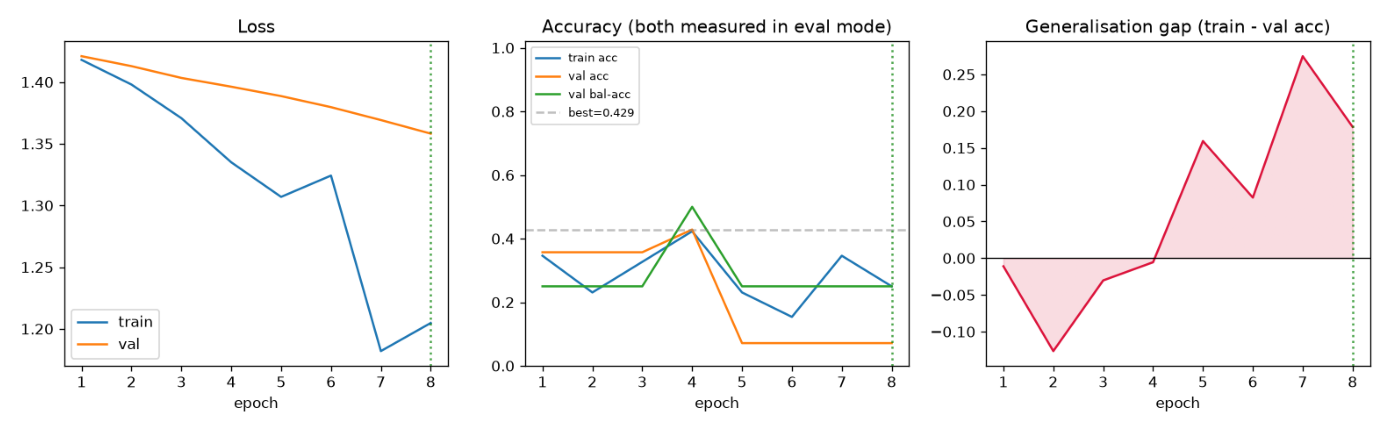


--- fig2_confusion.png ---


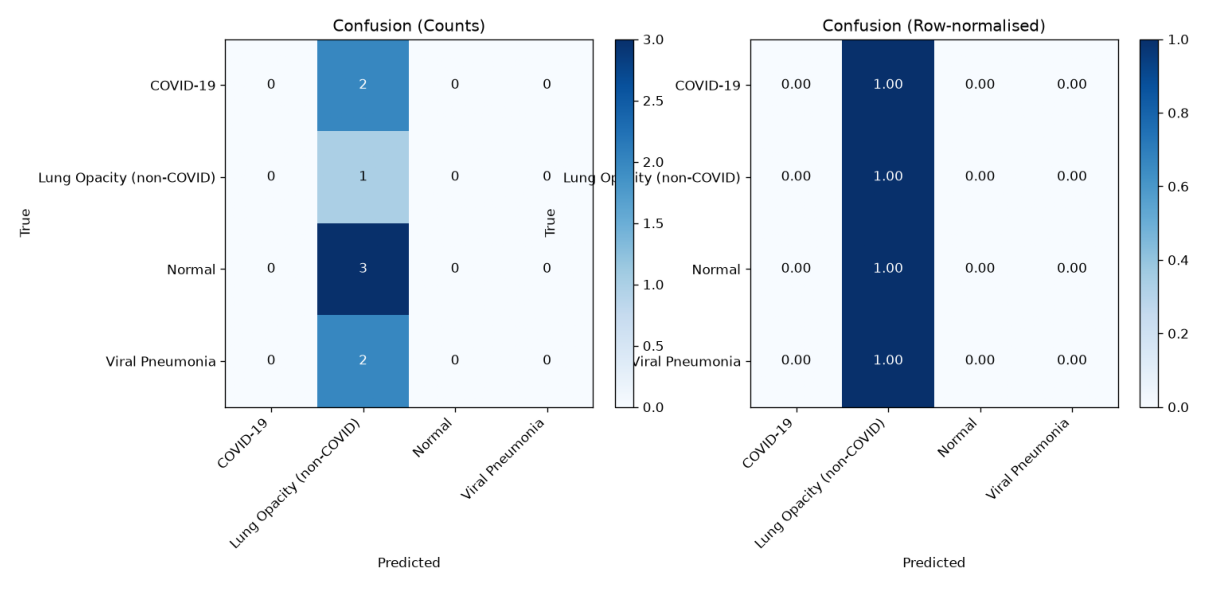


--- fig3_per_class_metrics.png ---


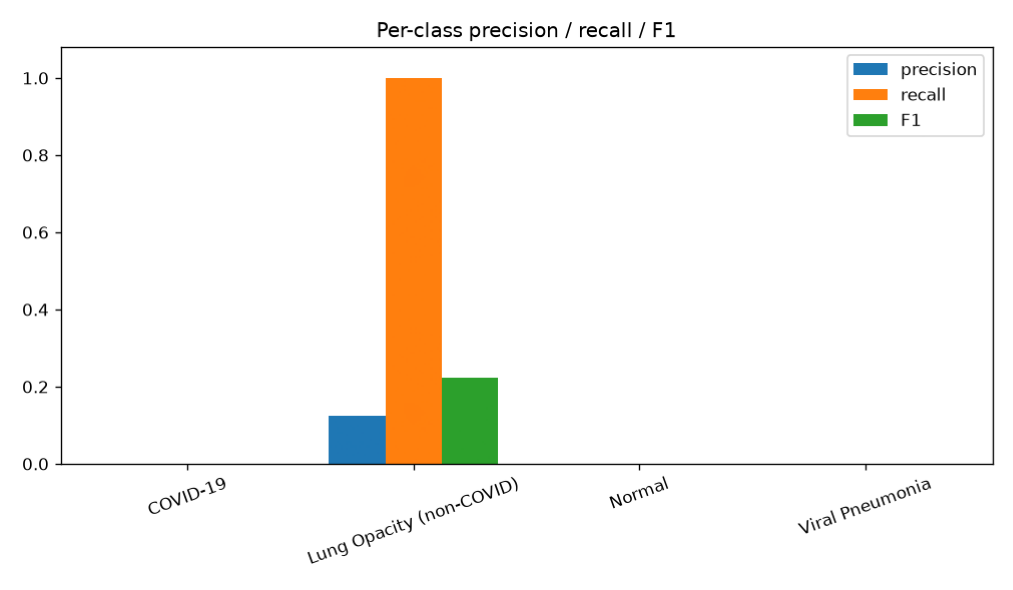


--- fig4_roc_pr.png ---


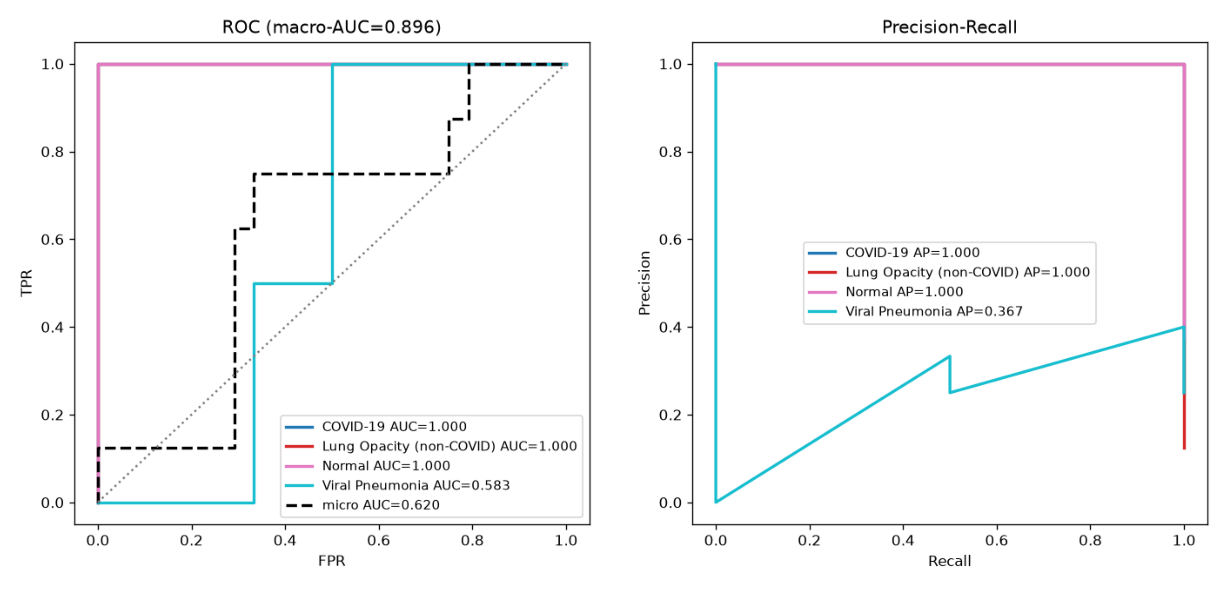


--- fig5_tsne.png ---


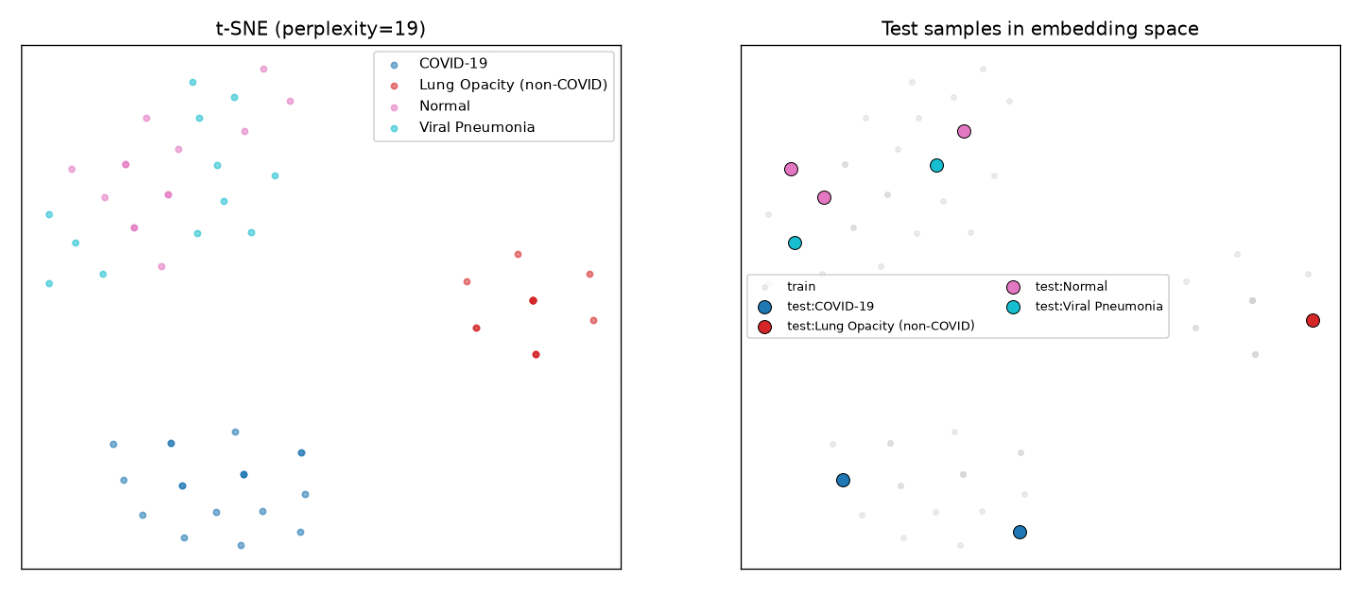


--- fig6_superpixel_graphs.png ---


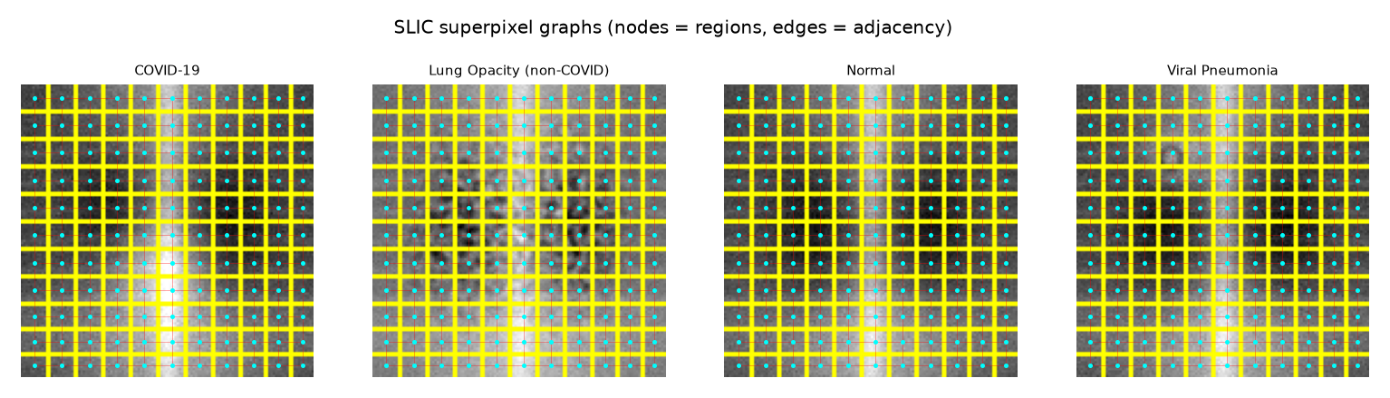


--- fig7_attention_saliency.png ---


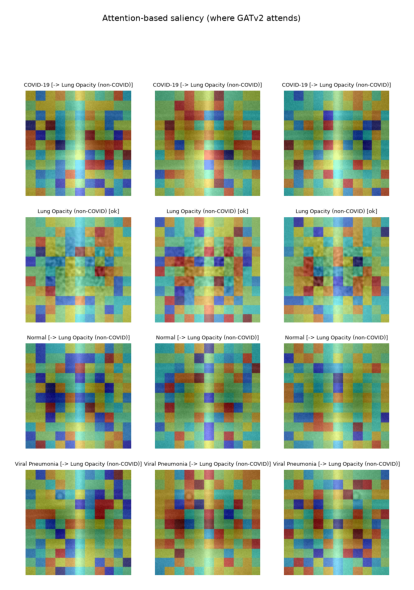

In [37]:
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from cxr_gnn.evaluation import visualization as viz

wd = cfg.work_dir
viz.plot_training_curves(history, wd)
viz.plot_confusion(te_y, te_p, TARGET_NAMES, wd)
viz.plot_per_class_metrics(te_y, te_p, TARGET_NAMES, wd)
viz.plot_roc_pr(te_y, te_pr, TARGET_NAMES, wd)
viz.plot_tsne(model, train_loader, test_loader, device, wd, TARGET_NAMES)
viz.plot_superpixel_graphs(samples, cfg, TARGET_NAMES, wd)
viz.plot_attention_saliency(model, samples, cfg, TARGET_NAMES, encoder, device, wd)

for path in sorted(glob.glob(f"{wd}/fig[1-7]*.png")):
    print(f"\n--- {os.path.basename(path)} ---")
    plt.figure(figsize=(14, 6))
    plt.imshow(mpimg.imread(path))
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## Step 8 — Stratified 5-fold cross-validation

Original images only. MCC is reported per fold alongside accuracy/F1/AUC: with
this class imbalance it is the number worth quoting.

In [38]:
from cxr_gnn.training.crossval import run_cross_validation

cv_results = run_cross_validation(orig_graphs, orig_labels, cfg, device, wd)

print("\n5-fold CV summary:")
for k in ["Accuracy", "Balanced-Acc", "Macro-F1", "Macro-AUC", "MCC"]:
    print(f"  {k:14s}: {cv_results[k]['mean']:.4f} +/- {cv_results[k]['std']:.4f}")

2026-08-12 06:53:47 [INFO] cxr_gnn.training.crossval: Fold 1: acc 0.0714 | bal-acc 0.2500 | F1 0.0333 | AUC 0.8076 | MCC 0.0000 | n(tr/va/te)=44/8/14


2026-08-12 06:53:48 [INFO] cxr_gnn.training.crossval: Fold 2: acc 0.0769 | bal-acc 0.2500 | F1 0.0357 | AUC 0.8729 | MCC 0.0000 | n(tr/va/te)=45/8/13


2026-08-12 06:53:49 [INFO] cxr_gnn.training.crossval: Fold 3: acc 0.0769 | bal-acc 0.2500 | F1 0.0385 | AUC 0.8042 | MCC -0.0376 | n(tr/va/te)=45/8/13


2026-08-12 06:53:50 [INFO] cxr_gnn.training.crossval: Fold 4: acc 0.1538 | bal-acc 0.2500 | F1 0.0667 | AUC 0.8056 | MCC 0.0000 | n(tr/va/te)=45/8/13


2026-08-12 06:53:52 [INFO] cxr_gnn.training.crossval: Fold 5: acc 0.0769 | bal-acc 0.2500 | F1 0.0357 | AUC 0.8451 | MCC 0.0000 | n(tr/va/te)=45/8/13


...

2026-08-12 06:53:52 [INFO] cxr_gnn.training.crossval:   Macro-F1      : 0.0420 +/- 0.0125


2026-08-12 06:53:52 [INFO] cxr_gnn.training.crossval:   Macro-AUC     : 0.8271 +/- 0.0275


2026-08-12 06:53:52 [INFO] cxr_gnn.training.crossval:   MCC           : -0.0075 +/- 0.0150


2026-08-12 06:53:52 [INFO] cxr_gnn.training.crossval: Saved outputs/cv_results.json



5-fold CV summary:
  Accuracy      : 0.0912 +/- 0.0314
  Balanced-Acc  : 0.2500 +/- 0.0000
  Macro-F1      : 0.0420 +/- 0.0125
  Macro-AUC     : 0.8271 +/- 0.0275
  MCC           : -0.0075 +/- 0.0150


## Step 9 — Ablation

Two families. **Feature arms** ask which node features carry the signal;
**architecture arms** remove one design choice at a time (attention, multi-head
aggregation, class balancing, the superpixel graph itself).

Each arm trains on the same folds with the same budget, so the accuracy delta is
attributable to the removed component.

2026-08-12 06:53:52 [INFO] cxr_gnn.training.ablation: Running feature ablation (5-fold) ...


2026-08-12 06:53:57 [INFO] cxr_gnn.training.ablation:   Hand-only (12d) +edge            acc 0.091+/-0.031 | F1 0.041+/-0.013 | AUC 0.553+/-0.046


2026-08-12 06:54:01 [INFO] cxr_gnn.training.ablation:   Deep-only (128d) +edge           acc 0.091+/-0.031 | F1 0.041+/-0.013 | AUC 0.854+/-0.061


2026-08-12 06:54:06 [INFO] cxr_gnn.training.ablation:   Hybrid (140d) +edge              acc 0.091+/-0.031 | F1 0.042+/-0.012 | AUC 0.827+/-0.028


2026-08-12 06:54:12 [INFO] cxr_gnn.training.ablation:   Hybrid (140d) no-edge            acc 0.091+/-0.031 | F1 0.041+/-0.013 | AUC 0.802+/-0.020


...

2026-08-12 06:54:39 [WARNING] cxr_gnn.models.cnn_baseline: Pretrained weights unavailable (<urlopen error Tunnel connection failed: 403 Forbidden>). Using random init.


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


2026-08-12 06:54:41 [WARNING] cxr_gnn.models.cnn_baseline: Pretrained weights unavailable (<urlopen error Tunnel connection failed: 403 Forbidden>). Using random init.


2026-08-12 06:54:44 [INFO] cxr_gnn.training.ablation:   - Superpixel graph (CNN only)      acc 0.363 | F1 0.226


2026-08-12 06:54:44 [INFO] cxr_gnn.training.ablation: Saved ablation_architecture.json


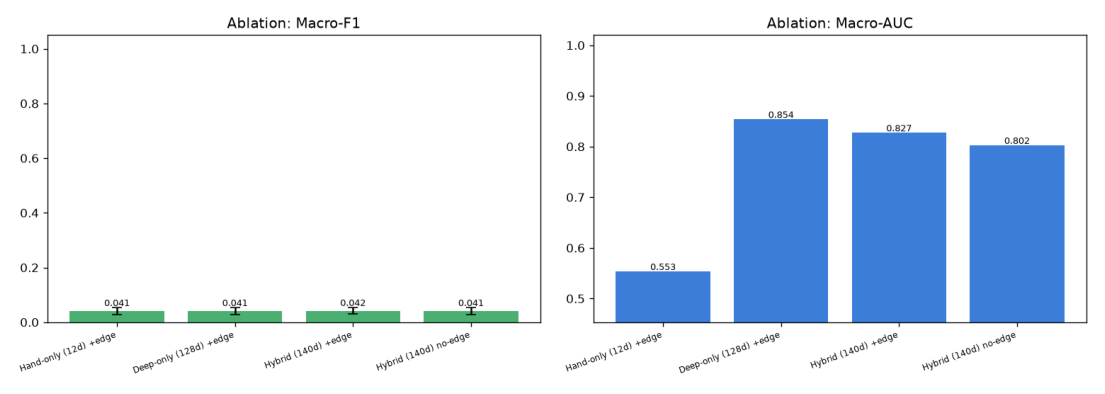

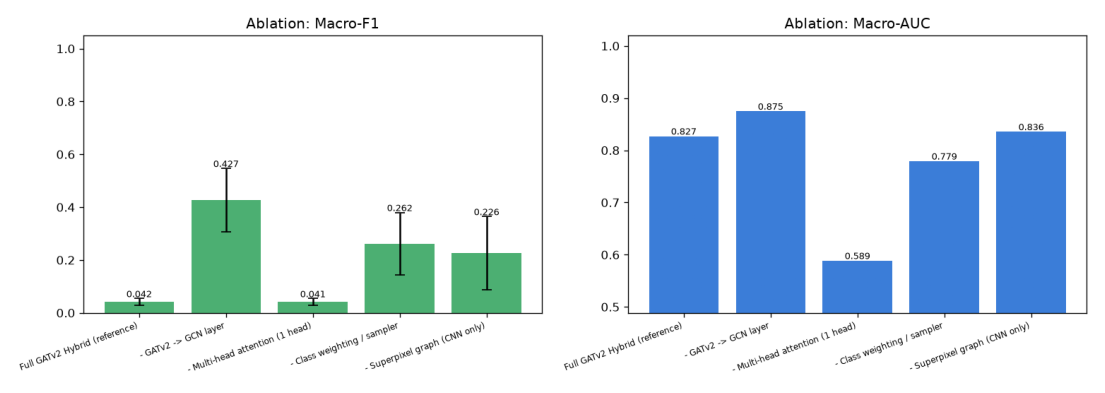

In [39]:
from cxr_gnn.training.ablation import run_feature_ablation, run_architecture_ablation

abl_feat = run_feature_ablation(orig_graphs, orig_labels, cfg, device, wd)
abl_arch = run_architecture_ablation(orig_graphs, orig_labels, cfg, device, wd,
                                     path_items=orig_items)

viz.plot_ablation(abl_feat, wd, "fig8_ablation_features.png")
viz.plot_ablation(abl_arch, wd, "fig8b_ablation_architecture.png")

for path in [f"{wd}/fig8_ablation_features.png", f"{wd}/fig8b_ablation_architecture.png"]:
    plt.figure(figsize=(14, 5))
    plt.imshow(mpimg.imread(path))
    plt.axis("off")
    plt.show()

## Step 10 — Baselines and the statistical suite

GCN, GraphSAGE, GAT and an **end-to-end fine-tuned ResNet18** on raw pixels.
The fold indices are computed once and shared by all five models, which is what
makes the paired McNemar and DeLong tests valid.

Computed here: MCC, Cohen's kappa, Youden's J, Brier, ECE, log loss (each with
bootstrap CIs), per-class Sens/Spec/PPV/NPV with Wilson CIs, **all** pairwise
DeLong and McNemar comparisons under Holm and BH correction, and the cost
columns (trainable parameters, training time, inference latency) measured rather
than asserted.

2026-08-12 06:54:47 [INFO] cxr_gnn.training.crossval:   GCN                   : acc 0.425 | F1 0.427 | AUC 0.875 | 41948 params | 0.4 s/fold | 2.1 ms/graph


2026-08-12 06:54:49 [INFO] cxr_gnn.training.crossval:   GraphSAGE             : acc 0.410 | F1 0.370 | AUC 0.875 | 78044 params | 0.4 s/fold | 1.6 ms/graph


2026-08-12 06:54:53 [INFO] cxr_gnn.training.crossval:   GAT                   : acc 0.120 | F1 0.066 | AUC 0.769 | 43148 params | 0.7 s/fold | 3.0 ms/graph


2026-08-12 06:54:58 [INFO] cxr_gnn.training.crossval:   GATv2 Hybrid (ours)   : acc 0.091 | F1 0.042 | AUC 0.827 | 79244 params | 0.9 s/fold | 3.2 ms/graph


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


...

2026-08-12 06:55:20 [INFO] cxr_gnn.training.crossval:   GAT                    vs ResNet18 (CNN baseline) Macro-AUC  p=0.00561 holm-p=0.05 n.s.


2026-08-12 06:55:20 [INFO] cxr_gnn.training.crossval:   GAT                    vs ResNet18 (CNN baseline) Accuracy   p=0.00154 holm-p=0.017 SIGNIFICANT


2026-08-12 06:55:20 [INFO] cxr_gnn.training.crossval:   GATv2 Hybrid (ours)    vs ResNet18 (CNN baseline) Macro-AUC  p=0.00201 holm-p=0.0201 SIGNIFICANT


2026-08-12 06:55:20 [INFO] cxr_gnn.training.crossval:   GATv2 Hybrid (ours)    vs ResNet18 (CNN baseline) Accuracy   p=0.000121 holm-p=0.00182 SIGNIFICANT


2026-08-12 06:55:20 [INFO] cxr_gnn.training.crossval: Saved baseline_results.json and statistical_robustness.json


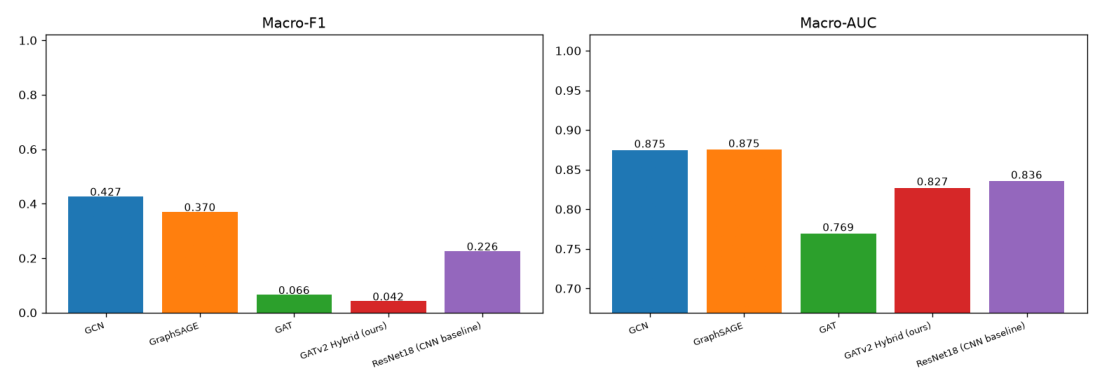


Pairwise comparisons (Holm-corrected), primary = GATv2 Hybrid (ours):
  GCN                    vs GraphSAGE              Macro-AUC  p=0.102 holm=0.612  n.s.
  GCN                    vs GraphSAGE              Accuracy   p=1 holm=1  n.s.
  GCN                    vs GAT                    Macro-AUC  p=0.000438 holm=0.00569  SIGNIFICANT
  GCN                    vs GAT                    Accuracy   p=1.91e-06 holm=3.24e-05  SIGNIFICANT
  GCN                    vs GATv2 Hybrid (ours)    Macro-AUC  p=0.286 holm=1  n.s.
  GCN                    vs GATv2 Hybrid (ours)    Accuracy   p=4.77e-07 holm=9.54e-06  SIGNIFICANT
  GCN                    vs ResNet18 (CNN baseline) Macro-AUC  p=0.00556 holm=0.05  n.s.
  GCN                    vs ResNet18 (CNN baseline) Accuracy   p=0.652 holm=1  n.s.
  GraphSAGE              vs GAT                    Macro-AUC  p=0.000215 holm=0.00302  SIGNIFICANT
  GraphSAGE              vs GAT                    Accuracy   p=3.81e-06 holm=6.1e-05  SIGNIFICANT
  GraphSAG

In [40]:
from cxr_gnn.training.crossval import run_model_comparison

bl_results = run_model_comparison(orig_graphs, orig_labels, cfg, device, wd,
                                  path_items=orig_items,
                                  include_cnn_baseline=cfg.include_cnn_baseline)
viz.plot_model_comparison(bl_results, wd)

plt.figure(figsize=(14, 5))
plt.imshow(mpimg.imread(f"{wd}/fig9_model_comparison.png"))
plt.axis("off")
plt.show()

with open(f"{wd}/statistical_robustness.json") as f:
    stat_summary = json.load(f)

print(f"\nPairwise comparisons (Holm-corrected), primary = {stat_summary['primary_model']}:")
for r in stat_summary["pairwise_delong_mcnemar"]:
    verdict = "SIGNIFICANT" if r["significant_holm_alpha_0.05"] else "n.s."
    print(f"  {r['model_a']:22s} vs {r['model_b']:22s} {r['metric']:10s} "
          f"p={r['p_value']:.3g} holm={r['holm_corrected_p']:.3g}  {verdict}")

## Step 11 — Split-ratio sensitivity, and error analysis

Five split ratios × several seeds, reusing the pre-built graph pool: only the
index partition changes, so nothing is re-processed through SLIC. This is what
shows the headline number is not an artefact of one lucky split.

The seed varies **model initialisation as well as the partition** — varying only
the partition leaves every "seed" sharing one initialisation.

The pooled predictions from the best config then feed the per-class table, the
confusion matrix and the error taxonomy, so all three agree by construction.

In [41]:
from cxr_gnn.training.split_sensitivity import run_split_sensitivity
from cxr_gnn.evaluation.error_analysis import run_error_analysis

sens = run_split_sensitivity(all_graphs, all_labels, cfg, device, wd,
                             seeds=cfg.sensitivity_seeds,
                             epochs=cfg.sensitivity_epochs,
                             patience=cfg.sensitivity_patience,
                             n_boot=cfg.n_bootstrap)

print(f"\nBest split configuration: {sens['best_split_config']}")
for cid, ci in sens["bootstrap_ci_by_split"].items():
    print(f"  {cid}: Acc {ci['accuracy_ci']} | Macro-F1 {ci['macro_f1_ci']} | MCC {ci['mcc_ci']}")

pooled = sens["pooled_predictions_best_split"]
err = run_error_analysis(np.array(pooled["y"]), np.array(pooled["pred"]),
                         np.array(pooled["confidence"]), wd)
viz.plot_confusion(np.array(pooled["y"]), np.array(pooled["pred"]), TARGET_NAMES, wd,
                   fname="fig2b_confusion_best_split.png")

2026-08-12 06:55:21 [INFO] cxr_gnn.training.split_sensitivity: Split-ratio sensitivity: 5 configs x 2 seeds = 10 training runs ...


2026-08-12 06:55:22 [INFO] cxr_gnn.training.split_sensitivity:   [S1 seed=42] acc=0.1250 bal-acc=0.2500 macroF1=0.0556 macroAUC=0.7750 mcc=0.0000 n(tr/va/te)=58/8/8


2026-08-12 06:55:23 [INFO] cxr_gnn.training.split_sensitivity:   [S1 seed=43] acc=0.1250 bal-acc=0.2500 macroF1=0.0556 macroAUC=0.8750 mcc=0.0000 n(tr/va/te)=58/8/8


2026-08-12 06:55:23 [INFO] cxr_gnn.training.split_sensitivity:   [S2 seed=42] acc=0.0909 bal-acc=0.2500 macroF1=0.0417 macroAUC=0.7768 mcc=0.0000 n(tr/va/te)=52/11/11


2026-08-12 06:55:24 [INFO] cxr_gnn.training.split_sensitivity:   [S2 seed=43] acc=0.0909 bal-acc=0.2500 macroF1=0.0417 macroAUC=0.8958 mcc=0.0000 n(tr/va/te)=52/11/11


...

2026-08-12 06:55:45 [INFO] cxr_gnn.evaluation.error_analysis:   COVID-19 -> Lung Opacity (non-COVID)       n=  4 (18.2% of errors) mean-conf 0.306


2026-08-12 06:55:45 [INFO] cxr_gnn.evaluation.error_analysis:   Normal -> Viral Pneumonia                  n=  2 (9.1% of errors) mean-conf 0.284


2026-08-12 06:55:45 [INFO] cxr_gnn.evaluation.error_analysis:   Abstaining below confidence 0.55 would defer 100.0% of errors (and 100.0% of correct predictions).


2026-08-12 06:55:45 [INFO] cxr_gnn.evaluation.error_analysis: Saved outputs/error_analysis.json


'outputs/fig2b_confusion_best_split.png'

## Step 12 — Conformal prediction

Prediction *sets* with a coverage guarantee. A non-singleton set is the model
saying it cannot separate those classes for this image — exactly the
"indeterminate result" a reporting checklist asks about.

In [42]:
from cxr_gnn.evaluation.conformal import run_conformal
from cxr_gnn.training.crossval import _train_one_fold

def train_fold_fn(tr_g, va_g):
    m, _ = _train_one_fold(tr_g, va_g, nfd, efd, cfg, device,
                           epochs=cfg.cv_epochs, patience=cfg.cv_patience)
    return m

conf_results = run_conformal(orig_graphs, orig_labels, train_fold_fn, cfg, device, wd)

print("\nConformal summary (5-fold average):")
for m in ["lac", "aps", "raps", "cclac"]:
    print(f"  {m.upper():6s}: coverage={np.mean(conf_results[m]['cov']):.3f} "
          f"| avg set size={np.mean(conf_results[m]['size']):.2f} "
          f"| singletons={np.mean(conf_results[m]['sing']):.1%}")

2026-08-12 06:55:46 [INFO] cxr_gnn.evaluation.conformal: Conformal prediction (target coverage 90%) ...


2026-08-12 06:55:47 [WARNING] cxr_gnn.training.crossval: [conformal cal/test] Cannot stratify a split of 14 items (smallest class has 1 member(s)); falling back to an unstratified split.


2026-08-12 06:55:47 [INFO] cxr_gnn.evaluation.conformal: Fold 1: LAC 1.00/3.43 | APS 1.00/4.00 | RAPS 1.00/4.00 | CCLAC 0.57/1.57  (cov/size)


2026-08-12 06:55:48 [WARNING] cxr_gnn.training.crossval: [conformal cal/test] Cannot stratify a split of 13 items (smallest class has 1 member(s)); falling back to an unstratified split.


2026-08-12 06:55:48 [INFO] cxr_gnn.evaluation.conformal: Fold 2: LAC 1.00/3.43 | APS 1.00/4.00 | RAPS 1.00/4.00 | CCLAC 0.57/1.86  (cov/size)


...

2026-08-12 06:55:50 [INFO] cxr_gnn.evaluation.conformal:   RAPS  : cov 1.000+/-0.000 | size 4.00 | singletons 0.0%


2026-08-12 06:55:50 [INFO] cxr_gnn.evaluation.conformal:   CCLAC : cov 0.600+/-0.140 | size 1.57 | singletons 54.3%


2026-08-12 06:55:50 [INFO] cxr_gnn.evaluation.conformal: -> Recommended: RAPS (best size/coverage trade-off)


2026-08-12 06:55:50 [INFO] cxr_gnn.evaluation.conformal: Saved outputs/conformal_results.json



Conformal summary (5-fold average):
  LAC   : coverage=1.000 | avg set size=3.49 | singletons=0.0%
  APS   : coverage=1.000 | avg set size=4.00 | singletons=0.0%
  RAPS  : coverage=1.000 | avg set size=4.00 | singletons=0.0%
  CCLAC : coverage=0.600 | avg set size=1.57 | singletons=54.3%


## Step 13 — Calibration

ECE below 0.05 reads as well calibrated; above 0.10 the probabilities should not
be quoted without correction. When that happens, a temperature is fitted on one
half of the pooled out-of-fold predictions and evaluated on the other, so the
post-scaling number is not fitted on the data it is reported on.

2026-08-12 06:55:54 [INFO] cxr_gnn.evaluation.calibration: ECE: 0.2311 | MCE: 0.2900 | OOF acc: 0.0909


2026-08-12 06:55:54 [WARNING] cxr_gnn.evaluation.calibration: ECE=0.231 > 0.10 -- fitting temperature scaling.


2026-08-12 06:55:55 [INFO] cxr_gnn.evaluation.calibration: Temperature scaling: T=152386.208, ECE 0.2128 -> 0.1591 on the held-out half


2026-08-12 06:55:55 [INFO] cxr_gnn.evaluation.calibration: Saved outputs/calibration.json


ECE 0.2311 | MCE 0.2900 | OOF acc 0.0909 | mean confidence 0.2992
Temperature scaling: T=152386.208, ECE 0.2128 -> 0.1591 (held-out half)


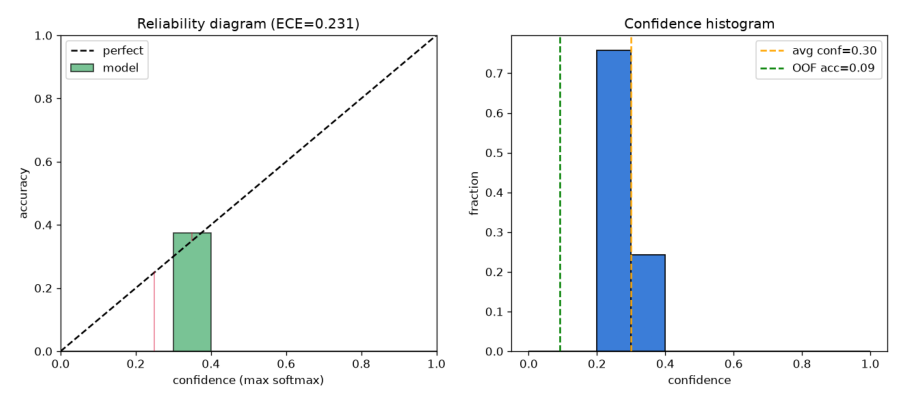

In [43]:
from cxr_gnn.evaluation.calibration import compute_calibration

cal = compute_calibration(orig_graphs, orig_labels, train_fold_fn, cfg, device, wd)
viz.plot_calibration(cal, wd)

print(f"ECE {cal['ECE']:.4f} | MCE {cal['MCE']:.4f} | "
      f"OOF acc {cal['oof_accuracy']:.4f} | mean confidence {cal['avg_confidence']:.4f}")
if cal["temperature_scaling"]:
    ts = cal["temperature_scaling"]
    print(f"Temperature scaling: T={ts['temperature']:.3f}, "
          f"ECE {ts['ece_before_on_eval_half']:.4f} -> {ts['ece_after']:.4f} (held-out half)")

plt.figure(figsize=(13, 5))
plt.imshow(mpimg.imread(f"{wd}/fig10_calibration.png"))
plt.axis("off")
plt.show()

## Step 14 — Robustness under input perturbation

Each perturbation is applied to the test images and the graphs are rebuilt
through the identical SLIC + encoder path, so what is measured is the whole
pipeline's sensitivity, not just the classifier's.

2026-08-12 06:55:55 [INFO] cxr_gnn.evaluation.robustness: Robustness study: clean reference + 6 perturbations ...


2026-08-12 06:55:57 [INFO] cxr_gnn.evaluation.robustness:   None (clean test set)          acc 0.1250 (reference)


2026-08-12 06:56:00 [INFO] cxr_gnn.evaluation.robustness:   Gaussian noise (sigma=0.02)    acc 0.1250 (delta +0.0000, retention 100.0%, grade A)


2026-08-12 06:56:03 [INFO] cxr_gnn.evaluation.robustness:   Gaussian noise (sigma=0.05)    acc 0.1250 (delta +0.0000, retention 100.0%, grade A)


2026-08-12 06:56:06 [INFO] cxr_gnn.evaluation.robustness:   JPEG compression (q=50)        acc 0.1250 (delta +0.0000, retention 100.0%, grade A)


2026-08-12 06:56:08 [INFO] cxr_gnn.evaluation.robustness:   Rotation (+/-10 deg)           acc 0.1250 (delta +0.0000, retention 100.0%, grade A)


2026-08-12 06:56:11 [INFO] cxr_gnn.evaluation.robustness:   Brightness shift (+/-20%)      acc 0.3750 (delta +0.2500, retention 300.0%, grade A)


2026-08-12 06:56:13 [INFO] cxr_gnn.evaluation.robustness:   Contrast reduction (-30%)      acc 0.1250 (delta +0.0000, retention 100.0%, grade A)


2026-08-12 06:56:13 [INFO] cxr_gnn.evaluation.robustness: Saved outputs/robustness.json


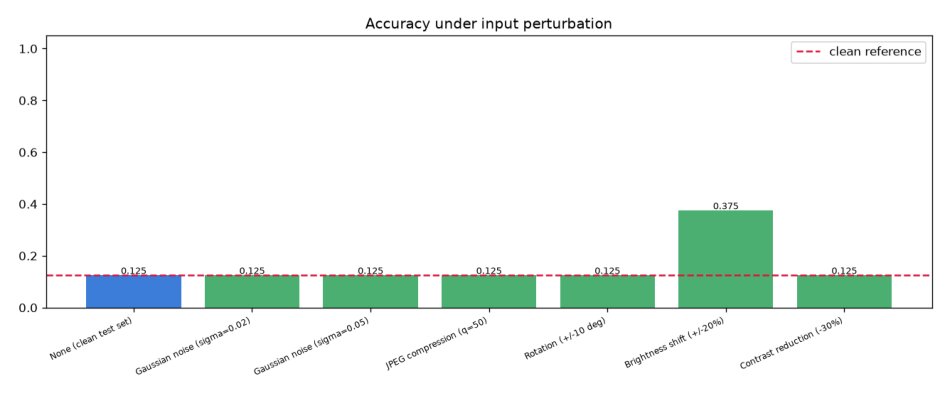

In [44]:
from cxr_gnn.evaluation.robustness import run_robustness_study

rob = run_robustness_study(model, kept_items["test"], cfg, encoder, device, wd)
viz.plot_robustness(rob, wd)

plt.figure(figsize=(12, 5))
plt.imshow(mpimg.imread(f"{wd}/fig11_robustness.png"))
plt.axis("off")
plt.show()

## Step 15 — Evaluation tables

Every table is rebuilt from the JSON artifacts written above, so no number in
the write-up is transcribed by hand. A table whose artifact is missing prints
"not available — run step X" rather than a plausible-looking placeholder.

In [45]:
from IPython.display import Markdown, display
from cxr_gnn.evaluation.tables import build_all_tables

display(Markdown(build_all_tables(wd)))

2026-08-12 06:56:14 [INFO] cxr_gnn.evaluation.tables: Saved outputs/evaluation_tables.md


**Dataset and run provenance.**

| Field | Value |
|---|---|
| Dataset | COVID-19 Radiography Database (4-class) |
| Source | https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database |
| Citation | Chowdhury et al., 'Can AI help in screening viral and COVID-19 pneumonia?', IEEE Access 8:132665-132676, 2020; Rahman et al., 'Exploring the effect of image enhancement techniques on COVID-19 detection using chest X-ray images', Computers in Biology and Medicine 132:104319, 2021. |
| Licence | Free for academic use with citation (see the dataset's README). |
| Classes | 4 -- COVID, LungOpacity, Normal, ViralPneumonia |
| Images used | 74 (per-class cap: 1200) |
| Split | image-level stratified, before augmentation |
| Device | cpu |
| Code version | not recorded |

> **Not reportable: synthetic phantom images and reduced training/bootstrap budgets.** These numbers show that the pipeline executes; they are not findings.

---

**Table 1. Split configurations, aggregate performance (mean +/- SD over 2 seeds) and bootstrapped 95% CIs.**

| Config | Ratio (Tr/Va/Te) | n (Tr/Va/Te) | Accuracy | Bal. Acc. | Macro F1 | Macro AUC | Accuracy 95% CI | Macro F1 95% CI | Macro AUC 95% CI | MCC 95% CI |
|---|---|---|---|---|---|---|---|---|---|---|
| S1 | 80%/10%/10% | 58 / 8 / 8 | 0.1250 +/- 0.0000 | 0.2500 +/- 0.0000 | 0.0556 +/- 0.0000 | 0.8250 +/- 0.0500 | 0.125 (0.000-0.312) | 0.056 (0.000-0.119) | 0.766 (0.555-0.892) | 0.000 (0.000-0.000) |
| S2 | 70%/15%/15% | 52 / 11 / 11 | 0.0909 +/- 0.0000 | 0.2500 +/- 0.0000 | 0.0417 +/- 0.0000 | 0.8363 +/- 0.0595 | 0.091 (0.000-0.227) | 0.042 (0.000-0.093) | 0.765 (0.565-0.873) | 0.000 (0.000-0.000) |
| S3 | 75%/15%/10% | 55 / 11 / 8 | 0.1250 +/- 0.0000 | 0.2500 +/- 0.0000 | 0.0556 +/- 0.0000 | 0.8250 +/- 0.0500 | 0.125 (0.000-0.312) | 0.056 (0.000-0.119) | 0.750 (0.526-0.884) | 0.000 (0.000-0.000) |
| S4 | 70%/20%/10% | 52 / 14 / 8 | 0.1250 +/- 0.0000 | 0.2500 +/- 0.0000 | 0.0556 +/- 0.0000 | 0.8167 +/- 0.0583 | 0.125 (0.000-0.312) | 0.056 (0.000-0.119) | 0.756 (0.564-0.869) | 0.000 (0.000-0.000) |
| S5 | 60%/20%/20% | 46 / 14 / 14 | 0.2143 +/- 0.1429 | 0.3750 +/- 0.1250 | 0.1670 +/- 0.1285 | 0.8576 +/- 0.0438 | 0.214 (0.071-0.393) | 0.208 (0.071-0.311) | 0.772 (0.632-0.863) | 0.193 (0.027-0.350) |
| **Mean** | - | 74 total | 0.1360 +/- 0.0413 | 0.2750 +/- 0.0500 | 0.0751 +/- 0.0463 | 0.8321 +/- 0.0142 | - | - | - | - |

All splits are stratified by class and performed on raw images before augmentation (no image-level leakage). Seeds 42-43. Best configuration by mean accuracy: **S5**; bootstrap B = 300.

---

**Table 2. Stratified 5-fold cross-validation.**

| Fold | Train n | Val n | Test n | Accuracy | Balanced Acc. | Macro F1 | Macro AUC | MCC |
|---|---|---|---|---|---|---|---|---|
| 1 | 44 | 8 | 14 | 0.0714 | 0.2500 | 0.0333 | 0.8076 | 0.0000 |
| 2 | 45 | 8 | 13 | 0.0769 | 0.2500 | 0.0357 | 0.8729 | 0.0000 |
| 3 | 45 | 8 | 13 | 0.0769 | 0.2500 | 0.0385 | 0.8042 | -0.0376 |
| 4 | 45 | 8 | 13 | 0.1538 | 0.2500 | 0.0667 | 0.8056 | 0.0000 |
| 5 | 45 | 8 | 13 | 0.0769 | 0.2500 | 0.0357 | 0.8451 | 0.0000 |
| **Mean +/- SD** | - | - | - | 0.0912 +/- 0.0314 | 0.2500 +/- 0.0000 | 0.0420 +/- 0.0125 | 0.8271 +/- 0.0275 | -0.0075 +/- 0.0150 |

Folds are stratified on the original (non-augmented) images only; augmented graphs never enter a held-out fold.

---

**Table 3. Per-class performance, best split configuration (S5), pooled over 2 seeds. Wilson score 95% CIs.**

| Class | Support | Prevalence | Sensitivity (95% CI) | Specificity (95% CI) | PPV (95% CI) | NPV (95% CI) | F1 | AUC | LR+ | LR- |
|---|---|---|---|---|---|---|---|---|---|---|
| COVID-19 | 8 | 28.6% | 0.500 (0.215-0.785) | 1.000 (0.839-1.000) | 1.000 (0.510-1.000) | 0.833 (0.641-0.933) | 0.667 | 0.750 | inf | 0.50 |
| Lung Opacity (non-COVID) | 2 | 7.1% | 1.000 (0.342-1.000) | 0.231 (0.110-0.421) | 0.091 (0.025-0.278) | 1.000 (0.610-1.000) | 0.167 | 1.000 | 1.30 | 0.00 |
| Normal | 10 | 35.7% | 0.000 (0.000-0.278) | 1.000 (0.824-1.000) | n/a (n/a-n/a) | 0.643 (0.458-0.793) | 0.000 | 0.789 | inf | 1.00 |
| Viral Pneumonia | 8 | 28.6% | 0.000 (0.000-0.324) | 0.900 (0.699-0.972) | 0.000 (0.000-0.658) | 0.692 (0.500-0.835) | 0.000 | 0.550 | 0.00 | 1.11 |
| **Macro average** | 28 | 100% | 0.375 | 0.783 | 0.364 | 0.792 | 0.208 | 0.772 | 0.65 | 0.65 |

Wilson score intervals are used for every proportion: more reliable than the normal approximation at the sample sizes of the minority classes. Sensitivity here is the same quantity as per-class recall in Table 4 and is computed from the same pooled predictions, so the two tables agree by construction.

---

**Table 4. Confusion matrix, best split configuration (S5), pooled over seeds (rows = true, columns = predicted).**

| True \ Predicted | COVID-19 | Lung Opacity (non-COVID) | Normal | Viral Pneumonia | Total | Recall |
|---|---|---|---|---|---|---|
| COVID-19 | 4 | 4 | 0 | 0 | 8 | 0.500 |
| Lung Opacity (non-COVID) | 0 | 2 | 0 | 0 | 2 | 1.000 |
| Normal | 0 | 8 | 0 | 2 | 10 | 0.000 |
| Viral Pneumonia | 0 | 8 | 0 | 0 | 8 | 0.000 |
| **Total predicted** | 4 | 22 | 0 | 2 | 28 | - |
| **Precision** | 1.000 | 0.091 | n/a | 0.000 | - | 0.214 (accuracy) |

---

**Table 5. Statistical significance, all pairwise comparisons.**

| Family | Comparison | Metric | Test | Statistic | p-value | Holm-corrected p | Delta (A-B) | Effect size | Significant (alpha=.05) |
|---|---|---|---|---|---|---|---|---|---|
| Split-ratio | S1 vs S2 | accuracy | Paired t-test | t = inf | 0 | 0 | +0.0341 | d = 0.00 (negligible) | Yes |
| Split-ratio | S1 vs S2 | macro_f1 | Paired t-test | t = inf | 0 | 0 | +0.0139 | d = 0.00 (negligible) | Yes |
| Split-ratio | S1 vs S3 | accuracy | Paired t-test | t = 0.00 | 1 | 1 | +0.0000 | d = 0.00 (negligible) | No |
| Split-ratio | S1 vs S4 | accuracy | Paired t-test | t = 0.00 | 1 | 1 | +0.0000 | d = 0.00 (negligible) | No |
| Split-ratio | S1 vs S5 | accuracy | Paired t-test | t = -0.62 | 0.644 | 1 | -0.0893 | d = -0.44 (small) | No |
| Split-ratio | S2 vs S4 | accuracy | Paired t-test | t = -inf | 0 | 0 | -0.0341 | d = 0.00 (negligible) | Yes |
| Model-vs-model | GCN vs GraphSAGE | Macro-AUC | DeLong (one-vs-rest, Fisher-combined) | z = -2.02 | 0.102 | 0.612 | -0.0468 | - | No |
| Model-vs-model | GCN vs GraphSAGE | Accuracy | McNemar (exact) | chi2 = 0.00 | 1 | 1 | +0.0152 | - | No |
| Model-vs-model | GCN vs GAT | Macro-AUC | DeLong (one-vs-rest, Fisher-combined) | z = 1.52 | 0.000438 | 0.00569 | +0.0693 | - | Yes (GCN better) |
| Model-vs-model | GCN vs GAT | Accuracy | McNemar (exact) | chi2 = 18.05 | 1.91e-06 | 3.24e-05 | +0.3030 | - | Yes (GCN better) |
| Model-vs-model | GCN vs GATv2 Hybrid (ours) | Macro-AUC | DeLong (one-vs-rest, Fisher-combined) | z = -0.98 | 0.286 | 1 | -0.0226 | - | No |
| Model-vs-model | GCN vs GATv2 Hybrid (ours) | Accuracy | McNemar (exact) | chi2 = 20.05 | 4.77e-07 | 9.54e-06 | +0.3333 | - | Yes (GCN better) |
| Model-vs-model | GCN vs ResNet18 (CNN baseline) | Macro-AUC | DeLong (one-vs-rest, Fisher-combined) | z = 1.76 | 0.00556 | 0.05 | +0.0260 | - | No |
| Model-vs-model | GCN vs ResNet18 (CNN baseline) | Accuracy | McNemar (exact) | chi2 = 0.20 | 0.652 | 1 | +0.0606 | - | No |
| Model-vs-model | GraphSAGE vs GAT | Macro-AUC | DeLong (one-vs-rest, Fisher-combined) | z = 3.17 | 0.000215 | 0.00302 | +0.1160 | - | Yes (GraphSAGE better) |
| Model-vs-model | GraphSAGE vs GAT | Accuracy | McNemar (exact) | chi2 = 17.05 | 3.81e-06 | 6.1e-05 | +0.2879 | - | Yes (GraphSAGE better) |
| Model-vs-model | GraphSAGE vs GATv2 Hybrid (ours) | Macro-AUC | DeLong (one-vs-rest, Fisher-combined) | z = 0.56 | 0.00981 | 0.0687 | +0.0241 | - | No |
| Model-vs-model | GraphSAGE vs GATv2 Hybrid (ours) | Accuracy | McNemar (exact) | chi2 = 19.05 | 9.54e-07 | 1.81e-05 | +0.3182 | - | Yes (GraphSAGE better) |
| Model-vs-model | GraphSAGE vs ResNet18 (CNN baseline) | Macro-AUC | DeLong (one-vs-rest, Fisher-combined) | z = 3.00 | 0.00098 | 0.0118 | +0.0727 | - | Yes (GraphSAGE better) |
| Model-vs-model | GraphSAGE vs ResNet18 (CNN baseline) | Accuracy | McNemar (exact) | chi2 = 0.09 | 0.761 | 1 | +0.0455 | - | No |
| Model-vs-model | GAT vs GATv2 Hybrid (ours) | Macro-AUC | DeLong (one-vs-rest, Fisher-combined) | z = -1.83 | 1.38e-06 | 2.48e-05 | -0.0919 | - | Yes (GATv2 Hybrid (ours) better) |
| Model-vs-model | GAT vs GATv2 Hybrid (ours) | Accuracy | McNemar (exact) | chi2 = 0.50 | 0.5 | 1 | +0.0303 | - | No |
| Model-vs-model | GAT vs ResNet18 (CNN baseline) | Macro-AUC | DeLong (one-vs-rest, Fisher-combined) | z = 0.17 | 0.00561 | 0.05 | -0.0433 | - | No |
| Model-vs-model | GAT vs ResNet18 (CNN baseline) | Accuracy | McNemar (exact) | chi2 = 9.38 | 0.00154 | 0.017 | -0.2424 | - | Yes (ResNet18 (CNN baseline) better) |
| Model-vs-model | GATv2 Hybrid (ours) vs ResNet18 (CNN baseline) | Macro-AUC | DeLong (one-vs-rest, Fisher-combined) | z = 1.91 | 0.00201 | 0.0201 | +0.0486 | - | Yes (GATv2 Hybrid (ours) better) |
| Model-vs-model | GATv2 Hybrid (ours) vs ResNet18 (CNN baseline) | Accuracy | McNemar (exact) | chi2 = 13.14 | 0.000121 | 0.00182 | -0.2727 | - | Yes (ResNet18 (CNN baseline) better) |

Holm-Bonferroni correction is applied within each family. The DeLong row reports the Stouffer-combined z across one-vs-rest classes (signed, so the direction is readable) while the p-value is Fisher-combined; McNemar is the exact paired test on the same held-out instances.

---

**Table 6. Model comparison: discrimination, agreement, calibration and cost.**

| Model | Acc. | Macro F1 | Macro AUC | Bal. Acc. | MCC (95% CI) | Cohen's kappa (95% CI) | Youden J | Brier | ECE | Log loss | Trainable params | Train (min/fold) | Infer. (ms) |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| GCN | 0.424 | 0.441 | 0.788 | 0.542 | 0.312 (0.171-0.432) | 0.214 (0.099-0.331) | 0.341 | 0.719 | 0.100 | 1.339 | 41,948 | 0.01 | 2.1 |
| GraphSAGE | 0.409 | 0.346 | 0.835 | 0.542 | 0.291 (0.177-0.405) | 0.245 (0.139-0.362) | 0.353 | 0.736 | 0.311 | 1.381 | 78,044 | 0.01 | 1.6 |
| GAT | 0.121 | 0.085 | 0.719 | 0.278 | 0.021 (-0.057-0.122) | 0.009 (-0.025-0.053) | 0.030 | 0.760 | 0.182 | 1.407 | 43,148 | 0.01 | 3.0 |
| GATv2 Hybrid (ours) | 0.091 | 0.042 | 0.811 | 0.250 | -0.019 (-0.047-0.000) | -0.003 (-0.011-0.000) | -0.001 | 0.761 | 0.231 | 1.415 | 79,244 | 0.02 | 3.2 |
| ResNet18 (CNN baseline) | 0.364 | 0.229 | 0.762 | 0.375 | 0.124 (-0.040-0.263) | 0.089 (-0.026-0.202) | 0.145 | 0.744 | 0.150 | 1.372 | 11,178,564 | 0.04 | 11.5 |

MCC and Cohen's kappa stay meaningful under class imbalance, unlike raw accuracy. Brier score, ECE and log loss quantify how trustworthy the probabilities are, which any claim of clinical usefulness depends on. Parameter counts are TRAINABLE parameters: the GATv2 hybrid's ResNet18 encoder is frozen and therefore excluded, which is why its count is far below the fine-tuned CNN baseline's. Timings are for the hardware this run used and are not comparable across machines.

---

**Table 7a. Ablation study: contribution of each component.**

| Configuration | Accuracy | Macro F1 | Macro AUC | MCC | Delta Acc. vs reference | Trainable params | Infer. (ms) |
|---|---|---|---|---|---|---|---|
| Full GATv2 Hybrid (reference) | 0.0912 | 0.0420 | 0.8271 | -0.0075 | - | 79,244 | 2.9 |
| - GATv2 -> GCN layer | 0.4253 | 0.4269 | 0.8747 | 0.3682 | +0.3341 | 41,948 | 1.9 |
| - Multi-head attention (1 head) | 0.0912 | 0.0414 | 0.5886 | 0.0000 | +0.0000 | 23,948 | 2.8 |
| - Class weighting / sampler | 0.4066 | 0.2618 | 0.7792 | 0.2421 | +0.3154 | 79,244 | 3.7 |
| - Superpixel graph (CNN only) | 0.3626 | 0.2261 | 0.8355 | 0.1240 | +0.2714 | 11,178,564 | n/a |
| Hand-only (12d) +edge | 0.0912 | 0.0414 | 0.5533 | 0.0000 | +0.0000 | 29,836 | 3.0 |
| Deep-only (128d) +edge | 0.0912 | 0.0414 | 0.8536 | 0.0000 | +0.0000 | 74,612 | 2.9 |
| Hybrid (140d) +edge | 0.0912 | 0.0420 | 0.8271 | -0.0075 | +0.0000 | 79,244 | 3.0 |
| Hybrid (140d) no-edge | 0.0912 | 0.0414 | 0.8024 | 0.0000 | +0.0000 | 78,764 | 2.5 |

Each arm removes exactly one component and is trained on the same folds with the same budget, so the delta is attributable to that component. A positive delta means the removed component was not helping.

---

**Table 7b. Robustness: performance under input perturbation.**

| Perturbation | Accuracy | Delta Acc. | Macro F1 | Macro AUC | MCC | Retention | Grade |
|---|---|---|---|---|---|---|---|
| None (clean test set) | 0.1250 | - | 0.0556 | 0.8958 | 0.0000 | 100.0% | Reference |
| Gaussian noise (sigma=0.02) | 0.1250 | +0.0000 | 0.0556 | 0.8750 | 0.0000 | 100.0% | A |
| Gaussian noise (sigma=0.05) | 0.1250 | +0.0000 | 0.0556 | 0.8042 | 0.0000 | 100.0% | A |
| JPEG compression (q=50) | 0.1250 | +0.0000 | 0.0556 | 0.8167 | 0.0000 | 100.0% | A |
| Rotation (+/-10 deg) | 0.1250 | +0.0000 | 0.0556 | 0.8583 | 0.0000 | 100.0% | A |
| Brightness shift (+/-20%) | 0.3750 | +0.2500 | 0.2429 | 0.6554 | 0.2085 | 300.0% | A |
| Contrast reduction (-30%) | 0.1250 | +0.0000 | 0.0556 | 0.8750 | 0.0000 | 100.0% | A |

Retention = perturbed accuracy / clean accuracy, on 8 held-out test images. Grades: A >= 96%, B >= 92%, C >= 88%, D below. Perturbations are applied to the image and the graph is rebuilt through the identical SLIC + encoder path.

---

**Table 7c. Error analysis: misclassification taxonomy.**

| Error pattern | Count | % of errors | Mean confidence |
|---|---|---|---|
| Normal -> Lung Opacity (non-COVID) | 8 | 36.4% | 0.279 |
| Viral Pneumonia -> Lung Opacity (non-COVID) | 8 | 36.4% | 0.285 |
| COVID-19 -> Lung Opacity (non-COVID) | 4 | 18.2% | 0.306 |
| Normal -> Viral Pneumonia | 2 | 9.1% | 0.284 |
| **Total errors** | 22 | 100% | 0.287 |

Errors are 78.6% of 28 pooled predictions. Mean confidence on correct predictions is 0.299 vs 0.287 on errors. Abstaining below confidence 0.55 would defer 100.0% of errors, at the cost of deferring 100.0% of correct predictions.

---

**Table 8. Literature benchmarking (qualitative positioning).**

| Study / Model | Year | Dataset (n) | Task / Classes | Approach | Acc. | Macro AUC | Macro F1 | Sens. (macro) |
|---|---|---|---|---|---|---|---|---|
| CheXNet (Rajpurkar et al., 2017) | 2017 | ChestX-ray14 (112,120 images) | 14 findings, multi-label binary | 121-layer DenseNet | n/a (multi-label) | ~0.83-0.84 mean AUROC | 0.435 (pneumonia) | n/a |
| COVID-Net (Wang, Lin & Wong, 2020) | 2020 | COVIDx (~13,975 images) | 3-class multiclass | Lightweight CNN (PEPX) | 0.933 | n/a | n/a | ~0.91 (COVID class) |
| MIMIC-CXR single-source benchmark | recent | MIMIC-CXR (~377,110 images) | Multi-label findings | CNN multi-label classifier | n/a | ~0.75 mean AUROC | n/a | n/a |
| **GATv2 Hybrid (this work)** | this study | covid19-radiography (74) | 4-class multiclass (COVID, LungOpacity, Normal, ViralPneumonia) | Frozen ResNet18 features + superpixel GATv2 | 0.125 | 0.896 | 0.056 | 0.250 |

*Because label sets, task framing and dataset scale differ by two to three orders of magnitude, this table supports only relative discussion (direction and size of the gap, with the dataset-scale caveat), never a claim of superiority. The only controlled head-to-head comparison in this work is the CNN baseline in Table 6, which is trained and evaluated on identical splits.*

In [46]:
from cxr_gnn.evaluation.reporting import reporting_checklist_markdown

# "addressed" is verified against the artifact actually existing on disk.
display(Markdown(reporting_checklist_markdown(wd)))

### TRIPOD-AI checklist

| Item | Status | Evidence |
|---|---|---|
| Title/abstract identifies the study as developing an AI/ML prediction model | needs manual entry | Add when writing up. |
| Source of data and eligibility criteria described | needs manual entry | Document the source institution(s) and inclusion criteria. |
| Outcome (target classes) clearly defined | addressed | Taxonomy fixed before any data is loaded (cxr_gnn/taxonomy.py, selected via cxr_gnn/data/registry.py). |
| Predictors (features) fully specified | addressed | Hand-crafted + deep node features documented in graph.py / encoder.py. |
| Sample size / cases per class justified or acknowledged as a limitation | addressed | `split_sensitivity.json` -- Split-ratio sensitivity plus per-class support. |
| Missing / unusable data handling described | addressed | `run.log` -- Degenerate-segmentation drops are logged per split by cache.py. |
| Development vs validation data separation stated | addressed | `split_sensitivity.json` -- Image-level stratified split before augmentation. |
| Internal validation method reported | addressed | `cv_results.json` -- 5-fold CV plus bootstrap 95% CIs. |
| Performance measures justified for the clinical task and class imbalance | addressed | `statistical_robustness.json` -- Macro-F1, balanced accuracy, MCC, kappa. |
| Calibration reported | addressed | `calibration.json` -- ECE/MCE, reliability diagram, temperature scaling. |
| Model updating / re-calibration discussed | N/A | Out of scope for a retrospective single-institution study. |
| Comparison against existing models / baselines | addressed | `baseline_results.json` -- GCN/GraphSAGE/GAT/ResNet18 plus literature table. |
| Uncertainty quantification for individual predictions | addressed | `conformal_results.json` -- Conformal prediction sets with coverage guarantees. |
| External validation on an independent dataset | needs manual entry | Not automatic: rerun with --dataset <another registry entry> and compare. A single run, whichever dataset it used, is internal validation only. |
| Code / model availability statement | addressed | This repository; add a DOI at publication time. |

### STARD-AI checklist

| Item | Status | Evidence |
|---|---|---|
| Study design (retrospective / prospective) stated | needs manual entry | State explicitly in Methods. |
| Reference standard (ground-truth labelling process) described | needs manual entry | Document the radiologist/clinical labelling protocol. |
| Flow of images (inclusion, exclusions, degenerate cases) reported | addressed | `run.log` -- Per-split drop counts logged by cache.py. |
| Distribution of severity / alternative diagnoses in the sample | needs manual entry | Add clinical characterisation if available. |
| Statistical methods pre-specified and matched to the data | addressed | `statistical_robustness.json` -- Wilson CIs at small n, non-parametric bootstrap, Holm/FDR correction. |
| Indeterminate results handling | addressed | `conformal_results.json` -- Non-singleton conformal sets flag exactly these. |
| Adverse events / harms of testing discussed | N/A | Not applicable to retrospective image classification. |

## Step 16 — Summary of artifacts

In [47]:
print("=" * 60)
print("RUN SUMMARY")
print("=" * 60)
if USING_SYNTHETIC:
    print("\n*** SYNTHETIC PHANTOM DATA -- smoke test only, not findings. ***")
if FAST:
    print("*** FAST mode -- reduced budgets, numbers are not reportable. ***")

print(f"\n[Test set]  " + "  ".join(f"{k}={v:.4f}" for k, v in test_metrics.items()
                                     if isinstance(v, float)))
print(f"[5-fold CV] accuracy={cv_results['Accuracy']['mean']:.4f} "
      f"+/- {cv_results['Accuracy']['std']:.4f}, MCC={cv_results['MCC']['mean']:.4f}")
print(f"[Best split] {sens['best_split_config']}")
print(f"[Calibration] ECE={cal['ECE']:.4f}")

print("\n[Files written]")
for p in sorted(glob.glob(f"{wd}/*.json") + glob.glob(f"{wd}/*.md")
                + glob.glob(f"{wd}/*.png") + glob.glob(f"{wd}/*.pt")):
    print(f"  {os.path.basename(p):42s} {os.path.getsize(p) / 1024:8.1f} KB")

RUN SUMMARY

*** SYNTHETIC PHANTOM DATA -- smoke test only, not findings. ***
*** FAST mode -- reduced budgets, numbers are not reportable. ***

[Test set]  accuracy=0.1250  balanced_accuracy=0.2500  macro_f1=0.0556  macro_auc=0.8958  mcc=0.0000  train_accuracy_eval_mode=0.2500
[5-fold CV] accuracy=0.0912 +/- 0.0314, MCC=-0.0075
[Best split] S5
[Calibration] ECE=0.2311

[Files written]
  ablation_architecture.json                      3.2 KB
  ablation_features.json                          2.4 KB
  baseline_results.json                           2.8 KB
  best_gatv2_covid19-radiography.pt             325.6 KB
  calibration.json                                0.8 KB
  conformal_results.json                          1.3 KB
  cv_results.json                                 2.4 KB
  error_analysis.json                             1.3 KB
  evaluation_tables.md                           14.9 KB
  fig10_calibration.png                          57.7 KB
  fig11_robustness.png                   